# Weight Initialization - Explained

## What This Notebook Covers

This notebook explores one of the most important but often overlooked aspects of training neural networks: **weight initialization**. How you initialize the weights of your network can determine whether it trains successfully or fails completely.

### Why Weight Initialization Matters

When training a neural network, we need to set initial values for all the weights before training begins. Poor initialization can lead to:

| Problem | Cause | Symptom |
|---------|-------|--------|
| **Exploding gradients** | Weights too large | Activations become `nan` or `inf` |
| **Vanishing gradients** | Weights too small | Activations become 0, no learning |
| **Dead neurons** | Poor initialization + ReLU | Neurons never activate |
| **Slow convergence** | Suboptimal initialization | Training takes much longer |

### Key Concepts We'll Learn

1. **Variance and Standard Deviation** - Statistical foundations
2. **Covariance and Correlation** - Understanding relationships between variables
3. **Xavier/Glorot Initialization** - For networks without ReLU
4. **Kaiming/He Initialization** - For networks with ReLU
5. **Input Normalization** - Preprocessing data for better training
6. **GeneralRelu** - A more flexible activation function
7. **LSUV** - Layer-wise Sequential Unit-Variance initialization
8. **Batch Normalization** - Normalizing activations during training

Let's dive in!

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** The initialization analysis runs on CPU; the model training cells benefit from GPU.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [ ]:
# Install required packages
!pip install -q fastcore fastai diffusers datasets torcheval accelerate

# Clone the fast.ai Part 2 course repo to get the miniai library
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git

# Add miniai to the Python path
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))

try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 16.1 MB/s eta 0:00:00
miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


In [ ]:
!pip install nbdev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.9 MB/s eta 0:00:00


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`11_initializing_explained.ipynb`), unchanged.*

---

---
## Part 1: Setup and Imports

First, let's import all the necessary libraries and set up our environment.

In [ ]:
#|default_exp init
# This cell marks that code with #|export will be exported to miniai/init.py

In [ ]:
#|export
# Standard library imports
import pickle, gzip, math, os, time, shutil  # File handling and math utilities
import sys, gc, traceback                     # System utilities and garbage collection

# Core data science libraries
import torch                                  # PyTorch for deep learning
import matplotlib as mpl                      # Matplotlib for plotting
import numpy as np                           # NumPy for numerical operations
import matplotlib.pyplot as plt              # Pyplot interface for plotting

# Fastcore utilities
import fastcore.all as fc                    # Fast.ai core utilities
from collections.abc import Mapping          # Abstract base class for mappings
from pathlib import Path                     # Object-oriented filesystem paths
from operator import attrgetter, itemgetter  # Functions to get attributes/items
from functools import partial                # Create partial functions
from copy import copy                        # Shallow copy objects
from contextlib import contextmanager        # Create context managers

# PyTorch modules
import torchvision.transforms.functional as TF  # Image transformations
import torch.nn.functional as F                  # Neural network functions
from torch import tensor, nn, optim              # Core PyTorch classes
from torch.utils.data import DataLoader, default_collate  # Data loading
from torch.nn import init                        # Weight initialization functions

# Evaluation metrics
from torcheval.metrics import MulticlassAccuracy  # Accuracy metric

# Dataset loading
from datasets import load_dataset, load_dataset_builder  # Hugging Face datasets

# Our custom modules (built in previous notebooks)
from miniai.datasets import *     # Dataset utilities
from miniai.conv import *         # Convolution utilities
from miniai.learner import *      # Learner class
from miniai.activations import *  # Activation monitoring

### Configure Display Settings

In [ ]:
from fastcore.test import test_close  # Testing utility for approximate equality

# Configure PyTorch printing:
# - precision=2: Show 2 decimal places
# - linewidth=140: Wider output before wrapping
# - sci_mode=False: Don't use scientific notation (e.g., 0.01 not 1e-2)
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)

# Set manual seed for reproducibility
torch.manual_seed(1)

# Disable logging warnings (cleaner output)
import logging
logging.disable(logging.WARNING)

# Set random seed for full reproducibility
set_seed(42)

---
## Part 2: Loading the Dataset

We'll use the Fashion MNIST dataset for our experiments. This dataset contains 28x28 grayscale images of clothing items.

In [ ]:
# Define column names for images and labels
xl, yl = 'image', 'label'

# Dataset name to load
name = "zalando-datasets/fashion_mnist"

# Load the dataset from Hugging Face
dsd = load_dataset(name)

# Define transformation to convert PIL images to tensors
# @inplace decorator modifies the batch in place (more memory efficient)
@inplace
def transformi(b):
    # TF.to_tensor converts PIL Image to tensor and scales to [0,1]
    b[xl] = [TF.to_tensor(o) for o in b[xl]]

# Batch size for training
bs = 1024

# Apply transformation to dataset
tds = dsd.with_transform(transformi)

# Create data loaders for training and validation
# num_workers=4 means 4 parallel processes load data
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

# Get training dataloader
dt = dls.train

# Get a batch of images and labels
xb, yb = next(iter(dt))

# Display shape and some labels
xb.shape, yb[:10]

README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


(torch.Size([1024, 1, 28, 28]), tensor([5, 7, 4, 7, 3, 8, 9, 5, 3, 1]))

The output shows:
- `xb.shape`: Batch of 1024 images, 1 channel (grayscale), 28x28 pixels
- `yb[:10]`: First 10 class labels (numbers 0-9 representing clothing types)

---
## Part 3: Initial Model and the Problem

Let's create a simple CNN and see how it performs with default initialization.

In [ ]:
def conv(ni, nf, ks=3, stride=2, act=True):
    res = nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2)
    if act: res = nn.Sequential(res, nn.ReLU())
    return res

In [ ]:
def get_model():
    """
    Create a simple CNN with 5 convolutional layers.

    Architecture:
    - conv(1, 8):   1 input channel -> 8 output channels
    - conv(8, 16):  8 -> 16 channels
    - conv(16, 32): 16 -> 32 channels
    - conv(32, 64): 32 -> 64 channels
    - conv(64, 10): 64 -> 10 channels (10 classes, no activation)
    - Flatten:      Flatten for classification

    Each conv layer uses stride=2, halving the spatial dimensions.

    Returns:
        nn.Sequential: The CNN model
    """
    return nn.Sequential(
        conv(1, 8),              # 28x28 -> 14x14
        conv(8, 16),             # 14x14 -> 7x7
        conv(16, 32),            # 7x7 -> 4x4
        conv(32, 64),            # 4x4 -> 2x2
        conv(64, 10, act=False), # 2x2 -> 1x1, no activation (logits)
        nn.Flatten()             # Flatten to (batch, 10)
    ).to(def_device)  # Move to GPU if available

### Finding a Good Learning Rate

Let's use the LR finder to see what learning rate works with default initialization.

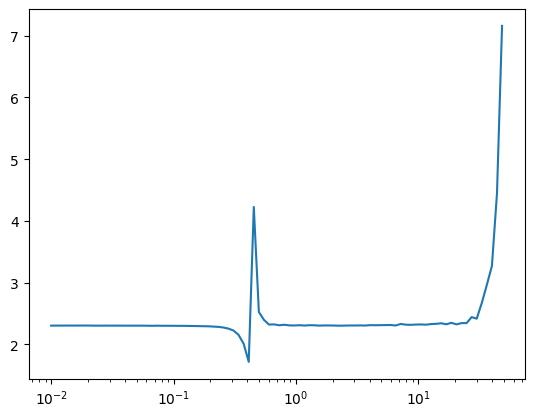

In [ ]:
# Create a learner and run LR finder
# gamma=1.1: Multiply LR by 1.1 each step (10% increase)
# start_lr=1e-2: Start from 0.01
MomentumLearner(get_model(), dls, F.cross_entropy, cbs=[DeviceCB()]).lr_find(gamma=1.1, start_lr=1e-2)

### Training with Activation Statistics

Let's train the model and monitor activations using ActivationStats from the previous notebook.

In [ ]:
# Create callbacks for training
metrics = MetricsCB(accuracy=MulticlassAccuracy())  # Track accuracy

# Monitor activations after ReLU layers
# fc.risinstance creates a function that checks if a module is an instance of nn.ReLU
astats = ActivationStats(fc.risinstance(nn.ReLU))

# Combine all callbacks
cbs = [
    DeviceCB(),            # Move data to correct device (GPU/CPU)
    metrics,               # Track metrics
    ProgressCB(plot=True), # Show progress with plots
    astats                 # Track activation statistics
]

# Create learner with lr=0.2
learn = MomentumLearner(get_model(), dls, F.cross_entropy, lr=0.2, cbs=cbs)

accuracy,loss,epoch,train
0.213,2.155,0,train
0.100,2.331,0,eval


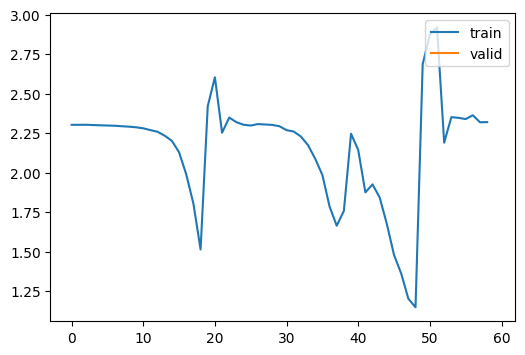

In [ ]:
# Train for 1 epoch
learn.fit(1)

### Visualizing Activation Statistics

Let's look at how the activations behave during training.

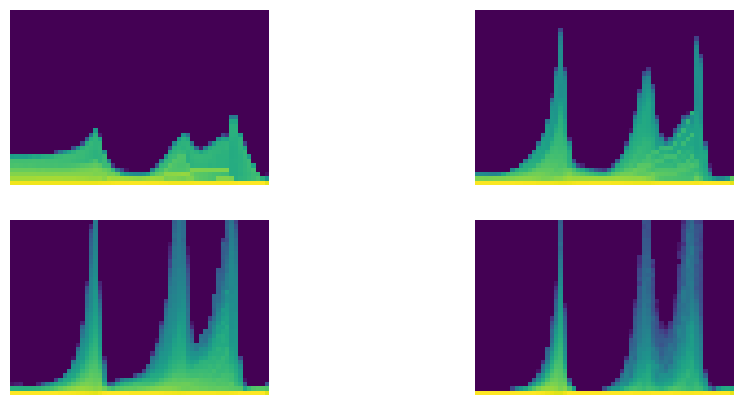

In [ ]:
# Show color-coded activation dimensions
# This shows the distribution of activations across layers during training
astats.color_dim()

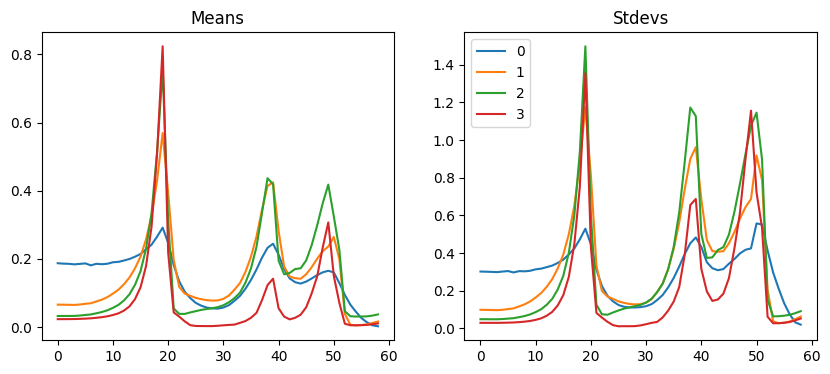

In [ ]:
# Plot mean and std of activations over training
astats.plot_stats()

Notice how the activation statistics might not be ideal - the means and standard deviations may vary significantly across layers, and some layers might have very low activations (potential dead neurons).

This is why proper initialization is so important!

---
## Part 4: Memory Cleanup Utilities

Before we continue, let's define some utility functions to clean up memory. These are especially useful in Jupyter notebooks where memory can accumulate.

In [ ]:
#|export
def clean_ipython_hist():
    """
    Clean IPython history to free memory.

    IPython stores all inputs/outputs in variables like _i1, _1, etc.
    These can consume significant memory over time.
    This function clears them.
    """
    # Only run if we're in IPython environment
    if not 'get_ipython' in globals():
        return

    # Get IPython instance
    ip = get_ipython()
    user_ns = ip.user_ns  # User namespace (all variables)

    # Flush display hook (output caching)
    ip.displayhook.flush()

    # Get prompt count
    pc = ip.displayhook.prompt_count + 1

    # Remove all _iN variables (input history)
    for n in range(1, pc):
        user_ns.pop('_i'+repr(n), None)

    # Clear special input variables
    user_ns.update(dict(_i='', _ii='', _iii=''))

    # Clear history manager
    hm = ip.history_manager
    hm.input_hist_parsed[:] = [''] * pc
    hm.input_hist_raw[:] = [''] * pc
    hm._i = hm._ii = hm._iii = hm._i00 = ''

In [ ]:
#|export
def clean_tb():
    """
    Clean traceback information to free memory.

    Python stores the last traceback for debugging.
    This can hold references to large objects.
    """
    # Clear traceback frames
    if hasattr(sys, 'last_traceback'):
        traceback.clear_frames(sys.last_traceback)
        delattr(sys, 'last_traceback')

    # Clear exception type
    if hasattr(sys, 'last_type'):
        delattr(sys, 'last_type')

    # Clear exception value
    if hasattr(sys, 'last_value'):
        delattr(sys, 'last_value')

In [ ]:
#|export
def clean_mem():
    """
    Clean all memory: traceback, IPython history, and GPU cache.

    Call this function when you're running low on memory,
    especially before training large models.
    """
    clean_tb()                  # Clear tracebacks
    clean_ipython_hist()        # Clear IPython history
    gc.collect()                # Run Python garbage collector
    torch.cuda.empty_cache()    # Clear GPU memory cache

---
## Part 5: Understanding the Initialization Problem

### The Exploding/Vanishing Gradient Problem

Let's see what happens when we chain many matrix multiplications together (like in a deep network).

## Glorot/Xavier Initialization

Xavier Glorot and Yoshua Bengio introduced one of the first principled approaches to weight initialization in their paper ["Understanding the Difficulty of Training Deep Feedforward Neural Networks"](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf).

### Problem 1: Weights Too Large (Exploding Activations)

In [ ]:
# Start with random input: 200 samples, 100 features
x = torch.randn(200, 100)

# Simulate 50 layers of matrix multiplication
# Each "layer" multiplies by a random 100x100 matrix
for i in range(50):
    x = x @ torch.randn(100, 100)  # Matrix multiplication

# Look at the result
x[0:5, 0:5]

tensor([[nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan]])

**The result is `nan`s everywhere!**

This happens because:
1. Each random matrix has std ≈ 1
2. After multiplying by such a matrix, the output std grows by roughly √n_in
3. After 50 layers: activations explode to infinity → `nan`

```
Layer 1: std ≈ √100 = 10
Layer 2: std ≈ 10 × √100 = 100
Layer 3: std ≈ 100 × √100 = 1000
...
Layer 50: std ≈ 10^50 → overflow → nan
```

### Problem 2: Weights Too Small (Vanishing Activations)

In [ ]:
# Start fresh
x = torch.randn(200, 100)

# Use very small weights (scaled by 0.01)
for i in range(50):
    x = x @ (torch.randn(100, 100) * 0.01)  # Very small weights

# Look at the result
x[0:5, 0:5]

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

**Now everything is 0!**

The weights were too small, so activations shrunk to zero. No gradient can flow back through zeros.

### The Goldilocks Solution

We need weights that are "just right" - keeping std ≈ 1 throughout the network.

In [ ]:
# Start fresh
x = torch.randn(200, 100)

# Use properly scaled weights: divide by sqrt(n_in) = sqrt(100) = 0.1
# This is the Xavier/Glorot initialization!
for i in range(50):
    x = x @ (torch.randn(100, 100) * 0.1)  # Scale by 1/sqrt(100)

# Look at the result
x[0:5, 0:5]

tensor([[ 1.33, -1.54,  0.54,  0.13,  3.51],
        [ 0.20,  0.95,  0.61, -0.02,  1.73],
        [-0.69,  1.72,  0.36, -0.64, -2.40],
        [ 0.03,  0.73,  0.40, -1.24, -0.64],
        [ 0.33, -0.33,  0.03, -0.32,  0.62]])

**Now we have reasonable values!**

The activations stayed in a sensible range throughout all 50 layers.

---
## Part 6: Statistical Background

To understand why the scaling works, we need to understand variance and standard deviation.

### Variance and Standard Deviation

**Variance** measures how spread out data is from the mean.

**Standard Deviation** is the square root of variance - it's in the same units as the original data.

In [ ]:
# Example data with an outlier
t = torch.tensor([1., 2., 4., 18])

In [ ]:
# Calculate the mean
m = t.mean()
m  # Should be (1+2+4+18)/4 = 6.25

tensor(6.25)

In [ ]:
# Naive attempt: mean of differences from mean
(t - m).mean()  # This gives 0! Positives and negatives cancel out

tensor(0.)

**Problem**: The differences from the mean sum to zero (by definition of mean)!

**Solutions**:
1. Square the differences (variance)
2. Take absolute values (mean absolute deviation)

In [ ]:
# Method 1: Squared differences = VARIANCE
variance = (t - m).pow(2).mean()
variance

tensor(47.19)

In [ ]:
# Method 2: Absolute differences = Mean Absolute Deviation (MAD)
mad = (t - m).abs().mean()
mad

tensor(5.88)

In [ ]:
# Standard deviation = sqrt(variance)
# This brings it back to the same scale as the original data
std = (t - m).pow(2).mean().sqrt()
std

tensor(6.87)

**Why are std and MAD different?**

The outlier (18) has a much bigger effect on variance because squaring magnifies large differences.

| Value | Diff from mean | Squared | Absolute |
|-------|---------------|---------|----------|
| 1 | -5.25 | 27.56 | 5.25 |
| 2 | -4.25 | 18.06 | 4.25 |
| 4 | -2.25 | 5.06 | 2.25 |
| 18 | **11.75** | **138.06** | 11.75 |

The outlier contributes 138 out of ~189 total (73%) to variance!

### Useful Variance Formula

There's an equivalent formula for variance that's easier to compute:

$$\text{Var}(X) = E[X^2] - E[X]^2$$

In words: "mean of squares minus square of mean"

In [ ]:
# Show both formulas give the same result
formula1 = (t - m).pow(2).mean()  # Standard definition
formula2 = (t * t).mean() - (m * m)  # Computational formula

formula1, formula2  # Should be equal

(tensor(47.19), tensor(47.19))

**Why is the second formula useful?**

You only need to track two running totals:
1. Sum of values (to compute mean)
2. Sum of squared values (to compute mean of squares)

This is important for efficient online/streaming computation.

### Covariance

**Covariance** measures how two variables change together.

$$\text{Cov}(X, Y) = E[(X - E[X])(Y - E[Y])]$$

Or the computational form:

$$\text{Cov}(X, Y) = E[XY] - E[X]E[Y]$$

In [ ]:
# Our original tensor
t

tensor([ 1.,  2.,  4., 18.])

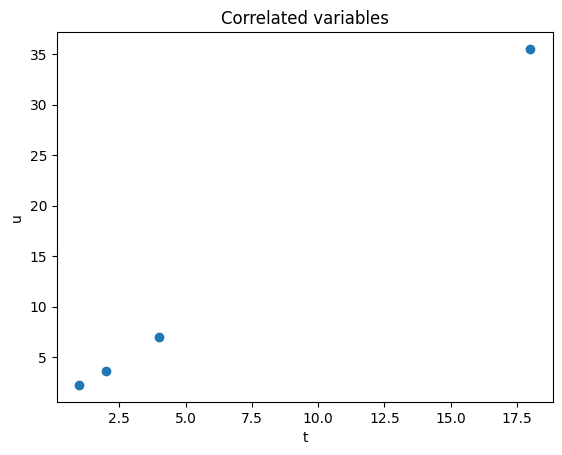

In [ ]:
# Create u that's correlated with t (roughly 2x with some noise)
u = t * 2
u *= torch.randn_like(t) / 10 + 0.95  # Add small random noise

# Plot to visualize the relationship
plt.scatter(t, u)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Correlated variables');

In [ ]:
# Calculate covariance using definition
prod = (t - t.mean()) * (u - u.mean())
prod  # Products of deviations from means

tensor([ 51.67,  35.81,  11.57, 275.08])

In [ ]:
# Covariance = mean of these products
cov_tu = prod.mean()
cov_tu  # Positive = variables move together

tensor(93.53)

**Positive covariance** means when t increases, u tends to increase too.

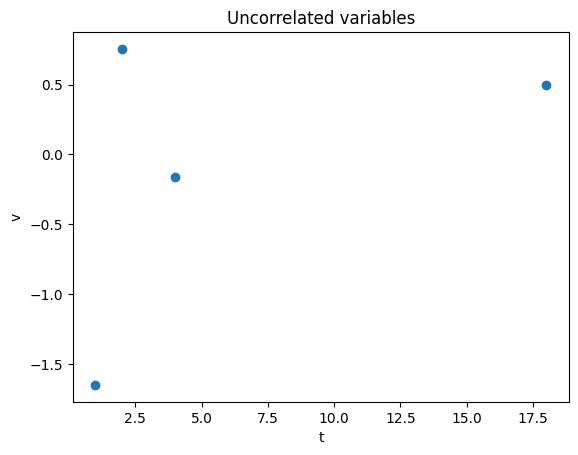

In [ ]:
# Now let's create v that's uncorrelated with t
v = torch.randn_like(t)  # Completely random
plt.scatter(t, v)
plt.xlabel('t')
plt.ylabel('v')
plt.title('Uncorrelated variables');

In [ ]:
# Covariance of uncorrelated variables
cov_tv = ((t - t.mean()) * (v - v.mean())).mean()
cov_tv  # Should be close to 0

tensor(2.91)

In [ ]:
# Verify using computational formula: E[XY] - E[X]E[Y]
cov_check = (t * v).mean() - t.mean() * v.mean()
cov_check  # Same result

tensor(2.91)

### Pearson Correlation Coefficient

Covariance depends on the scale of the variables. The **correlation coefficient** normalizes it to [-1, 1]:

$$\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$

In [ ]:
# Correlation between t and v
correlation = cov_tv / (t.std() * v.std())
correlation  # Close to 0 = no correlation

tensor(0.34)

| Correlation | Meaning |
|-------------|--------|
| +1 | Perfect positive correlation |
| 0 | No correlation |
| -1 | Perfect negative correlation |

---
## Part 7: Xavier Initialization Derivation

Now let's derive why scaling by $1/\sqrt{n_{in}}$ keeps activations stable.

### The Math Behind Matrix Multiplication

When we compute `y = a @ x`, each element of y is:

$$y_i = \sum_{k=0}^{n-1} a_{i,k} \cdot x_k$$

In Python:
```python
y[i] = sum([a[i,k] * x[k] for k in range(n)])
```

Each $y_i$ is the sum of n products of random variables.

In [ ]:
# Check that our input has mean ≈ 0 and std ≈ 1
x = torch.randn(100)  # 100 random values from N(0,1)
x.mean(), x.std()

(tensor(0.19), tensor(0.96))

### What Happens to Variance in Matrix Multiplication?

In [ ]:
# Experiment: What's the variance of y = a @ x?
# Repeat 100 times to get stable statistics

mean, sqr = 0., 0.
for i in range(100):
    x = torch.randn(100)       # Input: 100 features, mean=0, std=1
    a = torch.randn(512, 100)  # Weight matrix: 512 outputs, 100 inputs
    y = a @ x                   # Output: 512 values
    mean += y.mean().item()
    sqr += y.pow(2).mean().item()  # Mean of squares ≈ variance (when mean≈0)

mean/100, sqr/100  # Average mean and variance

(-0.021637045219540595, 101.61874839782715)

**The variance of y is approximately 100 - exactly the number of inputs!**

This is because:
- Each element of y is the sum of 100 products
- Each product has variance 1 (shown below)
- Variance of sum = sum of variances (when independent)
- So variance of y = 100

### Why Does Each Product Have Variance 1?

In [ ]:
# Verify: product of two N(0,1) variables has variance 1
mean, sqr = 0., 0.
for i in range(10000):
    x = torch.randn(1)  # Random from N(0,1)
    a = torch.randn(1)  # Random from N(0,1)
    y = a * x            # Product
    mean += y.item()
    sqr += y.pow(2).item()

mean/10000, sqr/10000  # Mean ≈ 0, Variance ≈ 1

(-0.003184134499988704, 0.9690546516017775)

### The Xavier Solution

Since the variance of `y = a @ x` is n_in times larger than we want:

**Solution**: Scale weights by $1/\sqrt{n_{in}}$

If we multiply weights by $1/\sqrt{n}$, the variance of each weight becomes $1/n$, and the sum of n such products has variance approximately 1.

```
Xavier/Glorot Initialization:
    
    weights ~ N(0, 1/√n_in)
    
    Or equivalently: weights ~ N(0, 1) / √n_in
```

In [ ]:
# Check std of our properly scaled x
x.std()  # Should be close to 1

/tmp/ipykernel_11866/420764500.py:2: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  x.std()  # Should be close to 1


tensor(nan)

---
## Part 8: Kaiming/He Initialization

Xavier initialization works great for networks with symmetric activations (like tanh). But what about ReLU?

> Note: "He" is a Chinese surname and is pronounced like "Her", not like "Hee".

### The Problem with ReLU

In [ ]:
# Create data for a simple 2-layer network
x = torch.randn(200, 100)  # 200 samples, 100 features
y = torch.randn(200)        # Targets (not used here)

In [ ]:
from math import sqrt

# Initialize weights with Xavier scaling
w1 = torch.randn(100, 50) / sqrt(100)  # Layer 1: 100 -> 50
b1 = torch.zeros(50)                    # Bias
w2 = torch.randn(50, 1) / sqrt(50)      # Layer 2: 50 -> 1
b2 = torch.zeros(1)                     # Bias

In [ ]:
# Simple linear layer function
def lin(x, w, b):
    """Linear transformation: y = x @ w + b"""
    return x @ w + b

In [ ]:
# First layer (before activation)
l1 = lin(x, w1, b1)
l1.mean(), l1.std()  # Should be close to (0, 1)

(tensor(0.01), tensor(0.98))

Xavier keeps mean ≈ 0 and std ≈ 1. So far so good!

In [ ]:
# ReLU activation: clamp negative values to 0
def relu(x):
    """ReLU activation: max(0, x)"""
    return x.clamp_min(0.)

In [ ]:
# Apply ReLU to first layer
l2 = relu(l1)
l2.mean(), l2.std()

(tensor(0.40), tensor(0.58))

**Problem**: ReLU zeroes out all negative values (roughly half), so:
- Mean shifts from 0 to ~0.4
- Std drops from 1 to ~0.58

After many layers, this compounds and activations shrink to zero!

In [ ]:
# Let's see what happens after 50 layers with Xavier + ReLU
x = torch.randn(200, 100)
for i in range(50):
    x = relu(x @ (torch.randn(100, 100) * 0.1))  # Xavier scaling

x[0:5, 0:5]  # All zeros!

tensor([[0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00, 0.00, 0.00]])

# Understanding the Kaiming/He Init Background Code

## The Code

```python
x = torch.randn(200, 100)
y = torch.randn(200)
```

```python
w1 = torch.randn(100, 50) / sqrt(100)
b1 = torch.zeros(50)
w2 = torch.randn(50, 1) / sqrt(50)
b2 = torch.zeros(1)
```

```python
def lin(x, w, b): return x @ w + b
```

```python
l1 = lin(x, w1, b1)
l1.mean(), l1.std()  # → (0.02, 0.98)
```

```python
def relu(x): return x.clamp_min(0.)
```

```python
l2 = relu(l1)
l2.mean(), l2.std()  # → (0.40, 0.58)
```

## Layer 1: `w1` and `b1`

```python
w1 = torch.randn(100, 50) / sqrt(100)
b1 = torch.zeros(50)
```

**Why `(100, 50)`?** This is the weight matrix for the first linear layer. The dimensions follow directly from the matrix multiplication rule `x @ w1`:

- `x` is `(200, 100)` → 200 samples, 100 input features
- `w1` is `(100, 50)` → maps 100 inputs down to 50 outputs
- Result `l1` is `(200, 50)` → 200 samples, each now with 50 features

So yes, **50 is the number of output features** (or "hidden units") of the first layer. This is a **design choice** — Jeremy picked 50 as the hidden dimension. He could have picked 128, 256, or any number. The point is that the first dimension of `w1` (100) must match the input features, and the second dimension (50) is the hidden size you choose.

The division by `sqrt(100)` is **Xavier scaling** — dividing by `√n_in` where `n_in = 100` is the number of *inputs* to this layer. As shown in the previous section of the notebook, this keeps the output standard deviation close to 1.

## Layer 2: `w2` and `b2`

```python
w2 = torch.randn(50, 1) / sqrt(50)
b2 = torch.zeros(1)
```

**Why dimensions `(50, 1)` and `(1,)`?** This is the final output layer. It takes the 50-dimensional hidden representation and produces a **single scalar output per sample**:

- Input to layer 2 is `(200, 50)` from layer 1
- `w2` is `(50, 1)` → maps 50 features down to 1
- Result is `(200, 1)` → one prediction per sample

The output dimension is 1 because this is set up as a **regression** problem (remember `y = torch.randn(200)` — a single target value per sample). This is unlike the Fashion MNIST classifier in the rest of the notebook which needs 10 outputs for 10 classes. Here, the purpose is purely to demonstrate what happens to activation statistics — so a minimal single-output network is sufficient.

The division by `sqrt(50)` applies Xavier scaling again, now with `n_in = 50` since this layer receives 50 inputs.

## The Key Point: Xavier Works for Linear Layers...

```python
l1 = lin(x, w1, b1)
l1.mean(), l1.std()  # → (0.02, 0.98)
```

After the linear layer with Xavier scaling, mean ≈ 0 and std ≈ 1. Xavier is doing its job perfectly.

## ...But Breaks When ReLU Is Added

```python
l2 = relu(l1)
l2.mean(), l2.std()  # → (0.40, 0.58)
```

**This is the critical observation.** After applying ReLU:

- **Mean jumps from ~0 to ~0.4** — because ReLU zeros out all negative values, shifting the distribution positive
- **Std drops from ~1 to ~0.58** — because roughly half the values (the negative ones) are clamped to zero, cutting the variance approximately in half (std drops by a factor of ~√2)

The notebook then shows that after 50 layers of Xavier-scaled linear + ReLU, **activations collapse to zero**:

```python
x = torch.randn(200, 100)
for i in range(50): x = relu(x @ (torch.randn(100,100) * 0.1))
x[0:5,0:5]  # → all zeros
```

## The Kaiming Fix

This motivates the **Kaiming/He initialization**: scale by `√(2/n_in)` instead of `1/√n_in`. The extra factor of `√2` compensates for the variance halving caused by ReLU:

```python
x = torch.randn(200, 100)
for i in range(50): x = relu(x @ (torch.randn(100,100) * sqrt(2/100)))
x[0:5,0:5]  # → reasonable non-zero values
```

## Summary of the Data Flow

```
x:  (200, 100)  →  w1: (100, 50)  →  l1: (200, 50)  →  relu  →  l2: (200, 50)  →  w2: (50, 1)  →  output: (200, 1)
    samples×features    Xavier scaled     mean≈0, std≈1            mean≈0.4, std≈0.58   Xavier scaled    one prediction
                        by √100                                    ← PROBLEM!            by √50           per sample
```

The entire setup is a **minimal sandbox** to demonstrate one thing: **Xavier init maintains unit variance through linear layers, but ReLU halves the variance at each layer**, which is why Kaiming's `√(2/n_in)` correction is necessary for networks with ReLU activations.

### Kaiming's Solution

In ["Delving Deep into Rectifiers"](https://arxiv.org/abs/1502.01852), Kaiming He et al. showed that for ReLU, we should use:

$$\text{std} = \sqrt{\frac{2}{n_{in}}}$$

The factor of 2 compensates for ReLU zeroing out half the values.

In [ ]:
# Kaiming initialization with ReLU
x = torch.randn(200, 100)
for i in range(50):
    x = relu(x @ (torch.randn(100, 100) * sqrt(2/100)))  # Kaiming scaling

x[0:5, 0:5]  # Now we have reasonable values!

tensor([[0.40, 0.00, 0.00, 0.28, 0.00],
        [0.37, 0.00, 0.00, 0.30, 0.00],
        [0.28, 0.00, 0.00, 0.20, 0.00],
        [0.36, 0.00, 0.00, 0.30, 0.00],
        [0.25, 0.00, 0.00, 0.19, 0.00]])

**Summary of Initialization Methods:**

| Method | Formula | Use With |
|--------|---------|----------|
| Xavier/Glorot | $\sigma = \sqrt{1/n_{in}}$ | Linear, Tanh, Sigmoid |
| Kaiming/He | $\sigma = \sqrt{2/n_{in}}$ | ReLU |
| Kaiming (Leaky) | $\sigma = \sqrt{2/(1+a^2)/n_{in}}$ | Leaky ReLU (slope a) |

---
## Part 9: Applying Initialization in Practice

PyTorch provides the `model.apply()` method to apply a function to all modules in a model.

In [ ]:
# Create a model and see what modules it contains
model = get_model()

# model.apply runs a function on every module in the model
# Here we just print the type of each module
model.apply(lambda m: print(type(m).__name__));

Conv2d
ReLU
Sequential
Conv2d
ReLU
Sequential
Conv2d
ReLU
Sequential
Conv2d
ReLU
Sequential
Conv2d
Flatten
Sequential


The model contains Sequential containers, Conv2d layers, ReLU activations, and Flatten.

In [ ]:
def init_weights(m):
    """
    Initialize weights using Kaiming initialization.

    Only applies to convolutional layers (Conv1d, Conv2d, Conv3d).
    Uses kaiming_normal_ which draws weights from N(0, sqrt(2/fan_in)).

    Args:
        m: A PyTorch module
    """
    if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
        # init.kaiming_normal_ modifies weights in-place (note the underscore)
        # It uses the formula: std = sqrt(2 / fan_in)
        # where fan_in = kernel_size^2 * in_channels
        init.kaiming_normal_(m.weight)

In [ ]:
# Apply initialization to all layers
model.apply(init_weights);

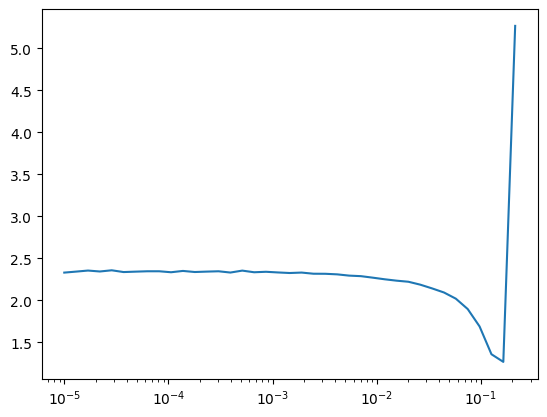

In [ ]:
# Run LR finder with properly initialized model
MomentumLearner(model, dls, F.cross_entropy, cbs=[DeviceCB()]).lr_find()

In [ ]:
# Train with Kaiming initialization
set_seed(42)
learn = MomentumLearner(
    get_model().apply(init_weights),  # Apply init to fresh model
    dls,
    F.cross_entropy,
    lr=0.2,
    cbs=cbs
)

accuracy,loss,epoch,train
0.587,1.231,0,train
0.779,0.596,0,eval
0.817,0.491,1,train
0.830,0.457,1,eval
0.844,0.421,2,train
0.841,0.424,2,eval


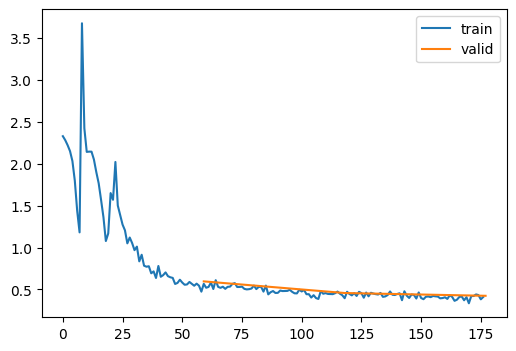

In [ ]:
# Train for 3 epochs
learn.fit(3)

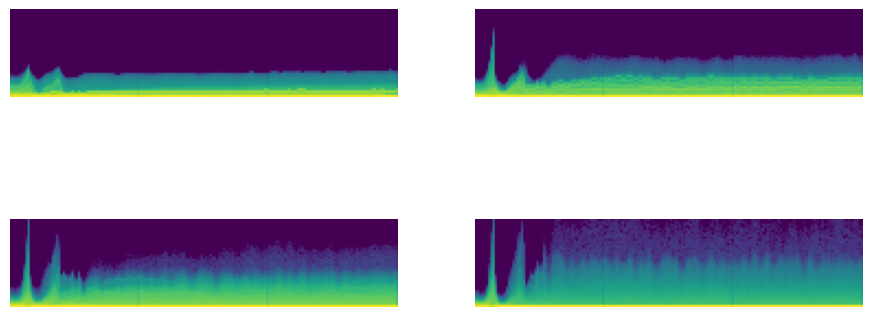

In [ ]:
# Check activation statistics
astats.color_dim()

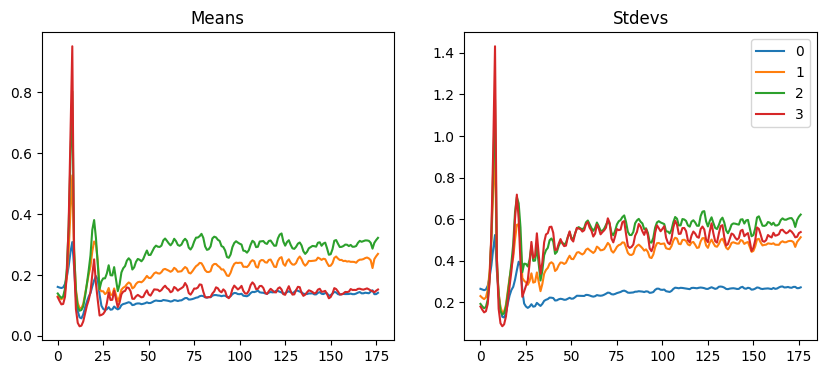

In [ ]:
astats.plot_stats()

The activations should now have more reasonable statistics throughout training!

---
## Part 10: Input Normalization

Even with proper weight initialization, the input data's scale matters. If inputs aren't normalized, the first layer's outputs will have wrong statistics.

### Standard Normalization

We normalize inputs to have mean=0 and std=1:

$$x_{normalized} = \frac{x - \mu}{\sigma}$$

In [ ]:
# Calculate mean and std from a batch
xmean, xstd = xb.mean(), xb.std()
xmean, xstd

(tensor(0.29), tensor(0.35))

The raw pixel values have mean ≈ 0.29 and std ≈ 0.35 (since they're in [0, 1]).

In [ ]:
#| export
class BatchTransformCB(Callback):
    """
    A callback that applies a transformation to batches during training.

    This is useful for normalizing inputs or applying other batch-level
    transformations during training.

    Args:
        tfm: A function that takes a batch (x, y) and returns transformed (x, y)
        on_train: Whether to apply during training (default: True)
        on_val: Whether to apply during validation (default: True)
    """
    def __init__(self, tfm, on_train=True, on_val=True):
        # fc.store_attr() stores all arguments as attributes
        fc.store_attr()

    def before_batch(self, learn):
        """
        Called before each batch is processed.
        Applies the transformation if appropriate.
        """
        # Check if we should apply based on training/validation mode
        if (self.on_train and learn.training) or (self.on_val and not learn.training):
            # Transform the batch in place
            learn.batch = self.tfm(learn.batch)

In [ ]:
# Define normalization function
def _norm(b):
    """
    Normalize the input images in a batch.

    Args:
        b: Tuple of (images, labels)

    Returns:
        Tuple of (normalized_images, labels)
    """
    return (b[0] - xmean) / xstd, b[1]

# Create callback with our normalization
norm = BatchTransformCB(_norm)

accuracy,loss,epoch,train
0.548,1.393,0,train
0.769,0.611,0,eval
0.809,0.519,1,train
0.817,0.486,1,eval
0.842,0.431,2,train
0.838,0.446,2,eval


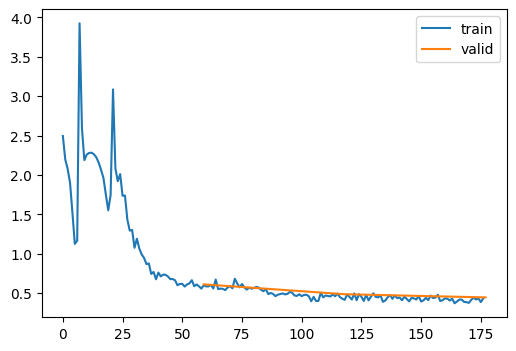

In [ ]:
# Train with normalization callback
set_seed(42)
learn = MomentumLearner(
    get_model().apply(init_weights),
    dls,
    F.cross_entropy,
    lr=0.2,
    cbs=cbs + [norm]  # Add normalization callback
)
learn.fit(3)
# cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats] # this is the default cbs

# Understanding Callback Ordering and `BatchTransformCB`

## The Question

When you add `norm` to the callbacks list using `cbs + [norm]`, the `before_batch` method replaces the batch in place. But `norm` is added at the very end of the list — doesn't that mean callbacks like `MetricsCB`, `ProgressCB`, and `ActivationStats` will work with data that hasn't been normalized yet?

## The Answer: No — Ordering Isn't a Problem

The key insight is that **callbacks are organized by method name, not by position in the list**. When the learner runs a training step, it calls callback methods in a specific sequence dictated by the training loop:

```
before_fit → before_epoch → before_batch → predict → after_predict → ...
```

So when `before_batch` fires, **all** callbacks that have a `before_batch` method get called at that stage.

## Which Callbacks Do What?

Let's look at which callbacks actually have a `before_batch` method:

| Callback | Has `before_batch`? | What it does at `before_batch` |
|---|---|---|
| `DeviceCB` | ✅ Yes | Moves data to GPU |
| `MetricsCB` | ❌ No | Works at `after_batch`, `after_epoch` |
| `ProgressCB` | ❌ No | Works at `after_batch`, `after_epoch` |
| `ActivationStats` | ❌ No | Works via hooks during forward pass |
| `BatchTransformCB` (norm) | ✅ Yes | Normalizes data |

`MetricsCB`, `ProgressCB`, and `ActivationStats` **don't do anything** at the `before_batch` stage at all. They do their work at *later* stages like `after_batch`, `after_epoch`, etc. — by which point the batch has already been both moved to GPU and normalized.

## The Only Ordering That Matters

The only ordering that *could* matter is between `DeviceCB` and `BatchTransformCB`, since both have `before_batch`. Here, `DeviceCB` comes first in the list, so:

1. **`DeviceCB.before_batch`** — moves data to GPU
2. **`BatchTransformCB.before_batch`** — normalizes data

This is fine since `xmean` and `xstd` would need to be on the same device. If they were reversed, you'd normalize on CPU then move to GPU, which would also work but be slightly less efficient.

## Summary

The position of `norm` at the end of the `cbs` list only affects its ordering **relative to other callbacks that share the same method** (`before_batch`), not relative to the actual training steps like forward pass, loss computation, or metrics. The training loop's method-based dispatch ensures everything happens in the correct order.

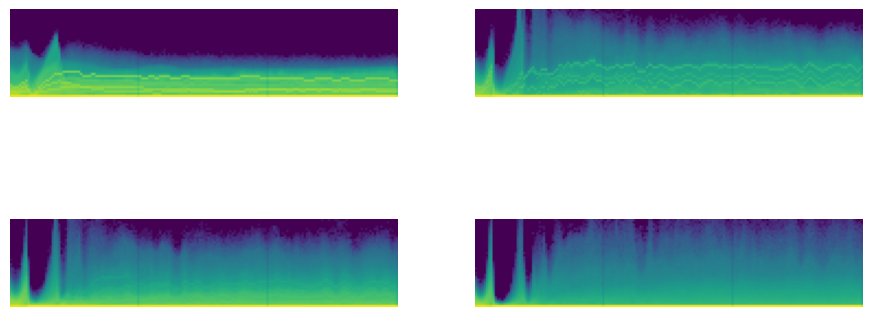

In [ ]:
astats.color_dim()

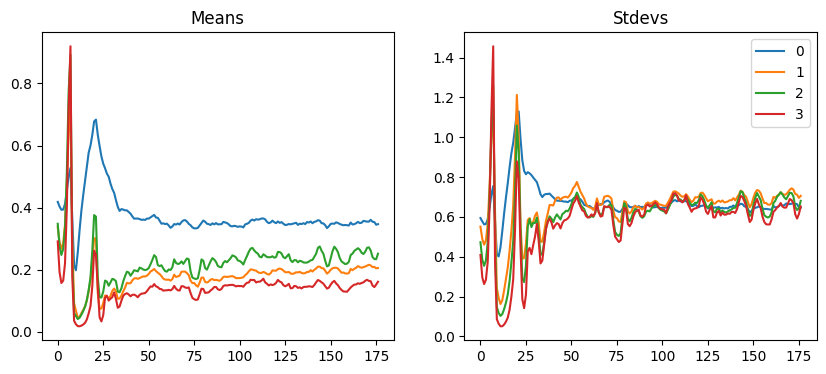

In [ ]:
astats.plot_stats()

### Normalizing in Data Loading

Alternatively, we can normalize during data loading (more efficient):

In [ ]:
# Normalize in the transform function
@inplace
def transformi(b):
    # Convert to tensor AND normalize in one step
    b[xl] = [(TF.to_tensor(o) - xmean) / xstd for o in b[xl]]

# Recreate dataset with normalization
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

# Get a batch to verify
xb, yb = next(iter(dls.train))

In [ ]:
# Check the normalized data
xb.mean(), xb.std()  # Should be close to (0, 1)

(tensor(0.01), tensor(1.00))

Now our inputs are normalized!

---
## Part 11: General ReLU

Standard ReLU has some problems:
1. **Dead neurons**: Once a neuron outputs 0 for all inputs, it stays dead
2. **Non-zero mean**: ReLU outputs are always ≥ 0, shifting the mean

Let's create a more flexible activation function.

In [ ]:
#| export
class GeneralRelu(nn.Module):
    """
    A generalized ReLU activation with additional features.

    Features:
    - leak: Leaky ReLU with specified negative slope
    - sub: Subtract a constant (shifts output down)
    - maxv: Clamp maximum value (bounded ReLU)

    This helps with:
    - Dead neurons (leak prevents zeros for negative inputs)
    - Mean shift (sub can center outputs around 0)
    - Exploding activations (maxv limits maximum output)

    Args:
        leak: Negative slope for leaky ReLU (None = standard ReLU)
        sub: Value to subtract from output (None = no subtraction)
        maxv: Maximum output value (None = no maximum)
    """
    def __init__(self, leak=None, sub=None, maxv=None):
        super().__init__()
        self.leak, self.sub, self.maxv = leak, sub, maxv

    def forward(self, x):
        # Step 1: Apply ReLU (leaky or standard)
        if self.leak is not None:
            # Leaky ReLU: f(x) = x if x > 0, else leak * x
            x = F.leaky_relu(x, self.leak)
        else:
            # Standard ReLU: f(x) = max(0, x)
            x = F.relu(x)

        # Step 2: Subtract constant (shifts mean down)
        if self.sub is not None:
            x -= self.sub

        # Step 3: Clamp maximum (prevents extreme values)
        if self.maxv is not None:
            x.clamp_max_(self.maxv)  # In-place clamp
            #  ensures that no value in the tensor x is greater
            # than self.maxv. Any value larger than the threshold is
            # "capped" at that threshold.

        return x

In [ ]:
#| export
def plot_func(f, start=-5., end=5., steps=100):
    """
    Plot a function over a range.

    Args:
        f: Function to plot
        start: Start of x range (default: -5)
        end: End of x range (default: 5)
        steps: Number of points (default: 100)
    """
    x = torch.linspace(start, end, steps)  # Create evenly spaced x values
    plt.plot(x, f(x))                       # Plot f(x) vs x
    plt.grid(True, which='both', ls='--')  # Add grid
    plt.axhline(y=0, color='k', linewidth=0.7)  # Horizontal line at y=0
    plt.axvline(x=0, color='k', linewidth=0.7)  # Vertical line at x=0

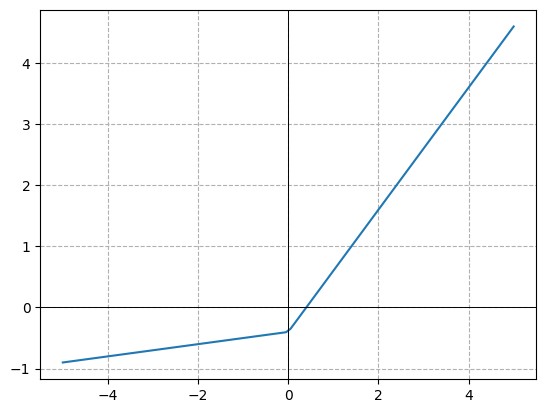

In [ ]:
# Plot GeneralRelu with leak=0.1 and sub=0.4
# This creates a leaky ReLU shifted down by 0.4
plot_func(GeneralRelu(leak=0.1, sub=0.4))

**What the plot shows:**
- For x < 0: slope is 0.1 (leaky part)
- For x > 0: slope is 1 (standard part)
- Everything shifted down by 0.4 (so outputs can be negative)

This helps keep activations centered around 0!

### Updated Model with GeneralRelu

In [ ]:
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU):
    """
    Create a convolutional layer with optional activation.

    Args:
        ni: Number of input channels
        nf: Number of output channels (filters)
        ks: Kernel size (default: 3)
        stride: Stride (default: 2, halves spatial dimensions)
        act: Activation class (default: nn.ReLU, None for no activation)

    Returns:
        Conv2d layer, or Sequential(Conv2d, activation)
    """
    # Create conv layer with same padding (output size = input size / stride)
    res = nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2)

    # Add activation if specified
    if act:
        res = nn.Sequential(res, act())  # act() creates an instance

    return res

In [ ]:
def get_model(act=nn.ReLU, nfs=None):
    """
    Create a CNN with configurable activation and channel sizes.

    Args:
        act: Activation class (default: nn.ReLU)
        nfs: List of channel sizes (default: [1, 8, 16, 32, 64])

    Returns:
        nn.Sequential model
    """
    if nfs is None:
        nfs = [1, 8, 16, 32, 64]  # Default channel progression

    # Create conv layers for each channel transition
    layers = [conv(nfs[i], nfs[i+1], act=act) for i in range(len(nfs)-1)]

    # Add final conv (to 10 classes) and flatten
    return nn.Sequential(
        *layers,                      # Unpack conv layers
        conv(nfs[-1], 10, act=None),  # Final layer, no activation
        nn.Flatten()                   # Flatten for classification
    ).to(def_device)

In [ ]:
#| export
def init_weights(m, leaky=0.):
    """
    Initialize weights using Kaiming initialization.

    Args:
        m: A PyTorch module
        leaky: Negative slope for leaky ReLU (default: 0 = standard ReLU)
               This affects the scaling factor.
    """
    if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
        # The 'a' parameter is the negative slope of the ReLU
        # For standard ReLU: a=0
        # For leaky ReLU with slope 0.1: a=0.1
        init.kaiming_normal_(m.weight, a=leaky)

In [ ]:
# Create GeneralRelu with leak=0.1 and sub=0.4
# partial creates a function with some arguments pre-filled
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)

# Create ActivationStats to monitor GeneralRelu layers
astats = ActivationStats(fc.risinstance(GeneralRelu))

# Update callbacks
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]

# Create init function with correct leaky slope
iw = partial(init_weights, leaky=0.1)

In [ ]:
# Create model with GeneralRelu activation
model = get_model(act_gr).apply(iw)

accuracy,loss,epoch,train
0.774,0.625,0,train
0.846,0.420,0,eval
0.869,0.361,1,train
0.860,0.375,1,eval
0.881,0.324,2,train
0.867,0.362,2,eval


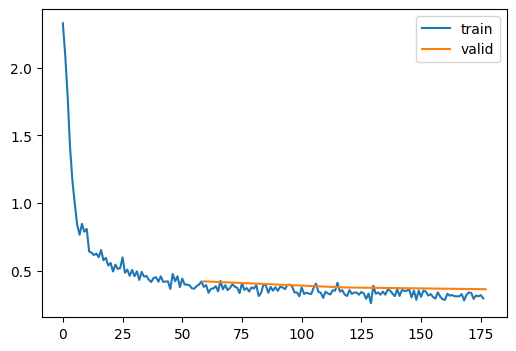

In [ ]:
# Train
set_seed(42)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(3)

# Understanding Activation Functions, Partial, and Model Initialization

This guide explains the key concepts around using custom activation functions and initializing neural network weights in PyTorch.

---

## Part 1: Classes vs Instances - The Foundation

### The Basic Concept

In PyTorch, there's an important distinction between a **class** (a blueprint) and an **instance** (an actual object).

```python
# nn.ReLU is a CLASS (the blueprint)
activation_class = nn.ReLU

# nn.ReLU() is an INSTANCE (an actual activation module)
activation_instance = nn.ReLU()

# To use in a forward pass, you need an INSTANCE
x = torch.randn(10, 5)
output = activation_instance(x)  # ✓ This works
output = activation_class(x)      # ✗ This doesn't work
```

### Why This Matters in `conv()`

Look at the `conv` function:

```python
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU):
    res = nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2)
    
    if act:
        res = nn.Sequential(res, act())  # ← act() creates an instance
    
    return res
```

**Key point**: The parameter `act` receives a **class**, but `nn.Sequential` needs an **instance**. That's why we call `act()` with parentheses.

```python
# When you call the function:
layer = conv(3, 64, act=nn.ReLU)

# Inside the function, act() is called:
# nn.Sequential(Conv2d(...), nn.ReLU())
#                              ↑
#                    Creates an instance of ReLU
```

---

## Part 2: The `partial` Function - Pre-filling Arguments

### What is `partial`?

The `partial` function (from `functools`) creates a **new function with some arguments pre-filled**.

### Simple Example

```python
from functools import partial

# Original function needs 3 arguments
def greet(name, title, country):
    return f"Hello {title} {name} from {country}"

# Every time you call it, you need all 3:
greet("John", "Dr.", "USA")
greet("Sarah", "Dr.", "USA")
greet("Mike", "Dr.", "USA")

# With partial, "lock in" some arguments:
greet_dr_usa = partial(greet, title="Dr.", country="USA")

# Now you only provide the name:
greet_dr_usa("John")   # ← Same as: greet("John", "Dr.", "USA")
greet_dr_usa("Sarah")  # ← Same as: greet("Sarah", "Dr.", "USA")
```

**Key insight**: `partial` creates a **simplified version** of a function with some arguments already filled in.

---

## Part 3: Using `partial` with GeneralRelu

### The Problem

You want to use `GeneralRelu(leak=0.1, sub=0.4)` as your activation, but the `conv` function expects something it can call with just `act()`.

```python
# This WON'T work:
conv(64, 128, act=GeneralRelu(leak=0.1, sub=0.4))
# ✗ You're passing an INSTANCE, not a class
# When conv() tries to call act(), it will fail

# This is awkward:
conv(64, 128, act=lambda: GeneralRelu(leak=0.1, sub=0.4))
# ✓ Works, but ugly and verbose
```

### The Solution: `act_gr`

```python
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
```

**What this creates**: A "customized class" that remembers the parameters.

```python
# Now you can use it cleanly:
conv(64, 128, act=act_gr)

# Inside conv(), when it calls act_gr():
# act_gr() → GeneralRelu(leak=0.1, sub=0.4)
```

**Visual representation**:
```
Without partial:
  act=nn.ReLU  →  act()  →  nn.ReLU()

With partial:
  act=act_gr  →  act_gr()  →  GeneralRelu(leak=0.1, sub=0.4)
```

---

## Part 4: Using `partial` with Weight Initialization

### The Original Function

```python
def init_weights(m, leaky=0.):
    """Initialize weights using Kaiming initialization."""
    if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
        init.kaiming_normal_(m.weight, a=leaky)
```

This function needs two arguments:
- `m`: the module to initialize
- `leaky`: the negative slope for the activation (default 0)

### Creating `iw` with `partial`

```python
iw = partial(init_weights, leaky=0.1)
```

**What this does**:
```python
# Without partial, you'd write:
init_weights(some_module, leaky=0.1)

# With partial:
iw(some_module)  # ← Automatically uses leaky=0.1
```

**Why `leaky=0.1`?** Because your GeneralRelu has `leak=0.1`, and Kaiming initialization needs to know that slope for proper weight scaling.

---

## Part 5: Building and Initializing the Model

### The Complete Line

```python
model = get_model(act_gr).apply(iw)
```

This is actually **two operations** chained together:

1. `get_model(act_gr)` ← Build the model structure
2. `.apply(iw)` ← Initialize all the weights

Let's understand each part.

---

### Part 5A: `get_model(act_gr)` - Building the Model

The `get_model` function creates your neural network. Inside, it looks something like:

```python
def get_model(act=nn.ReLU):
    return nn.Sequential(
        conv(1, 8, act=act),      # Layer 1
        conv(8, 16, act=act),     # Layer 2
        conv(16, 32, act=act),    # Layer 3
        conv(32, 64, act=act),    # Layer 4
        # ... more layers
    )
```

**When you call `get_model(act_gr)`**:

```python
model = get_model(act_gr)

# Step-by-step what happens:
# 1. get_model receives act_gr as the act parameter
# 2. It creates: conv(1, 8, act=act_gr)
# 3. Inside conv(), act_gr() is called
# 4. act_gr() creates GeneralRelu(leak=0.1, sub=0.4)
# 5. This repeats for every conv layer
```

**Result**: A model where every activation is `GeneralRelu(leak=0.1, sub=0.4)`.

**Model structure after `get_model(act_gr)`**:
```
Sequential(
  Conv2d(1, 8) → GeneralRelu(leak=0.1, sub=0.4)
  Conv2d(8, 16) → GeneralRelu(leak=0.1, sub=0.4)
  Conv2d(16, 32) → GeneralRelu(leak=0.1, sub=0.4)
  ...
)
```

**Important**: At this point, the Conv2d layers have **random weights** (PyTorch's default initialization).

---

### Part 5B: `.apply(iw)` - Initializing Weights

Now you have a model with the right architecture, but the weights need proper initialization.

**What is `.apply()`?**

`.apply()` is a PyTorch method that **walks through every module** in your model and calls your function on each one.

```python
model = model.apply(iw)
```

This is equivalent to:
```python
for module in model.modules():  # Visit every module
    iw(module)  # Call init_weights(module, leaky=0.1)
```

**What happens inside `iw(module)`**:

```python
def init_weights(m, leaky=0.1):  # leaky=0.1 from partial
    if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
        # If it's a Conv layer → initialize its weights
        init.kaiming_normal_(m.weight, a=leaky)
    # If it's not a Conv layer → do nothing
```

**Step-by-step execution**:
```
.apply(iw) visits:
  1. Sequential container        → Not a Conv, skip
  2. Conv2d(1, 8)               → IS a Conv, initialize weights! ✓
  3. GeneralRelu                 → Not a Conv, skip
  4. Conv2d(8, 16)              → IS a Conv, initialize weights! ✓
  5. GeneralRelu                 → Not a Conv, skip
  6. Conv2d(16, 32)             → IS a Conv, initialize weights! ✓
  ...and so on
```

**Result**: All Conv2d layers now have properly initialized weights using Kaiming initialization with the correct `leaky=0.1` parameter.

---

### The Complete Picture: Building + Initializing

```python
# The full line:
model = get_model(act_gr).apply(iw)

# What actually happens:

# Step 1: Build the model structure
model = get_model(act_gr)
# Creates: Conv + GeneralRelu(leak=0.1, sub=0.4) layers
# Weights are still random!

# Step 2: Initialize the weights
model = model.apply(iw)
# Visits each module:
#   - Conv layers → initialize with Kaiming (leaky=0.1)
#   - Other layers → skip
# Now weights are properly initialized!
```

---

## Part 6: The Complete Code Block Explained

Let's put it all together and understand the full code:

```python
# 1. Create custom activation with pre-filled parameters
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
# Now act_gr() will create GeneralRelu(leak=0.1, sub=0.4)

# 2. Create callback to monitor activations
astats = ActivationStats(fc.risinstance(GeneralRelu))
# Track statistics of GeneralRelu layers during training

# 3. Set up callbacks list
cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]

# 4. Create initialization function with matching leaky parameter
iw = partial(init_weights, leaky=0.1)
# Now iw(m) will call init_weights(m, leaky=0.1)

# 5. Build and initialize the model
model = get_model(act_gr).apply(iw)
# Part A: get_model(act_gr) builds model with GeneralRelu activations
# Part B: .apply(iw) initializes all Conv weights with Kaiming

# 6. Create learner and train
set_seed(42)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(3)
# Train for 3 epochs with momentum optimizer
# Callbacks will track activations via astats
```

---

## Part 7: Why This All Matters

### The Connection Between Activation and Initialization

When using leaky activations, the initialization needs to account for the leak:

```python
# Your activation has leak=0.1:
GeneralRelu(leak=0.1, sub=0.4)

# So your initialization needs leaky=0.1:
init_weights(m, leaky=0.1)
```

If these don't match, your weights will be scaled incorrectly, leading to:
- Exploding/vanishing gradients
- Slow training
- Poor convergence

### The Power of `partial`

`partial` makes your code:
1. **Cleaner**: No repetitive parameters everywhere
2. **Consistent**: Parameters are set once and used everywhere
3. **Flexible**: Easy to experiment with different values

```python
# Want to try different leak values?
# Just change one line:
act_gr = partial(GeneralRelu, leak=0.2, sub=0.4)
iw = partial(init_weights, leaky=0.2)
# Everything else stays the same!
```

---

## Part 8: Common Confusion Points - Clarified

### Q: Why not just pass `GeneralRelu(leak=0.1, sub=0.4)` directly?

**A**: Because you'd be passing an **instance** when the code expects a **class**.

```python
# This creates ONE instance:
wrong_act = GeneralRelu(leak=0.1, sub=0.4)

# If you pass this to multiple conv layers:
conv(1, 8, act=wrong_act)
conv(8, 16, act=wrong_act)

# They would ALL share the SAME instance (bad!)
# You need a new instance for each layer
```

### Q: Why does `act()` work inside `conv()`?

**A**: Because `act` is a class (or a partial), and calling it with `()` creates a new instance.

```python
# act is a class
act = nn.ReLU

# act() creates a new instance each time
instance1 = act()  # Creates first ReLU
instance2 = act()  # Creates second ReLU
# They're independent objects
```

### Q: What does `.apply()` return?

**A**: It returns the model itself (modified in-place).

```python
# These are equivalent:
model.apply(iw)          # Modifies model
model = model.apply(iw)  # Also returns model for chaining
```

### Q: Why do we need `partial` for `iw` but not for `act_gr`?

**A**: We need `partial` for BOTH!

- `act_gr = partial(GeneralRelu, ...)` pre-fills GeneralRelu parameters
- `iw = partial(init_weights, ...)` pre-fills init_weights parameters

Both use `partial` for the same reason: to avoid repeating parameters.

---

## Part 9: Summary - The Big Picture

```
┌─────────────────────────────────────────────────────────────┐
│ 1. Define Custom Components with partial                    │
├─────────────────────────────────────────────────────────────┤
│ act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)           │
│ → Creates activations with these params when called         │
│                                                              │
│ iw = partial(init_weights, leaky=0.1)                       │
│ → Initializes weights with matching leak parameter          │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 2. Build Model Structure                                     │
├─────────────────────────────────────────────────────────────┤
│ model = get_model(act_gr)                                    │
│ → Creates Conv + GeneralRelu layers throughout              │
│ → Weights are still randomly initialized                    │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 3. Initialize Weights                                        │
├─────────────────────────────────────────────────────────────┤
│ model = model.apply(iw)                                      │
│ → Walks through all modules                                 │
│ → Initializes Conv layers with Kaiming (leaky=0.1)         │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 4. Train with Monitoring                                     │
├─────────────────────────────────────────────────────────────┤
│ learn = MomentumLearner(model, ...)                         │
│ → Callbacks track GeneralRelu activation statistics         │
│ → Train and observe behavior                                │
└─────────────────────────────────────────────────────────────┘
```

---

## Part 10: Key Takeaways

1. **Classes vs Instances**: Pass classes to functions, call them with `()` to create instances
2. **`partial`**: Pre-fill function/class arguments to avoid repetition
3. **`get_model(act)`**: Builds model structure with specified activation
4. **`.apply(fn)`**: Applies a function to every module in the model
5. **Matching parameters**: Activation leak and initialization leak must match
6. **Chaining operations**: `get_model(act).apply(init)` builds then initializes in one line

The magic of `partial` is that it makes complex configurations simple and consistent!

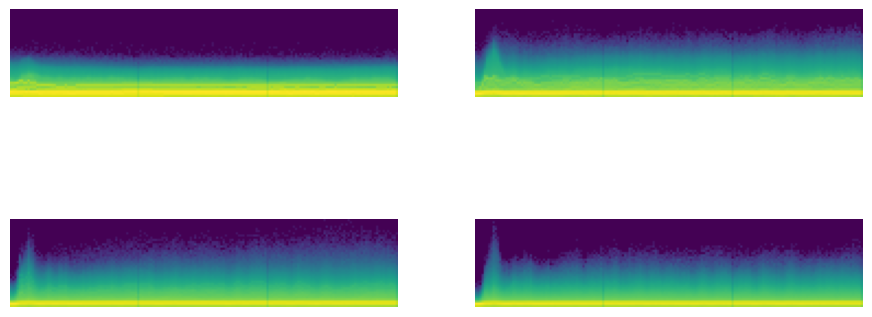

In [ ]:
astats.color_dim()

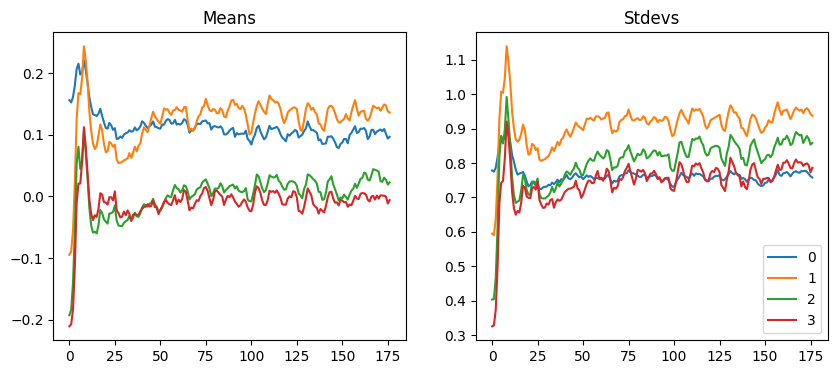

In [ ]:
astats.plot_stats()

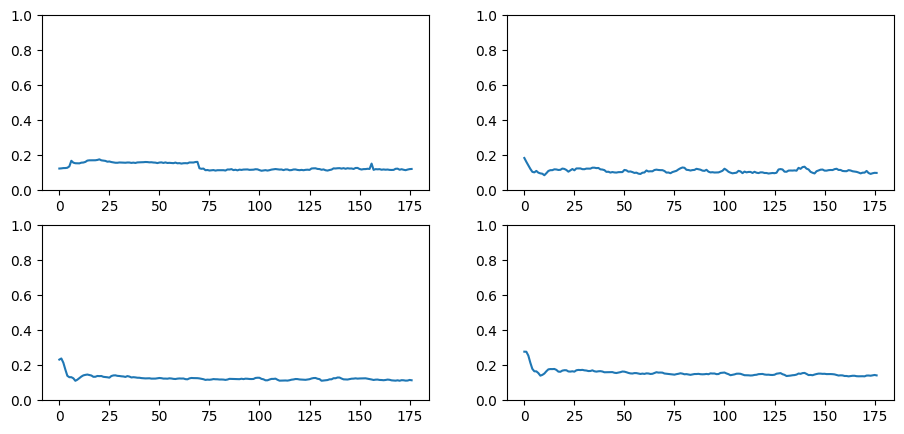

In [ ]:
# Check for dead neurons
astats.dead_chart() # percentage of dead units in each layer

With GeneralRelu, we should see better activation statistics and fewer dead neurons!

---
## Part 12: LSUV (Layer-wise Sequential Unit-Variance)

LSUV is an empirical initialization method from ["All You Need is a Good Init"](https://arxiv.org/pdf/1511.06422.pdf).

**Idea**: Instead of using theoretical formulas, actually run data through the network and adjust weights until each layer has unit variance.

## Part 12: LSUV (Layer-wise Sequential Unit-Variance)

So far we've derived initialization schemes by hand — working out that dividing weights by $\sqrt{n_{in}}$ gives unit output variance, and adjusting for ReLU. But this math has to be redone for every activation function, and for complex or modern activations the "correct" initialization often hasn't been worked out at all.

**LSUV** sidesteps this entirely: instead of calculating the right init, we *measure* it empirically and correct the network to hit unit variance directly.

**The core idea:**
1. Initialize the model however you like (e.g. randomly).
2. Pass a single batch of data through the model.
3. Look at the first layer's output activations — do they have mean ≈ 0 and std ≈ 1?
4. If not, adjust that layer: divide the weights by the activation std, and subtract the mean from the biases. Repeat until the layer hits mean 0, std 1.
5. Move to the next layer and repeat, sequentially through the whole network.

**Implementation:** This is done cleanly with **hooks**, which capture each layer's activation statistics during a forward pass (see the earlier hooks section — same mechanism).

**Advantages:**
- Works for *any* activation function — no need to derive a bespoke init formula.
- Mathematically convenient and general-purpose.

**Limitations:**
- Requires some setup work to wire up the hooks.
- Doesn't handle repeated training runs on its own — it re-initializes every time unless you add logic to skip it.

> Reference: Jeremy Howard introduces LSUV around [57:21](http://www.youtube.com/watch?v=vGsc_NbU7xc&t=3441) in Lesson 17, with the hooks-based implementation at [58:32](http://www.youtube.com/watch?v=vGsc_NbU7xc&t=3512) and discussion of advantages/limitations around [1:02:56](http://www.youtube.com/watch?v=vGsc_NbU7xc&t=3776)–[1:03:15](http://www.youtube.com/watch?v=vGsc_NbU7xc&t=3795). Full video: [Lesson 17: Deep Learning Foundations to Stable Diffusion](https://www.youtube.com/watch?v=vGsc_NbU7xc&list=PLfYUBJiXbdtRUvTUYpLdfHHp9a58nWVXP&index=9).

In [ ]:
#| export
def _lsuv_stats(hook, mod, inp, outp):
    """
    Hook function to collect activation statistics.

    Stores mean and std of outputs on the hook object.

    Args:
        hook: The Hook object
        mod: The module being hooked
        inp: Input to the module
        outp: Output from the module
    """
    acts = to_cpu(outp)       # Move to CPU for computation
    hook.mean = acts.mean()   # Store mean
    hook.std = acts.std()     # Store std

def lsuv_init(model, m, m_in, xb):
    """
    Initialize a layer using LSUV.

    Iteratively adjusts weights until the layer's output has:
    - mean ≈ 0
    - std ≈ 1

    Args:
        model: The full model
        m: The activation module to monitor
        m_in: The preceding layer (whose weights we adjust)
        xb: A batch of input data
    """
    # Create a hook to monitor the activation module
    h = Hook(m, _lsuv_stats)

    # Iteratively adjust weights
    with torch.no_grad():  # No gradient computation needed
        # Keep adjusting until std ≈ 1 and mean ≈ 0
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
            # Adjust bias to fix mean
            m_in.bias -= h.mean
            # Scale weights to fix std
            m_in.weight.data /= h.std

    # Clean up hook
    h.remove()

In [ ]:
"""
================================================================================
LSUV (Layer-wise Sequential Unit-Variance) Initialization — Fully Explained
================================================================================

FILE PURPOSE:
    This file contains two functions — `_lsuv_stats` and `lsuv_init` — that
    together implement the LSUV weight initialization algorithm for neural
    networks. This file also includes the calling code that applies LSUV to
    an entire model, layer by layer.

WHAT PROBLEM DOES LSUV SOLVE?
    When we create a neural network, all its weights start as random numbers.
    The quality of these random starting values matters enormously:

    - If weights are too large → activations (the numbers flowing through the
      network) explode to infinity → training fails with NaN errors.
    - If weights are too small → activations shrink to zero → gradients vanish
      → the network cannot learn anything.
    - If weights are "just right" → activations stay in a healthy range →
      the network trains smoothly and quickly.

    Traditional methods like Xavier (Glorot) and Kaiming (He) initialization
    use mathematical formulas to pick good starting weights. These formulas
    are based on ASSUMPTIONS about the network (e.g., "activations are
    Gaussian," "each layer is independent"). These assumptions don't always
    hold, especially for complex architectures or unusual activation functions.

    LSUV takes a completely different, empirical approach:
        1. Feed a real batch of training data through the network.
        2. MEASURE what actually comes out of each layer.
        3. If the output is not centered at zero, adjust the bias.
        4. If the output spread (standard deviation) is not 1, adjust the weights.
        5. Repeat until the layer's output has mean ≈ 0 and std ≈ 1.
        6. Move to the next layer and repeat.

    This is like the difference between calculating how much salt a recipe
    needs (Xavier/Kaiming) vs. actually tasting the food and adjusting
    (LSUV). The tasting approach adapts to whatever is actually happening.

WHY DOES EACH LAYER NEED mean ≈ 0 AND std ≈ 1?
    Think of a neural network as a chain of layers:

        Input → Layer 1 → Layer 2 → Layer 3 → ... → Output

    Each layer takes the previous layer's output as its input. If Layer 1
    outputs numbers with std = 3, then Layer 2 receives inputs 3x larger
    than expected. Layer 2 then amplifies them further. After many layers,
    the numbers either explode to infinity or collapse to zero.

    By ensuring every layer outputs numbers with mean ≈ 0 and std ≈ 1,
    we keep the "signal" flowing through the network at a healthy,
    stable magnitude. This is the foundation of successful training.

WHY TWO SEPARATE FUNCTIONS?
    We split the code into `_lsuv_stats` and `lsuv_init` because they
    have different jobs:

    - `_lsuv_stats`: A tiny "observer" function. Its ONLY job is to look
      at what a layer produces and write down two numbers (mean and std).
      It gets called automatically by PyTorch's hook system every time
      data passes through the layer — you never call it yourself.

    - `lsuv_init`: The "controller" function. It sets up the observer,
      runs data through the network, reads what the observer recorded,
      adjusts the weights, and repeats until the layer is properly
      initialized. This is the function you actually call.

    The underscore prefix in `_lsuv_stats` is a Python convention meaning
    "this is a private/internal helper — don't call it directly."

REFERENCE:
    LSUV was introduced in the paper:
    "All You Need is a Good Init" by Mishkin & Matas (2015)
    https://arxiv.org/pdf/1511.06422.pdf

CONTEXT IN THE FAST.AI COURSE:
    This code is part of the fast.ai "From the Foundations" course (Part 2),
    specifically from Notebook 11 on weight initialization. It builds on
    the Hook class and activation monitoring tools developed in earlier
    notebooks (miniai.activations).
================================================================================
"""

# ==============================================================================
# IMPORTS
# ==============================================================================

import torch                    # PyTorch: the deep learning framework we use
import torch.nn as nn           # nn module: contains building blocks like Conv2d, ReLU, etc.
from functools import partial   # partial: lets us "pre-fill" some arguments of a function

# These come from earlier notebooks in the fast.ai course:
# - Hook: a wrapper class that registers a PyTorch forward hook on a module
# - to_cpu: a utility that moves a tensor from GPU to CPU
# - GeneralRelu: a flexible activation function with leak, subtraction, and max clamping
# In the actual course code, they would be imported like this:
# from miniai.activations import Hook, to_cpu
# from miniai.init import GeneralRelu


# ==============================================================================
# FUNCTION 1: _lsuv_stats — The "Observer" (Hook Callback)
# ==============================================================================

def _lsuv_stats(hook, mod, inp, outp):
    """
    A hook callback function that observes a layer's output during a forward
    pass and records two statistics: the mean and the standard deviation.

    ──────────────────────────────────────────────────────────────────────────
    WHY THIS FUNCTION EXISTS:
    ──────────────────────────────────────────────────────────────────────────
    During LSUV initialization, we need to repeatedly answer the question:
    "What is the mean and standard deviation of this layer's output right now?"

    We can't just call the layer directly and look at the output, because
    the layer sits in the MIDDLE of a larger network. To get the correct
    output, we need to run data through the ENTIRE model (so all preceding
    layers process the data first), and then capture what this particular
    layer produces.

    PyTorch's "forward hook" mechanism lets us do exactly that. A forward
    hook is a function that PyTorch automatically calls every time data
    passes through a specific layer. We don't call it ourselves — PyTorch
    calls it for us, invisibly, during model(xb).

    This function IS that hook. Its job is simple: receive the layer's
    output, compute the mean and std, and store them somewhere we can
    read them later.

    ──────────────────────────────────────────────────────────────────────────
    HOW THIS FUNCTION GETS CALLED (THE HOOK MECHANISM):
    ──────────────────────────────────────────────────────────────────────────
    You might notice this function has 4 parameters (hook, mod, inp, outp),
    but PyTorch hooks normally receive only 3 (module, input, output).
    Here's how the extra "hook" parameter gets filled in:

    When we create a Hook object in lsuv_init:
        h = Hook(m, _lsuv_stats)

    The Hook class internally does:
        m.register_forward_hook(partial(_lsuv_stats, self))
                                       ^^^^^^^^^^^^^^^^
                                       This pre-fills the FIRST argument

    So partial(_lsuv_stats, h) creates a NEW function that:
    - Already has "hook" = h locked in as the first argument
    - Only needs 3 more arguments: mod, inp, outp
    - These 3 are exactly what PyTorch provides to hooks!

    When PyTorch calls the hook during a forward pass, this happens:
        partial(_lsuv_stats, h)(module, input, output)
        → _lsuv_stats(h, module, input, output)   # All 4 args filled!

    This is a clever use of partial() to bridge the gap between what
    PyTorch provides (3 args) and what we need (4 args, with access
    to the Hook object for storing results).

    ──────────────────────────────────────────────────────────────────────────
    PARAMETERS EXPLAINED:
    ──────────────────────────────────────────────────────────────────────────

    Parameters
    ----------
    hook : Hook
        The Hook object that registered this callback. We use it as a
        "storage box" — we save the mean and std as attributes on this
        object (hook.mean, hook.std) so that the calling code (lsuv_init)
        can read them after the forward pass completes.

        Think of it like a clipboard: the observer (this function) writes
        numbers on the clipboard, and the controller (lsuv_init) reads
        them off the clipboard.

    mod : nn.Module
        The specific PyTorch module (layer) this hook is attached to.
        For example, this might be a GeneralRelu activation layer.
        PyTorch passes this automatically. We don't use it in this
        function, but PyTorch requires hooks to accept it.

    inp : tuple of Tensors
        The input tensor(s) that were fed INTO the module. PyTorch passes
        this automatically. We don't use it here — we only care about
        the OUTPUT, not the input. But PyTorch requires hooks to accept it.

    outp : Tensor
        The output tensor that the module PRODUCED. This is what we care
        about! For a convolutional layer followed by ReLU, this would be
        the activation values after ReLU. Its shape is typically:
            (batch_size, num_channels, height, width)
        For example: (1024, 32, 4, 4) = 1024 images, 32 channels, 4×4 spatial.

    Returns
    -------
    None
        This function doesn't return anything. It stores its results as
        attributes on the `hook` object (hook.mean and hook.std), which
        the calling code reads later.
    """

    # ──────────────────────────────────────────────────────────────────────
    # STEP 1: Move the output tensor to CPU
    # ──────────────────────────────────────────────────────────────────────
    # Why? The model typically runs on GPU for speed. But we need to compute
    # simple statistics (mean, std), and we want to store them as regular
    # Python numbers that lsuv_init can easily read. Moving to CPU ensures
    # compatibility and avoids potential GPU memory issues during this
    # initialization phase (which is NOT part of training).
    #
    # to_cpu() is a utility from the fast.ai course (miniai.activations)
    # that safely moves a tensor to CPU. If the tensor is already on CPU,
    # it does nothing.
    #
    # `outp` is the raw output tensor from the layer. It could be on GPU.
    # `acts` is the same tensor, now guaranteed to be on CPU.
    # The name "acts" stands for "activations" — the values produced by
    # an activation function (like ReLU) after processing the conv output.
    acts = to_cpu(outp)

    # ──────────────────────────────────────────────────────────────────────
    # STEP 2: Compute and store the MEAN of all activation values
    # ──────────────────────────────────────────────────────────────────────
    # acts.mean() computes the arithmetic mean (average) of EVERY single
    # number in the entire tensor. No dimensions are specified, so it
    # averages across all dimensions: batch, channels, height, and width.
    #
    # For example, if acts has shape (1024, 32, 4, 4):
    #   Total number of values = 1024 × 32 × 4 × 4 = 524,288
    #   acts.mean() = sum of all 524,288 values / 524,288
    #   Result: a single scalar number, e.g., tensor(0.42)
    #
    # WHY WE WANT MEAN ≈ 0:
    # If the mean is far from zero, it means the layer's output is
    # systematically shifted (biased) to one side. For example, standard
    # ReLU always outputs non-negative values, so its mean is always > 0.
    # A shifted distribution makes it harder for the next layer to learn
    # effectively. By adjusting the bias to bring mean toward 0, we
    # center the distribution, giving the next layer balanced inputs.
    #
    # We store it on `hook` (not as a local variable) because this function
    # runs INSIDE PyTorch's forward pass machinery. By the time it finishes,
    # the forward pass continues. The only way for lsuv_init (which is
    # OUTSIDE the forward pass) to access these values is if we store them
    # on a persistent object — the Hook object `hook` that both this
    # function and lsuv_init have access to.
    hook.mean = acts.mean()

    # ──────────────────────────────────────────────────────────────────────
    # STEP 3: Compute and store the STANDARD DEVIATION of all activations
    # ──────────────────────────────────────────────────────────────────────
    # acts.std() computes the standard deviation of EVERY number in the
    # tensor, across all dimensions (just like mean above).
    #
    # Standard deviation measures the "spread" of the values — how far
    # they typically are from the mean.
    #   - std = 1 means values are nicely spread (the healthy target)
    #   - std = 5 means values are 5x more spread than desired (too large)
    #   - std = 0.1 means values are squished near zero (too small)
    #
    # For example: if acts.std() = 3.2, it means the activations are
    # spread out about 3.2x more than we want.
    #
    # WHY WE WANT STD ≈ 1:
    # If std is too large, signals amplify as they pass through layers,
    # eventually causing numerical overflow (NaN). If std is too small,
    # signals shrink to zero and gradients vanish — the network stops
    # learning. std ≈ 1 is the sweet spot where signals propagate at a
    # stable magnitude through the entire network.
    #
    # Same as mean, we store it on the hook object so lsuv_init can read it.
    hook.std = acts.std()

    # ──────────────────────────────────────────────────────────────────────
    # THAT'S IT — this function's job is done.
    # It will be called again automatically on the NEXT forward pass
    # (i.e., the next time model(xb) is called inside lsuv_init's loop),
    # at which point it will OVERWRITE hook.mean and hook.std with
    # the NEW statistics from the updated weights.
    # ──────────────────────────────────────────────────────────────────────


# ==============================================================================
# FUNCTION 2: lsuv_init — The "Controller" (Initialization Algorithm)
# ==============================================================================

def lsuv_init(model, m, m_in, xb):
    """
    Initialize ONE layer of a neural network using the LSUV algorithm.

    This function adjusts the weights and biases of a single layer (m_in)
    so that the activation output (m) has mean ≈ 0 and std ≈ 1.
    It does this by repeatedly running real data through the network,
    measuring the output statistics, and making corrections.

    ──────────────────────────────────────────────────────────────────────────
    WHY THIS FUNCTION EXISTS:
    ──────────────────────────────────────────────────────────────────────────
    Xavier and Kaiming initialization use theoretical formulas that ASSUME
    certain properties (Gaussian inputs, independent layers, specific
    activation functions). LSUV doesn't assume — it MEASURES. This makes
    it more accurate and more flexible:

    - Works with ANY activation function (ReLU, LeakyReLU, GeneralRelu, etc.)
    - Accounts for the actual data distribution (not just theoretical)
    - Adapts to the real behavior of the specific architecture
    - Achieves precise target statistics (mean=0, std=1) through iteration

    ──────────────────────────────────────────────────────────────────────────
    THE KEY INSIGHT: MONITOR THE ACTIVATION, ADJUST THE PRECEDING CONV
    ──────────────────────────────────────────────────────────────────────────
    In a typical neural network, each "block" looks like:

        Conv2d → Activation (e.g., ReLU)

    The Conv2d layer has weights and biases. The activation has no learnable
    parameters (it just applies a fixed function like max(0, x)).

    We want to control what the ACTIVATION outputs, because that's what
    the NEXT block will receive as input. But we can only adjust the
    Conv2d's weights and biases (since the activation has none).

    So the strategy is:
    - MONITOR the activation layer's output (using a hook on `m`)
    - ADJUST the Conv2d layer's weights and biases (`m_in`)

    It's like adjusting the temperature of water going into a shower (Conv2d)
    by checking the temperature coming out of the showerhead (activation).

    ──────────────────────────────────────────────────────────────────────────
    HOW THE ITERATIVE ADJUSTMENT WORKS:
    ──────────────────────────────────────────────────────────────────────────
    Recall from linear algebra that a layer computes:
        output = weights × input + bias

    - The BIAS controls the CENTER (mean) of the output distribution.
      If the output mean is 0.8, subtracting 0.8 from the bias shifts
      the entire output distribution down by 0.8, bringing the mean to ~0.

    - The WEIGHTS control the SPREAD (std) of the output distribution.
      If the output std is 3.2, dividing all weights by 3.2 shrinks the
      output by a factor of 3.2, bringing the std to ~1.

    These two adjustments interact slightly (changing weights affects the
    mean a bit, and changing bias doesn't affect std), so we iterate:
    run data → measure → adjust → repeat, until both mean and std are
    within our tolerance (0.001).

    Typically this converges in 2-4 iterations.

    ──────────────────────────────────────────────────────────────────────────
    PARAMETERS EXPLAINED:
    ──────────────────────────────────────────────────────────────────────────

    Parameters
    ----------
    model : nn.Module (nn.Sequential)
        The COMPLETE neural network model (all layers). We need the full
        model because we must run a forward pass through the ENTIRE network
        to get correct activation statistics. Even though we're only
        initializing one layer, all the preceding layers must process the
        data first to produce the correct input for the layer we care about.

        Example: A 5-layer CNN created by get_model():
            Sequential(
                Conv2d(1,8) → GeneralRelu,    ← Block 0
                Conv2d(8,16) → GeneralRelu,   ← Block 1
                Conv2d(16,32) → GeneralRelu,  ← Block 2
                Conv2d(32,64) → GeneralRelu,  ← Block 3
                Conv2d(64,10) → Flatten        ← Final classification layer
            )

    m : nn.Module
        The ACTIVATION module to MONITOR. This is where we attach the hook
        to observe the output statistics. We monitor the activation (not the
        conv) because the activation's output is what the next layer receives.

        Example: A GeneralRelu(leak=0.1, sub=0.4) layer.

    m_in : nn.Module
        The PRECEDING layer whose weights and biases we ADJUST. This is
        the Conv2d layer that feeds into the activation `m`. We modify
        m_in's weight and bias to control what m outputs.

        Example: A Conv2d(8, 16, kernel_size=3, stride=2) layer.

        IMPORTANT: m_in and m form a pair. In the network:
            ... → m_in (Conv2d) → m (GeneralRelu) → next layer ...
        We watch m's output, and tweak m_in's parameters.

    xb : Tensor
        A batch of real training data. Shape: (batch_size, channels, H, W).
        For Fashion MNIST: (1024, 1, 28, 28) = 1024 grayscale 28×28 images.

        WHY REAL DATA? Because LSUV's power comes from measuring what
        actually happens with real data, not from theoretical assumptions.
        The statistics depend on the data distribution, the architecture,
        and the current weights — all of which are specific to your setup.

        This batch should be on the same device (CPU/GPU) as the model.
        In the calling code, this is done via: xb.to(def_device)

    Returns
    -------
    None
        This function modifies m_in.weight and m_in.bias IN-PLACE.
        It does not return anything. After it finishes, m_in's parameters
        have been adjusted so that m's output has mean ≈ 0 and std ≈ 1.

        The modifications persist in the original model because Python
        passes objects by reference. The `m_in` parameter is not a copy —
        it IS the actual Conv2d layer inside `model`. So changing m_in.bias
        directly changes the model's bias.
    """

    # ──────────────────────────────────────────────────────────────────────
    # STEP 1: Attach a hook to the activation layer to observe its output
    # ──────────────────────────────────────────────────────────────────────
    #
    # Hook(m, _lsuv_stats) does three things:
    #   1. Creates a Hook object `h`
    #   2. Creates partial(_lsuv_stats, h) — a version of _lsuv_stats with
    #      its first argument (hook) pre-filled as `h`
    #   3. Registers that partial function as a forward hook on module `m`
    #
    # After this line:
    #   - Whenever data flows through `m` (during model(xb)), PyTorch will
    #     AUTOMATICALLY call _lsuv_stats(h, m, input, output)
    #   - The results (mean and std) will be stored on h as h.mean, h.std
    #   - h.mean and h.std DO NOT EXIST YET — they'll be created the first
    #     time _lsuv_stats runs (which happens during the first model(xb))
    #
    # Think of this like installing a thermometer in a pipe:
    #   - h = the thermometer (records temperature readings)
    #   - m = the pipe (the activation layer where we install it)
    #   - _lsuv_stats = the thermometer's logic (read and record temp)
    #   - The thermometer only takes a reading when water flows through
    #     (i.e., when model(xb) runs a forward pass)
    h = Hook(m, _lsuv_stats)

    # ──────────────────────────────────────────────────────────────────────
    # STEP 2: Enter a no-gradient context
    # ──────────────────────────────────────────────────────────────────────
    #
    # torch.no_grad() tells PyTorch: "Don't track gradients for anything
    # that happens inside this block."
    #
    # WHY? During LSUV, we are NOT training the network. We are just
    # adjusting the starting weights before training begins. We don't
    # need gradients (which are only needed for backpropagation during
    # actual training). Disabling gradient tracking:
    #   - Saves memory (no computation graph is built)
    #   - Speeds up the forward passes
    #   - Prevents the initialization adjustments from interfering with
    #     PyTorch's autograd system
    with torch.no_grad():

        # ──────────────────────────────────────────────────────────────────
        # STEP 3: The iterative adjustment loop
        # ──────────────────────────────────────────────────────────────────
        #
        # This while loop has a compound condition. Let's break it apart:
        #
        # PART A: model(xb) is not None
        # ─────────────────────────────
        #   model(xb) runs a COMPLETE forward pass: feeds the batch `xb`
        #   through every layer of the model, from input to output.
        #
        #   During this forward pass, when execution reaches the activation
        #   layer `m`, PyTorch automatically calls our hook (_lsuv_stats).
        #   The hook records h.mean and h.std from m's output.
        #
        #   model(xb) always returns a tensor (never None), so "is not None"
        #   is always True. This might look pointless, but it serves a
        #   critical purpose: it FORCES Python to evaluate model(xb) as
        #   part of the while condition check. This ensures the forward
        #   pass (and therefore the hook) runs BEFORE we check h.std and
        #   h.mean on the right side of the `and`.
        #
        #   Without it, on the very first iteration, h.std and h.mean
        #   wouldn't exist yet (they're only created when the hook runs).
        #
        #   This is a compact coding trick. A more explicit version:
        #       while True:
        #           model(xb)  # Run forward pass (hook updates h.mean, h.std)
        #           if abs(h.std - 1) <= 1e-3 and abs(h.mean) <= 1e-3:
        #               break  # Converged!
        #           m_in.bias -= h.mean
        #           m_in.weight.data /= h.std
        #
        # PART B: abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3
        # ─────────────────────────────────────────────────────
        #   This checks whether we've converged to our targets.
        #   The loop CONTINUES as long as EITHER condition is true:
        #
        #   abs(h.std - 1) > 1e-3
        #     → "Is the standard deviation more than 0.001 away from 1?"
        #     → Examples: std=1.5 → abs(1.5-1)=0.5 > 0.001 → True (keep going)
        #                 std=1.0004 → abs(0.0004) < 0.001 → False (close enough)
        #
        #   abs(h.mean) > 1e-3
        #     → "Is the mean more than 0.001 away from 0?"
        #     → Examples: mean=0.4 → abs(0.4) > 0.001 → True (keep going)
        #                 mean=0.0002 → abs(0.0002) < 0.001 → False (close enough)
        #
        #   1e-3 (= 0.001) is the convergence tolerance. It means we accept
        #   the initialization when mean is within ±0.001 of 0, and std is
        #   within ±0.001 of 1.
        #
        #   The loop STOPS (exits) only when BOTH:
        #     - std is within 0.001 of 1.0, AND
        #     - mean is within 0.001 of 0.0
        #
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):

            # ──────────────────────────────────────────────────────────────
            # STEP 3a: Adjust the BIAS to move the mean toward 0
            # ──────────────────────────────────────────────────────────────
            #
            # Recall: the Conv2d layer computes:
            #     output = (weights ⊛ input) + bias
            # where ⊛ is the convolution operation.
            #
            # The bias is added to every output value. If we subtract h.mean
            # from the bias, the output mean shifts by -h.mean:
            #     new_mean ≈ old_mean - h.mean ≈ 0
            #
            # Example:
            #   Current h.mean = 0.8 (outputs are centered around 0.8)
            #   We do: bias -= 0.8
            #   New output mean ≈ 0.8 - 0.8 = 0
            #
            # m_in.bias is a nn.Parameter tensor, typically shape (nf,) where
            # nf is the number of output channels/filters. For example, if
            # the Conv2d has 32 output channels, bias has shape (32,).
            #
            # h.mean is a single scalar (the mean across ALL channels, ALL
            # spatial positions, ALL batch items). We subtract this scalar
            # from every element of the bias vector.
            #
            # The -= operator modifies the bias IN-PLACE, meaning it changes
            # the actual bias parameter stored in the model. No copy is made.
            m_in.bias -= h.mean

            # ──────────────────────────────────────────────────────────────
            # STEP 3b: Scale the WEIGHTS to move the std toward 1
            # ──────────────────────────────────────────────────────────────
            #
            # The weights control the scale/spread of the output. If the
            # output has std = 3.2, dividing all weights by 3.2 will shrink
            # the output by a factor of 3.2, bringing std toward 1.0.
            #
            # Math: If y = w × x, then std(y) = |w| × std(x).
            # So if we divide w by std(y), we get:
            #     new_std(y) = (|w| / std(y)) × std(x) = std(x) ≈ 1
            # (because x was already normalized by the previous layer)
            #
            # Example:
            #   Current h.std = 3.2 (outputs are 3.2x too spread out)
            #   We do: weight /= 3.2
            #   New output std ≈ 3.2 / 3.2 = 1.0
            #
            # WHY .data? We use m_in.weight.data instead of m_in.weight because:
            #   - m_in.weight is an nn.Parameter (a special tensor that tracks
            #     gradients for training)
            #   - Dividing an nn.Parameter normally would try to create a
            #     computation graph node (for autograd)
            #   - We're inside torch.no_grad(), so this shouldn't matter much,
            #     but using .data is a belt-and-suspenders approach: .data gives
            #     us the raw underlying tensor, bypassing autograd entirely
            #   - This is a common pattern in initialization code
            #
            # Note: For bias above, we used -= which modifies in-place and
            # works fine with nn.Parameter inside no_grad(). For weight,
            # the original code uses .data as an extra safety measure.
            #
            # m_in.weight.data shape for Conv2d: (out_channels, in_channels, kH, kW)
            # For example: (32, 16, 3, 3) = 32 output filters, 16 input channels, 3×3 kernel
            # We divide every single weight value by the same scalar h.std.
            m_in.weight.data /= h.std

        # ──────────────────────────────────────────────────────────────────
        # At this point, the loop has exited, meaning:
        #   - h.mean is within 0.001 of 0 (layer output is centered)
        #   - h.std is within 0.001 of 1 (layer output has unit variance)
        #   - m_in's weights and bias have been adjusted accordingly
        # The layer is now properly initialized!
        # ──────────────────────────────────────────────────────────────────

    # ──────────────────────────────────────────────────────────────────────
    # STEP 4: Remove the hook — clean up
    # ──────────────────────────────────────────────────────────────────────
    #
    # Now that this layer is initialized, we don't need the hook anymore.
    # h.remove() does two things:
    #   1. Unregisters the hook from module `m`, so _lsuv_stats will no
    #      longer be called on future forward passes through `m`.
    #   2. Frees the resources associated with the hook.
    #
    # WHY REMOVE? If we left hooks attached, they would:
    #   - Slow down future forward passes (extra function calls)
    #   - Waste memory storing mean/std values we don't need
    #   - Potentially interfere with training
    #
    # After this line, `h` still exists as a Python variable but is
    # no longer connected to any module. When lsuv_init returns, `h`
    # goes out of scope and is garbage collected by Python.
    #
    # IMPORTANT: Each call to lsuv_init creates its OWN Hook object.
    # There is NO accumulation of hooks or statistics across layers.
    # Layer 0 gets a hook, uses it, removes it. Then Layer 1 gets a
    # completely NEW hook, uses it, removes it. And so on.
    h.remove()

    # ──────────────────────────────────────────────────────────────────────
    # DONE. The function returns None (implicitly).
    # But the model's weights have been modified in-place!
    # When this function was called with the model's actual Conv2d layer
    # as m_in, the modifications to m_in.bias and m_in.weight.data directly
    # changed the weights inside the model (Python passes objects by
    # reference, not by copy).
    # ──────────────────────────────────────────────────────────────────────


# ==============================================================================
# HOW TO USE: Applying LSUV to an entire model
# ==============================================================================
# The code below shows how lsuv_init is called in practice to initialize
# every layer in a model. This is the calling code from the notebook.

def apply_lsuv_to_model(model, xb, act_cls=None, conv_cls=nn.Conv2d):
    """
    Apply LSUV initialization to every (activation, conv) pair in the model.

    This function:
    1. Finds all activation layers in the model (e.g., GeneralRelu)
    2. Finds all Conv2d layers in the model
    3. Pairs them up (each conv feeds into the activation that follows it)
    4. Calls lsuv_init on each pair, sequentially from first to last

    Parameters
    ----------
    model : nn.Module
        The full neural network model to initialize.

    xb : Tensor
        A batch of real training data, on the correct device.
        Shape: (batch_size, channels, height, width)

    act_cls : type, optional
        The class of activation modules to look for (e.g., GeneralRelu).
        If None, defaults to GeneralRelu.

    conv_cls : type, optional
        The class of convolutional modules to look for. Defaults to nn.Conv2d.

    Example
    -------
    >>> model = get_model(act_gr)              # Build model
    >>> xb, yb = next(iter(dls.train))         # Get a batch of data
    >>> apply_lsuv_to_model(model, xb.to(def_device), act_cls=GeneralRelu)
    >>> # Now model's weights are LSUV-initialized!
    """
    # If no activation class specified, use GeneralRelu (from the fast.ai course)
    if act_cls is None:
        act_cls = GeneralRelu

    # ──────────────────────────────────────────────────────────────────────
    # STEP 1: Extract all activation layers from the model
    # ──────────────────────────────────────────────────────────────────────
    #
    # model.modules() returns an iterator over ALL modules in the model,
    # including the model itself, all sub-modules, sub-sub-modules, etc.
    #
    # For a model like:
    #   Sequential(
    #     Sequential(Conv2d(1,8), GeneralRelu),     ← Block 0
    #     Sequential(Conv2d(8,16), GeneralRelu),    ← Block 1
    #     Sequential(Conv2d(16,32), GeneralRelu),   ← Block 2
    #     Sequential(Conv2d(32,64), GeneralRelu),   ← Block 3
    #     Sequential(Conv2d(64,10)),                 ← Final (no activation)
    #     Flatten
    #   )
    #
    # model.modules() yields:
    #   Sequential (the top-level model itself)
    #   Sequential(Conv2d(1,8), GeneralRelu)  ← Block 0 container
    #   Conv2d(1,8)
    #   GeneralRelu                            ← We want this!
    #   Sequential(Conv2d(8,16), GeneralRelu)  ← Block 1 container
    #   Conv2d(8,16)
    #   GeneralRelu                            ← We want this!
    #   ... and so on
    #
    # isinstance(o, act_cls) checks if the module `o` is a GeneralRelu.
    # We collect all such modules into a list.
    #
    # CRITICAL: These are REFERENCES to the actual layer objects inside
    # the model, NOT copies. When we later modify them (or pass them to
    # lsuv_init which modifies the paired conv), the changes affect the
    # original model directly.
    relus = [o for o in model.modules() if isinstance(o, act_cls)]

    # ──────────────────────────────────────────────────────────────────────
    # STEP 2: Extract all Conv2d layers from the model
    # ──────────────────────────────────────────────────────────────────────
    #
    # Same approach as above, but looking for Conv2d modules.
    # Again, these are references to the actual Conv2d objects in the model.
    convs = [o for o in model.modules() if isinstance(o, conv_cls)]

    # ──────────────────────────────────────────────────────────────────────
    # STEP 3: Initialize each (activation, conv) pair SEQUENTIALLY
    # ──────────────────────────────────────────────────────────────────────
    #
    # zip(relus, convs) pairs them up:
    #   (GeneralRelu_0, Conv2d(1,8))    ← Block 0
    #   (GeneralRelu_1, Conv2d(8,16))   ← Block 1
    #   (GeneralRelu_2, Conv2d(16,32))  ← Block 2
    #   (GeneralRelu_3, Conv2d(32,64))  ← Block 3
    #
    # NOTE: The final Conv2d(64,10) has no activation partner, so zip
    # stops before it. That's correct — the final classification layer
    # doesn't need LSUV (it has no activation, and its output goes
    # directly to the loss function).
    #
    # WHY SEQUENTIAL ORDER MATTERS:
    # We MUST initialize Layer 0 before Layer 1, Layer 1 before Layer 2, etc.
    # because each layer's input depends on what the previous layer outputs.
    #
    # If we initialized Layer 2 first, it would see garbage inputs (because
    # Layers 0 and 1 haven't been fixed yet). So Layer 2's initialization
    # would be based on wrong statistics and would need to be redone.
    #
    # By going in order:
    #   - Layer 0 gets real data as input (the original images) → initialized correctly
    #   - Layer 1 gets properly-initialized Layer 0 output as input → initialized correctly
    #   - Layer 2 gets properly-initialized Layer 1 output as input → initialized correctly
    #   ... and so on. Each layer builds on the previous layer being correct.
    #
    # `ms` is a tuple of (GeneralRelu, Conv2d) for each block.
    # `*ms` unpacks the tuple into two separate arguments for lsuv_init:
    #   lsuv_init(model, *ms, xb)
    #   → lsuv_init(model, GeneralRelu_0, Conv2d_0, xb)
    #
    # So lsuv_init receives:
    #   model = the full model (for forward passes)
    #   m = GeneralRelu_0 (the activation to monitor)
    #   m_in = Conv2d_0 (the conv whose weights to adjust)
    #   xb = the batch of real data
    for ms in zip(relus, convs):
        lsuv_init(model, *ms, xb)

    # ──────────────────────────────────────────────────────────────────────
    # DONE. Every layer in the model now has weights and biases that
    # produce activations with mean ≈ 0 and std ≈ 1.
    #
    # The model is ready for training! These well-initialized weights will
    # lead to:
    #   - Faster convergence (fewer epochs needed)
    #   - More stable training (no exploding/vanishing gradients)
    #   - Better final accuracy (network starts from a better point)
    # ──────────────────────────────────────────────────────────────────────


# ==============================================================================
# COMPLETE EXAMPLE: How this all fits together in the fast.ai course
# ==============================================================================
#
# Here is the full sequence of steps as they appear in the notebook:
#
# ```python
# # 1. Create the activation function factory using partial
# #    partial(GeneralRelu, leak=0.1, sub=0.4) creates a "factory function"
# #    that, when called with no arguments, produces:
# #    GeneralRelu(leak=0.1, sub=0.4)
# act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
#
# # 2. Build the model using GeneralRelu as the activation
# #    get_model(act_gr) creates the CNN architecture. Inside get_model,
# #    act_gr() is called for each layer to create a separate GeneralRelu
# #    instance for each conv block.
# model = get_model(act_gr)
#
# # 3. Extract the activation and conv layers (these are references,
# #    not copies — modifying them modifies the model directly)
# relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
# convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]
#
# # 4. Get a batch of real training data
# xb, yb = next(iter(dls.train))
#
# # 5. Apply LSUV initialization to each (activation, conv) pair
# #    This processes them in order: Layer 0 first, then Layer 1, etc.
# for ms in zip(relus, convs):
#     lsuv_init(model, *ms, xb.to(def_device))
#
# # 6. Train the LSUV-initialized model
# set_seed(42)
# learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
# learn.fit(3)
# ```
#
# WHAT HAPPENS DURING STEP 5 (for Layer 0):
#
#   Iteration 1:
#     model(xb) → data flows through all layers → hook on GeneralRelu_0
#     records: h.mean=0.8, h.std=3.2
#     → Conv2d_0.bias -= 0.8    (shift outputs down)
#     → Conv2d_0.weight /= 3.2  (shrink outputs)
#
#   Iteration 2:
#     model(xb) → hook records: h.mean=0.05, h.std=1.15
#     → Conv2d_0.bias -= 0.05
#     → Conv2d_0.weight /= 1.15
#
#   Iteration 3:
#     model(xb) → hook records: h.mean=0.0008, h.std=1.0002
#     → Both within tolerance (0.001) → loop exits!
#     → Remove hook from GeneralRelu_0
#
#   Move on to Layer 1, and repeat with a brand new Hook object...
#
# ==============================================================================

### Understanding `_lsuv_stats` and `lsuv_init` — Line by Line

Before we move on to applying LSUV, let us walk through every line of the code above so there is no ambiguity about what it does, why it exists, and how the pieces fit together.

---

### Why Two Functions?

The LSUV algorithm needs two distinct jobs done:

- **Observing**: Quietly watching what a layer produces and writing down two numbers (mean and standard deviation). This must happen automatically during a forward pass — we cannot do it manually because the layer sits in the middle of a larger network.

- **Controlling**: Setting up the observer, running data through the network, reading the statistics the observer recorded, adjusting the weights, and repeating until the layer is properly initialized.

These two jobs map to the two functions:

- `_lsuv_stats` is the observer. It gets called automatically by PyTorch (via the hook mechanism) every time data passes through the layer. You never call it yourself.

- `lsuv_init` is the controller. It orchestrates the entire process. This is the function you actually call.

The underscore prefix in `_lsuv_stats` is a Python convention meaning "this is a private helper — do not call it directly."

---

### Prerequisites: Hooks, the Hook Class, and `partial`

To understand the code, we need three background concepts. If you are already comfortable with all three, skip ahead to the line-by-line walkthrough.

**PyTorch forward hooks.** A forward hook is a function that PyTorch calls automatically every time data passes through a specific layer. You register it once, and PyTorch handles the rest — you never call it yourself. When a layer processes data, PyTorch internally does something like:

```python
def __call__(self, input):
    output = self.forward(input)                    # Compute the output
    for hook_fn in self._forward_hooks.values():    # Call all registered hooks
        hook_fn(self, input, output)                # Each hook gets (module, input, output)
    return output
```

A standard hook function has three parameters: `(module, input, output)`.

**The Hook class (from a previous notebook).** The fast.ai course defines a `Hook` class that wraps PyTorch's hook mechanism:

```python
class Hook():
    def __init__(self, m, f):
        self.hook = m.register_forward_hook(partial(f, self))

    def remove(self):
        self.hook.remove()

    def __del__(self):
        self.remove()
```

When you create `Hook(m, f)`, it registers `partial(f, self)` as a forward hook on module `m`. The key trick is that `partial(f, self)` pre-fills the first argument of `f` with the Hook object itself, so `f` can store results on the Hook that the calling code reads later. The `remove()` method unregisters the hook when we no longer need it.

**The `partial` function (from Python's `functools`).** `partial` creates a new function from an existing one by pre-filling some arguments:

```python
from functools import partial

def greet(greeting, name):
    return f"{greeting}, {name}!"

say_hello = partial(greet, "Hello")   # Pre-fills first argument
say_hello("Alice")                     # → "Hello, Alice!"
```

This matters here because `_lsuv_stats` needs 4 arguments (`hook, mod, inp, outp`), but PyTorch only provides 3 to hooks (`module, input, output`). The Hook class bridges this gap by using `partial(_lsuv_stats, self)` to lock in the first argument, creating a function that needs only the 3 remaining arguments — exactly what PyTorch provides.

---

### `_lsuv_stats` — Line by Line

```python
#| export
def _lsuv_stats(hook, mod, inp, outp):
    acts = to_cpu(outp)
    hook.mean = acts.mean()
    hook.std = acts.std()
```

**`#| export`**

This is a directive for `nbdev`, the tool the fast.ai course uses to convert notebooks into library files. It means "include this function when exporting to `miniai/init.py`." It has no effect on how the code runs.

**`def _lsuv_stats(hook, mod, inp, outp):`**

Defines the observer function with four parameters:

- **`hook`**: The Hook object (our "clipboard"). We store results here so that `lsuv_init` can read them later. This argument is NOT provided by PyTorch — it is injected by `partial` when the hook is registered. Specifically, when `Hook.__init__` runs `m.register_forward_hook(partial(_lsuv_stats, self))`, the Hook object gets locked in as the first argument.

- **`mod`**: The PyTorch module (layer) this hook is attached to, for example a `GeneralRelu(leak=0.1, sub=0.4)`. PyTorch provides this automatically. We do not use it here, but PyTorch requires every hook to accept it.

- **`inp`**: The input tensor(s) that went into the module. PyTorch provides this automatically. We do not use it — we only care about the output.

- **`outp`**: The output tensor the module produced. This is what we care about. For a GeneralRelu activation in a CNN processing Fashion MNIST, this might have shape `(1024, 32, 4, 4)` — 1024 images, 32 channels, 4×4 spatial dimensions.

**`acts = to_cpu(outp)`**

Moves the output tensor from whatever device it is on (usually GPU) to CPU. `to_cpu` is a utility from the fast.ai course (`miniai.activations`) that returns a CPU copy of the tensor, or returns it unchanged if it is already on CPU. We move to CPU to ensure there are no device mismatch issues when `lsuv_init` later reads the stored statistics. The variable name `acts` is short for "activations" — the output of an activation function.

**`hook.mean = acts.mean()`**

Computes the mean (average) of **every** value in the activation tensor — across all dimensions (batch, channels, height, width) — and stores it as an attribute on the Hook object.

For example, if `acts` has shape `(1024, 32, 4, 4)`, this averages all 1024 × 32 × 4 × 4 = 524,288 values into a single scalar number, like `tensor(0.42)`.

We want the mean to be close to 0. If it is far from zero, the layer's outputs are systematically shifted to one side, making it harder for the next layer to learn effectively. Storing on `hook` (rather than as a local variable) is essential because this function runs inside PyTorch's forward pass machinery, while `lsuv_init` reads the results from outside.

**`hook.std = acts.std()`**

Computes the standard deviation of every value in the tensor and stores it on the Hook object.

Standard deviation measures how "spread out" the values are. We want it close to 1:
- `std ≈ 1`: Healthy signal magnitude.
- `std >> 1`: Signal amplifies through layers → eventually overflows to NaN.
- `std << 1`: Signal attenuates through layers → eventually collapses to zero.

After this function returns, the Hook object `h` (back in `lsuv_init`) has `h.mean` and `h.std` ready to read. The function will be called again automatically on the next forward pass, overwriting these values with fresh statistics.

---

### `lsuv_init` — Line by Line

```python
def lsuv_init(model, m, m_in, xb):
    h = Hook(m, _lsuv_stats)

    with torch.no_grad():
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
            m_in.bias -= h.mean
            m_in.weight.data /= h.std

    h.remove()
```

**`def lsuv_init(model, m, m_in, xb):`**

Defines the controller function that initializes **one** layer. The four parameters are:

- **`model`**: The complete neural network (all layers). We need the full model because we must run a forward pass through the entire network to get correct statistics. Even though we are only initializing one layer, all preceding layers must process the data first.

- **`m`**: The activation module to **monitor** — the layer where we attach the hook to observe output statistics. We monitor the activation (not the Conv2d) because the activation's output is what the next block receives as input.

- **`m_in`**: The preceding Conv2d layer whose weights and biases we **adjust**. This is the layer that feeds into `m`. The relationship is: `... → m_in (Conv2d) → m (GeneralRelu) → next block ...`. We watch `m`'s output and tweak `m_in`'s parameters.

- **`xb`**: A batch of real training data — an actual tensor of images. For Fashion MNIST: `(1024, 1, 28, 28)`. LSUV's power comes from using real data rather than theoretical assumptions. This tensor must be on the same device as the model.

**`h = Hook(m, _lsuv_stats)`**

Creates a Hook object that attaches `_lsuv_stats` to the activation module `m`.

Inside `Hook.__init__`, this registers `partial(_lsuv_stats, h)` as a forward hook on `m`. From now on, every time data flows through `m` during a `model(xb)` call, PyTorch will automatically call `_lsuv_stats(h, m, input, output)`, which stores the mean and std on `h`.

At this point, `h.mean` and `h.std` do **not** exist yet. They will be created the first time `_lsuv_stats` runs, which happens during the first `model(xb)` call.

Think of this like installing a thermometer in a pipe — the thermometer is installed, but it has not taken a reading yet. That happens when water actually flows through.

**`with torch.no_grad():`**

Enters a context where PyTorch does not track gradient computations. We are NOT training — we are only initializing weights. Disabling gradients saves memory (no computation graph is stored), speeds up forward passes (PyTorch skips autograd bookkeeping), and prevents the initialization adjustments from interfering with the autograd system.

**`while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):`**

This is the core loop. It is the most complex line, so let us break it into parts.

**Part A — `model(xb) is not None`**: This does two things at once. First, `model(xb)` runs a **complete forward pass** — feeding `xb` through every layer. During this pass, when execution reaches `m`, PyTorch automatically calls the hook, which updates `h.mean` and `h.std`. Second, it checks if the return value is not None. Since `model(xb)` always returns a tensor (never None), this is always True. The purpose of this check is to **force the forward pass to execute** as part of evaluating the while condition. Python evaluates `model(xb)` first (triggering the hook and updating the statistics), and only then evaluates Part B (which reads those statistics). This is critical on the first iteration, when `h.mean` and `h.std` do not exist yet — the forward pass must run first to create them.

A more explicit but equivalent way to write this:
```python
while True:
    model(xb)                                           # Forward pass → hook updates h.mean, h.std
    if abs(h.std - 1) <= 1e-3 and abs(h.mean) <= 1e-3:
        break                                           # Converged!
    m_in.bias -= h.mean
    m_in.weight.data /= h.std
```

**Part B — `(abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3)`**: This checks whether we have converged to our target statistics. The loop continues as long as **either** condition is true:

- `abs(h.std - 1) > 1e-3` — "Is the std more than 0.001 away from 1?" For example: `h.std = 3.2` → `abs(2.2) > 0.001` → True (keep going). `h.std = 1.0004` → `abs(0.0004) < 0.001` → False (close enough).

- `abs(h.mean) > 1e-3` — "Is the mean more than 0.001 away from 0?" For example: `h.mean = 0.8` → True (keep going). `h.mean = 0.0002` → False (close enough).

The loop stops only when **both** mean and std are within the tolerance of 0.001.

**`m_in.bias -= h.mean`**

Adjusts the bias of the Conv2d layer to move the output mean toward zero.

A Conv2d layer computes `output = convolution(weights, input) + bias`. The bias is added to every output value. If the current output mean is 0.8, subtracting 0.8 from the bias shifts the entire output distribution down by 0.8, bringing the mean to approximately 0.

`m_in.bias` is a 1D tensor of shape `(nf,)` where `nf` is the number of output channels. `h.mean` is a single scalar. The `-=` operator subtracts this scalar from every element of the bias vector in-place, directly modifying the actual parameter stored in the model.

**`m_in.weight.data /= h.std`**

Adjusts the weights of the Conv2d layer to move the output standard deviation toward 1.

If the output has `std = 3.2`, dividing all weights by 3.2 shrinks the output by a factor of 3.2, bringing the std to approximately 1.0. The weight tensor has shape `(nf, ni, ks, ks)` — for example `(16, 8, 3, 3)` for 16 output filters, 8 input channels, 3×3 kernel. Every weight value is divided by the same scalar `h.std`.

We use `.data` to access the raw underlying tensor, bypassing PyTorch's autograd system entirely. This is a common safety pattern in initialization code — we want to modify the values directly without any gradient tracking overhead. (For bias above, the in-place `-=` operator works fine inside `torch.no_grad()` without `.data`; the inconsistency is harmless.)

**Why does this require iteration?** The two adjustments interact slightly: changing weights scales the std but also slightly affects the mean (because the mean of scaled values is the scaled mean). And after the nonlinear activation function, the relationship between conv parameters and activation output is not perfectly linear. So one round of adjustment gets us close, a second round gets us closer, and usually by the third round we are within tolerance. Typically 2–4 iterations suffice.

**`h.remove()`**

Removes the hook from the activation module `m`. This unregisters `_lsuv_stats` so it will no longer be called on future forward passes through `m`.

We remove the hook because leaving it attached would slow down future forward passes, waste memory, and potentially interfere with actual training. After this line, `h` still exists as a Python variable but is disconnected from the module. When `lsuv_init` returns, `h` goes out of scope and Python garbage-collects it.

**Key point about scope**: Each call to `lsuv_init` creates its **own** Hook object. There is no accumulation across layers. Layer 0 gets a hook, uses it, removes it. Then Layer 1 gets a completely new hook, uses it, removes it. The Hook is temporary — it exists only for the duration of one layer's initialization.

---

### How the Calling Code Applies LSUV to the Entire Model

After defining these two functions, the notebook applies LSUV to every layer:

```python
model = get_model(act_gr)
relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

for ms in zip(relus, convs):
    lsuv_init(model, *ms, xb.to(def_device))
```

**`relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]`** — Walks through every module in the model and collects only the GeneralRelu instances. `model.modules()` recursively yields every sub-module: the top-level Sequential, each block's Sequential, each Conv2d, each GeneralRelu, and so on. The `isinstance` check filters for just the activations. These are **references** to the actual objects inside the model, not copies — modifying them (or their paired Conv2d via `lsuv_init`) directly changes the model.

**`convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]`** — Same approach, collecting Conv2d layers.

**`zip(relus, convs)`** — Pairs them up element by element: `(GeneralRelu_0, Conv2d_0)`, `(GeneralRelu_1, Conv2d_1)`, etc. Since `relus` has 4 elements (one per block with activation) and `convs` has 5 (including the final classification layer without activation), `zip` stops at 4. The final Conv2d is correctly skipped — it has no activation, so LSUV does not apply to it.

**`*ms`** — Unpacks each tuple into separate arguments: `lsuv_init(model, *ms, xb.to(def_device))` becomes `lsuv_init(model, GeneralRelu_0, Conv2d_0, xb.to(def_device))`.

**Sequential order matters.** We process Block 0 first, then Block 1, then Block 2, then Block 3. This is essential because each layer's input depends on what the previous layer outputs. Block 0 receives the original images (already normalized). After Block 0 is initialized, Block 1 receives properly-scaled input and can be initialized correctly. After Block 1 is initialized, Block 2 receives properly-scaled input. And so on. Each layer builds on the previous one being correct — this cascading guarantee is why the algorithm is called "Layer-wise **Sequential** Unit-Variance."

---

### Complete Walkthrough: Initializing Block 0

To tie everything together, here is what happens when `lsuv_init(model, GeneralRelu_0, Conv2d_0, xb)` runs:

**Hook creation**: `h = Hook(GeneralRelu_0, _lsuv_stats)` installs the observer. `h.mean` and `h.std` do not exist yet.

**Iteration 1**: `model(xb)` runs a forward pass. When execution reaches GeneralRelu_0, the hook fires and records `h.mean = 0.82`, `h.std = 3.15`. Both are far from target → enter loop body. `Conv2d_0.bias -= 0.82` shifts outputs down. `Conv2d_0.weight /= 3.15` shrinks outputs.

**Iteration 2**: Another forward pass with adjusted weights. Hook records `h.mean = 0.04`, `h.std = 1.12`. Closer, but `abs(1.12 - 1) = 0.12 > 0.001` → still not converged. Another adjustment: `bias -= 0.04`, `weight /= 1.12`.

**Iteration 3**: Forward pass. Hook records `h.mean = 0.0006`, `h.std = 1.0003`. Now `abs(0.0003) < 0.001` and `abs(0.0006) < 0.001` → **converged**. Loop exits.

**Cleanup**: `h.remove()` unregisters the hook. Block 0 is initialized. The loop moves to Block 1, creating a brand new Hook for GeneralRelu_1, and the process repeats.

### How LSUV Works

```
For each layer:
    1. Run a batch through the network
    2. Check the activation's mean and std
    3. If mean ≠ 0: adjust bias by subtracting mean
    4. If std ≠ 1: scale weights by dividing by std
    5. Repeat until converged
```

In [ ]:
# Create a fresh model without any initialization
model = get_model(act_gr)

# Get all ReLU and Conv layers
relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

In [ ]:
# Show the (relu, conv) pairs
for ms in zip(relus, convs):
    print(ms)

(GeneralRelu(), Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)))
(GeneralRelu(), Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)))
(GeneralRelu(), Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)))
(GeneralRelu(), Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)))


In [ ]:
# Apply LSUV to each (relu, conv) pair
# We pass relu as 'm' (module to monitor) and conv as 'm_in' (module to adjust)
for ms in zip(relus, convs):
    lsuv_init(model, *ms, xb.to(def_device))

accuracy,loss,epoch,train
0.772,0.650,0,train
0.833,0.454,0,eval
0.863,0.377,1,train
0.851,0.400,1,eval
0.876,0.336,2,train
0.862,0.376,2,eval


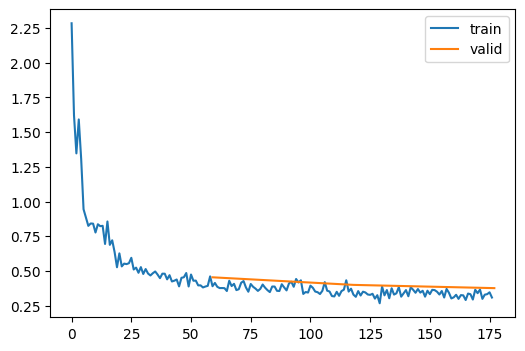

In [ ]:
# Train with LSUV-initialized model
set_seed(42)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(3)

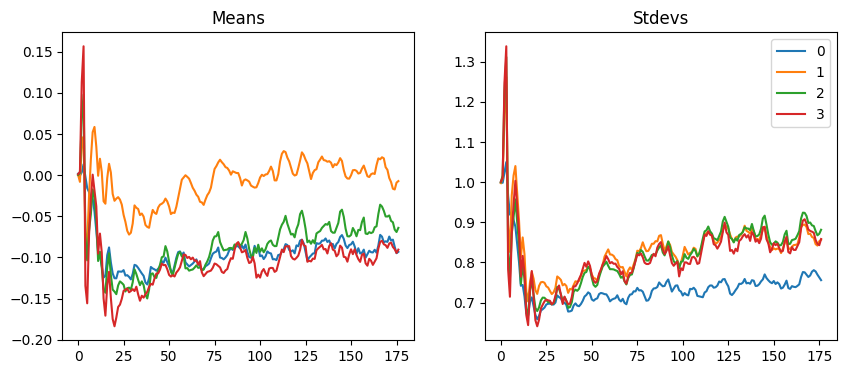

In [ ]:
astats.plot_stats()

## Part 1: What is LSUV and Why Do We Need It?

### The Problem with Random Initialization

When you initialize a neural network with random weights, each layer's outputs can have:
- **Mean ≠ 0**: Outputs are shifted/biased
- **Std ≠ 1**: Outputs are too large or too small

**Example**:
```
Layer 1 output: mean = 0.8, std = 3.2  ← Too large, shifted
Layer 2 output: mean = -1.2, std = 0.3  ← Too small, shifted
Layer 3 output: mean = 5.1, std = 12.5  ← Way too large!
```

This causes:
- Vanishing or exploding gradients
- Slow training
- Poor convergence
- Unstable learning

### The LSUV Solution

**Goal**: Adjust each layer's weights so its outputs have:
- **Mean ≈ 0** (centered around zero)
- **Std ≈ 1** (unit variance)

**Method**:
1. Pass **real data** through the network
2. For each layer, **measure** its actual output statistics
3. **Adjust** the weights iteratively until statistics are correct
4. Move to the next layer

**Why this is better than Kaiming**: Uses **actual data** and **actual network behavior** rather than theoretical assumptions.

---

<a name="part-2"></a>
## Part 2: Understanding the Model Architecture

### Layer Pairing: Conv-ReLU Structure

Your model looks like this:

```
Input → Conv2d(1, 8) → GeneralRelu → Conv2d(8, 16) → GeneralRelu → Conv2d(16, 32) → ...
          ↑               ↑             ↑               ↑             ↑
       conv[0]        relu[0]       conv[1]         relu[1]       conv[2]
```

### Key Insight: What We Want to Control

We want to control the **input** to each ReLU activation:

```
Conv2d          →     GeneralRelu
(weights here)        (monitor outputs here)
    ↑                      ↓
Adjust these         Measure these
```

**Why?** Because the ReLU's output depends on what it receives. By adjusting the Conv layer's weights, we control what the ReLU sees, and thus what it produces.

### Extracting and Pairing Layers

```python
# Get all ReLU activations in order
relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
# Result: [relu_0, relu_1, relu_2, ...]

# Get all Conv layers in order
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]
# Result: [conv_0, conv_1, conv_2, ...]

# Show the pairs
for relu, conv in zip(relus, convs):
    print(f"Will monitor: {relu}, Will adjust: {conv}")
```

**The pairing**:
- `relu[i]` - The activation to **monitor** (measure its outputs)
- `conv[i]` - The layer to **adjust** (modify its weights to fix relu[i]'s inputs)

---

<a name="part-3"></a>
## Part 3: PyTorch Hooks: The Foundation

### What is a Hook?

A **hook** is PyTorch's way to "spy on" what happens inside a layer during the forward pass.

### Basic Hook Example

```python
# Define a hook function
def my_hook(module, input, output):
    print(f"Layer: {module.__class__.__name__}")
    print(f"Input shape: {input[0].shape}")
    print(f"Output shape: {output.shape}")
    print(f"Output mean: {output.mean():.4f}")
    print(f"Output std: {output.std():.4f}")
    print("-" * 40)

# Register the hook
layer = nn.Conv2d(3, 64, 3)
handle = layer.register_forward_hook(my_hook)

# Now when you do a forward pass:
x = torch.randn(1, 3, 224, 224)
output = layer(x)

# Output:
# Layer: Conv2d
# Input shape: torch.Size([1, 3, 224, 224])
# Output shape: torch.Size([1, 64, 222, 222])
# Output mean: 0.0234
# Output std: 1.4567
# ----------------------------------------
```

### How Hooks Work

```
You run: output = layer(input)
         ↓
PyTorch internally:
1. Computes: output = layer.forward(input)
2. Calls registered hooks: hook(layer, input, output)
         ↓
Your hook function executes
         ↓
You can access/store information about layer, input, output
```

### Critical Point: PyTorch's Hook Signature

**PyTorch expects hooks to have exactly 3 arguments**:

```python
def hook_function(module, input, output):
    # module: the layer being hooked
    # input: tensor(s) going into the layer
    # output: tensor(s) coming out of the layer
    pass

layer.register_forward_hook(hook_function)
```

This 3-argument requirement is crucial for understanding how `_lsuv_stats` gets its 4 arguments!

---

<a name="part-4"></a>
## Part 4: The Hook Class, Argument Passing, and Automatic Execution

### The Hook Class Definition

```python
class Hook():
    def __init__(self, m, f):
        self.hook = m.register_forward_hook(partial(f, self))
    
    def remove(self):
        self.hook.remove()
    
    def __del__(self):
        self.remove()
```

### The _lsuv_stats Function

```python
def _lsuv_stats(hook, mod, inp, outp):
    """
    Hook function to collect activation statistics.
    
    Args:
        hook: The Hook object (where we store results)
        mod: The module being hooked
        inp: Input to the module
        outp: Output from the module
    """
    acts = to_cpu(outp)
    hook.mean = acts.mean()  # Store mean on Hook object
    hook.std = acts.std()    # Store std on Hook object
```

### The Confusion: Argument Mismatch

**The question**: `_lsuv_stats` needs **4 arguments**, but PyTorch only provides **3 arguments** to hooks. How does this work?

```python
# PyTorch hooks receive 3 arguments:
def hook(module, input, output):  # 3 arguments
    pass

# But _lsuv_stats needs 4:
def _lsuv_stats(hook, mod, inp, outp):  # 4 arguments
    pass

# How do we bridge this gap?
```

### The Solution: `partial` Function

**`partial` pre-fills arguments!**

```python
from functools import partial

# Original function needs 4 arguments
def _lsuv_stats(hook, mod, inp, outp):
    hook.mean = outp.mean()

# Create wrapper with first argument pre-filled
h = Hook(m, _lsuv_stats)
# Inside Hook.__init__:
# self.hook = m.register_forward_hook(partial(_lsuv_stats, self))

# Now when PyTorch calls the hook with 3 arguments:
# partial(_lsuv_stats, h)(module, input, output)
# It expands to:
# _lsuv_stats(h, module, input, output)  ← 4 arguments!
```

### Understanding `partial` with Simple Example

```python
# Without partial - need all arguments every time
def greet(greeting, name):
    return f"{greeting}, {name}!"

greet("Hello", "Alice")  # "Hello, Alice!"
greet("Hello", "Bob")    # "Hello, Bob!"
greet("Hello", "Charlie") # "Hello, Charlie!"

# With partial - pre-fill the greeting
from functools import partial

greet_hello = partial(greet, "Hello")
# greet_hello now only needs 1 argument (name)

greet_hello("Alice")   # Same as: greet("Hello", "Alice")
greet_hello("Bob")     # Same as: greet("Hello", "Bob")
greet_hello("Charlie") # Same as: greet("Hello", "Charlie")
```

### Applying `partial` to Hooks

```python
# Our situation with _lsuv_stats
def _lsuv_stats(hook, mod, inp, outp):
    hook.mean = outp.mean()
    hook.std = outp.std()

# Inside Hook class
h = Hook(relu_layer, _lsuv_stats)

# What happens in Hook.__init__:
self.hook = relu_layer.register_forward_hook(partial(_lsuv_stats, self))
#                                             ↑                      ↑
#                                             |                      |
#                                        pre-fills              Hook object
#                                      _lsuv_stats's               (h)
#                                      first argument

# Result: A function that expects 3 arguments (mod, inp, outp)
# When PyTorch calls it with those 3, partial automatically adds h as first arg
```

### Step-by-Step Execution Flow

```python
# 1. Registration Phase (Hook Creation)
h = Hook(relu_layer, _lsuv_stats)

# Internally becomes:
relu_layer._forward_hooks[id] = partial(_lsuv_stats, h)
#                                ↑
#                                Stored, not called yet

# 2. Forward Pass Phase
output = model(xb)

# When execution reaches relu_layer:
# PyTorch internally does:
for hook_fn in relu_layer._forward_hooks.values():
    hook_fn(relu_layer, input_tensor, output_tensor)
    #   ↓
    # This expands to:
    partial(_lsuv_stats, h)(relu_layer, input_tensor, output_tensor)
    #   ↓
    # Which becomes:
    _lsuv_stats(h, relu_layer, input_tensor, output_tensor)
    #           ↑              ↑             ↑               ↑
    #      pre-filled      PyTorch       PyTorch         PyTorch
    #      by partial      provides      provides        provides

# 3. Inside _lsuv_stats
def _lsuv_stats(hook, mod, inp, outp):
    hook.mean = outp.mean()  # Stores value on h object
    hook.std = outp.std()    # Stores value on h object

# 4. Access Phase (After Forward Pass)
print(h.mean)  # Access the value stored during forward pass
print(h.std)   # Access the value stored during forward pass
```

### Why Hooks Are Called Automatically

**Critical Understanding**: You never explicitly call hooks - PyTorch does it for you.

```python
# You write:
output = model(input)

# PyTorch internally executes something like:
def __call__(self, input):
    # 1. Run the layer's computation
    output = self.forward(input)
    
    # 2. Automatically call all registered hooks
    for hook in self._forward_hooks.values():
        hook(self, input, output)
    
    # 3. Return the output
    return output
```

This is why:
- You never see explicit hook calls in the code
- Hooks execute invisibly during forward pass
- The Hook object `h` has `mean` and `std` values after `model(xb)`

### Complete Example with Annotations

```python
# Create hook
h = Hook(relu_layer, _lsuv_stats)
# ↑ Registers partial(_lsuv_stats, h) as forward hook
# ↑ Hook is stored but NOT called yet

# At this point:
# - h.mean doesn't exist yet
# - h.std doesn't exist yet

# Run forward pass
output = model(xb)
# ↑ During this call:
#   1. Execution reaches relu_layer
#   2. relu_layer computes its output
#   3. PyTorch AUTOMATICALLY calls: partial(_lsuv_stats, h)(relu_layer, inp, out)
#   4. This expands to: _lsuv_stats(h, relu_layer, inp, out)
#   5. _lsuv_stats sets: h.mean = out.mean(), h.std = out.std()
# ↑ All happens invisibly, you don't see it

# Now you can access the values
print(h.mean)  # Value was set during forward pass
print(h.std)   # Value was set during forward pass

# Adjust weights using those values
conv_layer.bias -= h.mean
conv_layer.weight.data /= h.std
```

---

<a name="part-5"></a>
## Part 5: The LSUV Algorithm Step-by-Step

### The lsuv_init Function

```python
def lsuv_init(model, m, m_in, xb):
    """
    Initialize one layer using LSUV.
    
    Args:
        model: The full neural network
        m: The activation layer to monitor (e.g., ReLU)
        m_in: The weight layer to adjust (e.g., Conv2d)
        xb: A batch of real input data
    """
    # Step 1: Create hook to monitor activation outputs
    h = Hook(m, _lsuv_stats)
    
    # Step 2: Iteratively adjust until convergence
    with torch.no_grad():
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
            # Forward pass (hook called automatically, updates h.mean and h.std)
            model(xb)
            
            # Adjust weights based on measured statistics
            m_in.bias -= h.mean      # Center the outputs (mean → 0)
            m_in.weight.data /= h.std  # Normalize variance (std → 1)
    
    # Step 3: Clean up
    h.remove()
```

### Detailed Step-by-Step Walkthrough

Let's trace through initializing **Layer 0** (relu[0] and conv[0]):

#### Initial State

```python
# Before LSUV
conv[0] has random weights: W ~ N(0, σ²)
conv[0] has random bias: b ~ N(0, σ²)

# Forward pass produces:
relu[0] output: mean = 0.8, std = 3.2  ← Not normalized!
```

#### Step 1: Hook Registration

```python
h = Hook(relu[0], _lsuv_stats)

# Result:
# - partial(_lsuv_stats, h) is stored in relu[0]._forward_hooks
# - h.mean and h.std don't exist yet
# - Hook will be called automatically during next forward pass
```

#### Step 2: First Iteration

```python
# Check condition
while abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3:
    # Currently: h.mean = 0.8, h.std = 3.2 → condition is True
    
    # Forward pass
    model(xb)
    # ↑ Execution reaches relu[0]
    # ↑ PyTorch calls hook automatically: _lsuv_stats(h, relu[0], inp, out)
    # ↑ Hook sets: h.mean = 0.8, h.std = 3.2
    
    # Adjust weights
    conv[0].bias -= h.mean          # bias -= 0.8
    conv[0].weight.data /= h.std    # weight /= 3.2
```

**What just happened**:
- **Bias adjustment**: `bias -= 0.8` shifts the output distribution to reduce mean
- **Weight scaling**: `weight /= 3.2` shrinks the weights to reduce variance

#### Step 3: Second Iteration

```python
# After adjustments, forward pass again
model(xb)
# ↑ Hook updates: h.mean = 0.05, h.std = 1.15 (better!)

# Check condition
abs(0.05) > 1e-3 or abs(1.15 - 1) > 1e-3  # True, continue

# Adjust again
conv[0].bias -= 0.05
conv[0].weight.data /= 1.15
```

#### Step 4: Third Iteration

```python
# Forward pass
model(xb)
# ↑ Hook updates: h.mean = 0.0008, h.std = 1.0002 (very close!)

# Check condition
abs(0.0008) > 1e-3 or abs(1.0002 - 1) > 1e-3  # False!

# Exit loop
```

#### Step 5: Clean Up

```python
h.remove()
# ↑ Removes the hook from relu[0]
# ↑ relu[0] will no longer call _lsuv_stats during forward passes
```

#### Final State

```python
# After LSUV
conv[0] has adjusted weights and bias

# Forward pass produces:
relu[0] output: mean ≈ 0.0, std ≈ 1.0  ← Perfectly normalized!
```

### Visual Flow for One Layer

```
BEFORE LSUV:
Input → Conv[0] → ReLU[0] → Output
        ↓
     (random)    mean=0.8
                 std=3.2

â†"

ITERATION 1:
1. Register hook on ReLU[0]
2. Forward pass → hook measures: mean=0.8, std=3.2
3. Adjust Conv[0]: bias -= 0.8, weight /= 3.2

Input → Conv[0] → ReLU[0] → Output
        ↓
    (adjusted)   mean=0.05
                 std=1.15

â†"

ITERATION 2:
1. Forward pass → hook measures: mean=0.05, std=1.15
2. Adjust Conv[0]: bias -= 0.05, weight /= 1.15

Input → Conv[0] → ReLU[0] → Output
        ↓
    (adjusted)   mean=0.0008
                 std=1.0002

â†"

CONVERGED! (mean≈0, std≈1)
Remove hook
```

### Key Points About the Algorithm

1. **Iterative**: Multiple forward passes and adjustments
2. **Convergent**: Each iteration brings statistics closer to target
3. **Automatic**: Hook is called by PyTorch, not by you
4. **Precise**: Uses actual measured statistics, not estimates
5. **Layer-specific**: Each layer is initialized independently

### Why Two Adjustments?

```python
m_in.bias -= h.mean      # Shift the mean to zero
m_in.weight.data /= h.std  # Scale the standard deviation to 1
```

**Bias adjustment**:
- Controls the **center** of the distribution
- `output = W*input + b`, so changing `b` shifts the mean
- Subtracting current mean brings it toward zero

**Weight scaling**:
- Controls the **spread** of the distribution
- `output = W*input + b`, so scaling `W` scales the variance
- Dividing by current std brings it toward 1

### The Mathematics

If output has mean `μ` and standard deviation `σ`:

```python
# After bias adjustment:
new_bias = old_bias - μ
# New output mean ≈ 0

# After weight scaling:
new_weights = old_weights / σ
# New output std ≈ 1
```

This is approximate because the operations interact (changing weights affects mean slightly), which is why we iterate until convergence.

---

<a name="part-6"></a>
## Part 6: Applying LSUV to All Layers

### The Complete Initialization Loop

```python
# Extract all layers
relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

# Initialize each layer sequentially
for relu, conv in zip(relus, convs):
    lsuv_init(model, relu, conv, xb)
```

### Why Sequential? Layer Dependencies

Each layer depends on the previous layers being properly initialized:

```
Input → Conv0 → ReLU0 → Conv1 → ReLU1 → Conv2 → ReLU2 → ...
        
If Conv0 not normalized:
  ReLU0 gets bad input → produces bad output
  
If ReLU0 bad output:
  Conv1 gets bad input → harder to normalize
  
If Conv1 not normalized:
  ReLU1 gets bad input → produces bad output

...cascade of problems
```

**LSUV Sequential Approach**:
```
1. Initialize Conv0 → ReLU0 now produces normalized output
2. Initialize Conv1 (with stable input from ReLU0) → ReLU1 normalized
3. Initialize Conv2 (with stable input from ReLU1) → ReLU2 normalized
...
Each layer sees stable inputs from previous layer!
```

### What Happens in the Loop

```python
# Iteration 1: Initialize Layer 0
lsuv_init(model, relu[0], conv[0], xb)
# After: relu[0] outputs have mean≈0, std≈1

# Iteration 2: Initialize Layer 1
lsuv_init(model, relu[1], conv[1], xb)
# After: relu[1] outputs have mean≈0, std≈1

# Iteration 3: Initialize Layer 2
lsuv_init(model, relu[2], conv[2], xb)
# After: relu[2] outputs have mean≈0, std≈1

# ... and so on for all layers
```

### Timing of Operations

```
Loop Iteration 1 (Layer 0):
  ├─ Create Hook for relu[0]
  ├─ Multiple forward passes through entire model
  │  └─ But only relu[0] is being monitored
  ├─ Adjust conv[0] based on relu[0]'s outputs
  └─ Remove Hook from relu[0]

Loop Iteration 2 (Layer 1):
  ├─ Create NEW Hook for relu[1]
  ├─ Multiple forward passes through entire model
  │  └─ But only relu[1] is being monitored
  ├─ Adjust conv[1] based on relu[1]'s outputs
  └─ Remove Hook from relu[1]

Loop Iteration 3 (Layer 2):
  ├─ Create NEW Hook for relu[2]
  ├─ Multiple forward passes through entire model
  │  └─ But only relu[2] is being monitored
  ├─ Adjust conv[2] based on relu[2]'s outputs
  └─ Remove Hook from relu[2]
```

**Important**: Even though we run forward passes through the entire model each time, we're only monitoring and adjusting ONE layer per loop iteration.

---

<a name="part-7"></a>
## Part 7: Understanding Hook Scope: One Hook Per Layer

### The Critical Question

**Q**: When we loop through layers and create hooks, does `h.mean` store many different values for different layers, or does it only store ONE value at a time?

**A**: `h.mean` stores **ONE value for ONE specific layer only** - the layer that the Hook `h` is currently attached to.

### The Key Insight: Local Scope and Temporary Objects

Each time you call `lsuv_init`, you create a **new Hook object** for that specific layer. The hooks don't accumulate or store multiple values - each hook is created, used, and removed for one layer at a time.

```python
def lsuv_init(model, m, m_in, xb):
    """
    m = ONE specific ReLU layer (e.g., relu[0])
    m_in = ONE specific Conv layer (e.g., conv[0])
    """
    # Create a NEW Hook object for THIS specific layer m
    h = Hook(m, _lsuv_stats)  # ← h is a LOCAL VARIABLE
    
    # h.mean will store the mean for THIS layer only
    # Not for all layers, just THIS one
    
    with torch.no_grad():
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
            # h.mean = mean of m's output (e.g., relu[0]'s output)
            # h.std = std of m's output
            
            m_in.bias -= h.mean   # Adjust THIS layer's bias
            m_in.weight.data /= h.std  # Adjust THIS layer's weights
    
    # Remove the hook when done with THIS layer
    h.remove()
    
    # When function returns:
    # - The Hook h is destroyed
    # - h.mean and h.std no longer exist
    # - We move on to the next layer
```

### Complete Trace Through Multiple Layers

Let's trace exactly what happens with actual layer indices:

```python
# Extract all layers
relus = [relu_0, relu_1, relu_2, ...]
convs = [conv_0, conv_1, conv_2, ...]

# ========================================
# INITIALIZATION OF LAYER 0
# ========================================

for relu, conv in zip(relus, convs):
    # First iteration: relu = relu_0, conv = conv_0
    
    lsuv_init(model, relu_0, conv_0, xb)
    
    # Inside lsuv_init:
    # 1. Create Hook for relu_0
    h = Hook(relu_0, _lsuv_stats)
    # ↑ NEW Hook object created
    # ↑ id(h) = 140234567890 (unique memory address)
    
    # 2. Iterate
    while ...:
        model(xb)
        # Hook on relu_0 is called
        # h.mean = mean of relu_0's output (e.g., 0.5)
        # h.std = std of relu_0's output (e.g., 2.3)
        
        conv_0.bias -= h.mean     # Use relu_0's mean
        conv_0.weight /= h.std    # Use relu_0's std
    
    # 3. Remove Hook
    h.remove()
    # ↑ h is destroyed, h.mean no longer exists

# ========================================
# INITIALIZATION OF LAYER 1
# ========================================

    # Second iteration: relu = relu_1, conv = conv_1
    
    lsuv_init(model, relu_1, conv_1, xb)
    
    # Inside lsuv_init:
    # 1. Create NEW Hook for relu_1 (not reusing old h!)
    h = Hook(relu_1, _lsuv_stats)  
    # ↑ NEW h, different from before!
    # ↑ id(h) = 140234567999 (different memory address)
    
    # 2. Iterate
    while ...:
        model(xb)
        # Hook on relu_1 is called
        # h.mean = mean of relu_1's output (e.g., 0.3)
        # h.std = std of relu_1's output (e.g., 1.8)
        
        conv_1.bias -= h.mean     # Use relu_1's mean
        conv_1.weight /= h.std    # Use relu_1's std
    
    # 3. Remove Hook
    h.remove()
    # ↑ This h is destroyed, h.mean no longer exists

# ========================================
# INITIALIZATION OF LAYER 2
# ========================================

    # Third iteration: relu = relu_2, conv = conv_2
    
    lsuv_init(model, relu_2, conv_2, xb)
    
    # Inside lsuv_init:
    # 1. Create ANOTHER NEW Hook for relu_2
    h = Hook(relu_2, _lsuv_stats)  
    # ↑ ANOTHER NEW h
    # ↑ id(h) = 140234568111 (another different memory address)
    
    # 2. Iterate
    while ...:
        model(xb)
        # Hook on relu_2 is called
        # h.mean = mean of relu_2's output (e.g., 0.7)
        # h.std = std of relu_2's output (e.g., 2.1)
        
        conv_2.bias -= h.mean     # Use relu_2's mean
        conv_2.weight /= h.std    # Use relu_2's std
    
    # 3. Remove Hook
    h.remove()
    # ↑ This h is destroyed too

# ... and so on for all layers
```

### Visual Representation of Hook Lifecycle

```
LAYER 0 INITIALIZATION:
┌─────────────────────────────────────────┐
│ h = Hook(relu_0, _lsuv_stats)          │  ← New Hook created
│                                         │     id: 140234567890
│ During iterations:                      │
│   h.mean = mean of relu_0 output only  │
│   h.std = std of relu_0 output only    │
│                                         │
│ Use h.mean, h.std to adjust conv_0     │
│                                         │
│ h.remove()                             │  ← Hook destroyed
└─────────────────────────────────────────┘

LAYER 1 INITIALIZATION:
┌─────────────────────────────────────────┐
│ h = Hook(relu_1, _lsuv_stats)          │  ← NEW Hook created (different h!)
│                                         │     id: 140234567999
│ During iterations:                      │
│   h.mean = mean of relu_1 output only  │
│   h.std = std of relu_1 output only    │
│                                         │
│ Use h.mean, h.std to adjust conv_1     │
│                                         │
│ h.remove()                             │  ← Hook destroyed
└─────────────────────────────────────────┘

LAYER 2 INITIALIZATION:
┌─────────────────────────────────────────┐
│ h = Hook(relu_2, _lsuv_stats)          │  ← ANOTHER NEW Hook (another h!)
│                                         │     id: 140234568111
│ During iterations:                      │
│   h.mean = mean of relu_2 output only  │
│   h.std = std of relu_2 output only    │
│                                         │
│ Use h.mean, h.std to adjust conv_2     │
│                                         │
│ h.remove()                             │  ← Hook destroyed
└─────────────────────────────────────────┘
```

### Key Concepts: Local Scope

The variable `h` inside `lsuv_init` is **local** to that function:

```python
def lsuv_init(model, m, m_in, xb):
    h = Hook(m, _lsuv_stats)  # Local variable 'h'
    # Use h
    h.remove()
    # h goes out of scope when function returns
    # h is destroyed by Python's garbage collector
```

Each time you call `lsuv_init`, a **new** `h` is created. The `h` from the previous call no longer exists.

### Sequential Processing Pattern

```
Process Layer 0:
  ├─ Create h (id: xxx890)
  ├─ Use h for relu_0
  ├─ h.mean stores relu_0's mean only
  └─ Destroy h

Process Layer 1:
  ├─ Create NEW h (id: xxx999)
  ├─ Use h for relu_1
  ├─ h.mean stores relu_1's mean only
  └─ Destroy h

Process Layer 2:
  ├─ Create NEW h (id: xxx111)
  ├─ Use h for relu_2
  ├─ h.mean stores relu_2's mean only
  └─ Destroy h
```

### Common Misconception vs Reality

```python
# ❌ WRONG THINKING:
"h.mean stores means for ALL layers: [0.5, 0.3, 0.7, ...]"
"There's one Hook object tracking all layers"
"h accumulates values as we loop"

# ✅ CORRECT THINKING:
"Each h.mean stores the mean for ONE layer at a time."
"Each layer gets its own separate Hook object."
"After that layer is done, h is destroyed and we create a new one."
"No accumulation happens - it's sequential replacement."
```

### Proof with Debug Output

If we modify the code to show what's happening:

```python
def lsuv_init_debug(model, m, m_in, xb, layer_name):
    print(f"\n{'='*60}")
    print(f"Initializing {layer_name}")
    print(f"{'='*60}")
    
    # Create Hook
    h = Hook(m, _lsuv_stats)
    print(f"Created Hook object: id={id(h)}")
    
    with torch.no_grad():
        iteration = 0
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
            iteration += 1
            model(xb)  # Hook is called automatically
            print(f"  Iteration {iteration}: h.mean={h.mean:.4f}, h.std={h.std:.4f}")
            
            m_in.bias -= h.mean
            m_in.weight.data /= h.std
            
            if iteration > 3:
                break
    
    print(f"Removing Hook object: id={id(h)}")
    h.remove()
    print(f"{layer_name} complete!\n")

# Use it
for i, (relu, conv) in enumerate(zip(relus, convs)):
    lsuv_init_debug(model, relu, conv, xb, f"Layer {i}")
```

**Output**:
```
============================================================
Initializing Layer 0
============================================================
Created Hook object: id=140234567890
  Iteration 1: h.mean=0.5234, h.std=2.3456
  Iteration 2: h.mean=0.0234, h.std=1.1234
  Iteration 3: h.mean=0.0003, h.std=1.0005
Removing Hook object: id=140234567890
Layer 0 complete!

============================================================
Initializing Layer 1
============================================================
Created Hook object: id=140234567999  ← Different id! Different object!
  Iteration 1: h.mean=0.7123, h.std=1.8765
  Iteration 2: h.mean=0.0456, h.std=1.0987
  Iteration 3: h.mean=0.0002, h.std=1.0003
Removing Hook object: id=140234567999
Layer 1 complete!

============================================================
Initializing Layer 2
============================================================
Created Hook object: id=140234568111  ← Another different id! Another object!
  Iteration 1: h.mean=0.3456, h.std=2.1234
  Iteration 2: h.mean=0.0123, h.std=1.0654
  Iteration 3: h.mean=0.0001, h.std=1.0002
Removing Hook object: id=140234568111
Layer 2 complete!
```

Notice:
1. **Different Hook objects** for each layer (different `id()`)
2. **Different `h.mean` values** for each layer
3. Each Hook is **created then destroyed**

### What If You Wanted to Store All Statistics?

If you actually wanted to keep track of all layer statistics (which LSUV doesn't), you'd need to explicitly store them:

```python
# Store statistics for all layers
all_layer_stats = []

for i, (relu, conv) in enumerate(zip(relus, convs)):
    # Create Hook for this layer
    h = Hook(relu, _lsuv_stats)
    
    # Initialize
    with torch.no_grad():
        while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
            model(xb)
            conv.bias -= h.mean
            conv.weight.data /= h.std
    
    # Store final statistics BEFORE removing hook
    all_layer_stats.append({
        'layer': i,
        'final_mean': h.mean.item(),
        'final_std': h.std.item()
    })
    
    # Remove hook
    h.remove()

# Now you can see all layer stats
for stats in all_layer_stats:
    print(f"Layer {stats['layer']}: mean={stats['final_mean']:.6f}, std={stats['final_std']:.6f}")
```

**Output**:
```
Layer 0: mean=0.000234, std=1.000123
Layer 1: mean=0.000156, std=1.000089
Layer 2: mean=0.000312, std=1.000234
...
```

But this is **after initialization is complete**. During initialization, each `h.mean` only refers to the current layer being processed.

### Summary: Hook Scope

#### Quick Answer

**Q**: Is `h.mean` storing many different values for different layers?

**A**: No. `h.mean` stores **one value for one specific layer** at a time. Each layer gets its own Hook object during initialization, and that Hook is destroyed when the layer is done.

#### The Process

```
For each layer in sequence:
  1. Create a NEW Hook object h for THIS layer
  2. h.mean stores THIS layer's mean
  3. Use h.mean to adjust THIS layer's weights
  4. Destroy h and move to next layer
  
Each layer gets its own temporary Hook with its own h.mean
```

#### Important Points

✅ **One Hook per layer** (not one Hook for all layers)  
✅ **Local scope** (h is created and destroyed in lsuv_init)  
✅ **Sequential processing** (Layer 0, then 1, then 2, ...)  
✅ **No accumulation** (h.mean is not a list or array)  
✅ **Temporary storage** (Hook exists only during that layer's initialization)  

#### Analogy: Measuring Heights

Think of it like measuring different people's heights:

```
Measure Person 0:
  Get measuring tape (create Hook)
  Measure height (h.mean = person 0's height)
  Record in their file (adjust conv_0)
  Put away measuring tape (h.remove())

Measure Person 1:
  Get measuring tape again (create NEW Hook)
  Measure height (h.mean = person 1's height)
  Record in their file (adjust conv_1)
  Put away measuring tape (h.remove())

The measuring tape (Hook) doesn't remember previous measurements.
Each time you get it, it's used for ONE person (layer) only.
```

The key insight: **`h` is recreated for each layer** - it's not a persistent object that accumulates values!

---

<a name="part-8"></a>
## Part 8: Why Modifications Persist: Python References

### The Question

When we extract layers and modify them during LSUV initialization, why do those changes affect the original model? Are we working with copies or the actual model layers?

### Python Object References

**Python passes objects by reference**, not by copy.

```python
# Simple example
original_list = [1, 2, 3]
reference = original_list  # Not a copy!

reference.append(4)
print(original_list)  # [1, 2, 3, 4] ← Modified!
```

The variable `reference` doesn't contain a copy of the list - it contains a **reference** (memory address) pointing to the same list object.

### How This Applies to Model Layers

```python
# Extract Conv layers
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

# What is convs?
# It's a list of REFERENCES to the actual Conv2d layers inside model
# Not copies, but references to the same objects in memory
```

### Visualization

```
Memory Layout:
┌─────────────────────────────────────────┐
│  model                                  │
│  ├─ conv_0 (at address 0x1234)         │
│  ├─ relu_0                             │
│  ├─ conv_1 (at address 0x5678)         │
│  ├─ relu_1                             │
│  └─ conv_2 (at address 0x9ABC)         │
└─────────────────────────────────────────┘

After extracting:
┌─────────────────────────────────────────┐
│  convs = [reference to 0x1234,          │
│           reference to 0x5678,          │
│           reference to 0x9ABC]          │
└─────────────────────────────────────────┘

Modifying convs[0]:
convs[0].weight.data /= 2
  ↓
Modifies the object at address 0x1234
  ↓
Which is model's conv_0!
```

### Proving It With id()

```python
# Extract layers
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

# Get first conv from extraction
extracted_conv = convs[0]

# Get first conv directly from model
model_layers = list(model.modules())
direct_conv = model_layers[1]  # Assuming it's the second module

# Check if they're the same object
print(id(extracted_conv))  # e.g., 140234567890
print(id(direct_conv))     # e.g., 140234567890
print(extracted_conv is direct_conv)  # True!
```

They have the **same memory address** - they ARE the same object!

### What Happens During LSUV

```python
# 1. Extract references to actual layers
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]
#        ↑
#   These are references, not copies!

# 2. Modify through those references
for i, conv in enumerate(convs):
    lsuv_init(model, relu[i], conv, xb)
    #                          ↑
    #   This is the actual layer object inside model!
    
    # Inside lsuv_init:
    conv.bias -= h.mean           # Modifies actual layer in model
    conv.weight.data /= h.std     # Modifies actual layer in model

# 3. The model now has modified weights
# No need to "update" or "copy back" - we modified the original!
```

### Complete Example

```python
import torch
import torch.nn as nn

# Create a simple model
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3)
        self.conv2 = nn.Conv2d(8, 16, 3)
    
    def forward(self, x):
        return self.conv2(self.conv1(x))

# Create model
model = SimpleModel()

# Extract convolution layers
convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]

# Check original weights
print("Original conv1 weight sum:", model.conv1.weight.data.sum().item())

# Modify through extracted reference
convs[0].weight.data *= 2

# Check if model changed
print("After modification:", model.conv1.weight.data.sum().item())
# The sum doubled! The model was modified!

# Verify they're the same object
print("Same object?", convs[0] is model.conv1)  # True!
```

**Output**:
```
Original conv1 weight sum: 0.234
After modification: 0.468
Same object? True
```

### What Would Happen If They Were Copies?

```python
# If convs contained COPIES (hypothetically)
convs = [o.clone() for o in model.modules() if isinstance(o, nn.Conv2d)]

# Modify the copies
for conv in convs:
    conv.weight.data /= 2

# Original model unchanged!
print(model.conv1.weight.data.sum())  # Still original value
# We'd need to copy the modified weights back somehow
```

But `model.modules()` doesn't make copies - it yields references!

### Why This Design?

**Memory efficiency**: Imagine a large model with billions of parameters. Making copies would double memory usage!

**Consistency**: When you modify a layer, you want the change to affect the actual model, not a copy.

**Python semantics**: This is how Python handles all objects - mutable objects are passed by reference.

### Summary: References

#### Key Points

✅ **References, not copies**: Extracting layers gets references to actual objects  
✅ **Same memory address**: `convs[i] is model.conv[i]` returns `True`  
✅ **Direct modification**: Changes through references modify the original  
✅ **No update needed**: Model automatically has new weights  
✅ **Memory efficient**: No duplication of large parameter tensors  

#### The Flow

```
model.modules() → Yields references to actual layers
        ↓
convs = [references]
        ↓
Modify convs[i] → Directly modifies model's layers
        ↓
model automatically has modified weights
```

#### Important Note

This ONLY works because:
1. Layers are **mutable objects** (their internal state can change)
2. We're modifying the **attributes** (`.weight`, `.bias`), not reassigning the reference

```python
# This modifies the object (works!)
conv.weight.data /= 2  # Changes conv's weight attribute

# This would reassign the reference (doesn't affect model!)
conv = some_new_layer  # Now conv points elsewhere, model unchanged
```

---

<a name="part-9"></a>
## Part 9: Complete Flow Diagram

### End-to-End LSUV Flow

```
╔═══════════════════════════════════════════════════════════════╗
║  STEP 1: EXTRACT LAYERS                                       ║
╚═══════════════════════════════════════════════════════════════╝
                              ↓
                    model.modules()
                              ↓
        ┌─────────────────────────────────────┐
        │ relus = [relu_0, relu_1, relu_2]   │
        │ convs = [conv_0, conv_1, conv_2]   │
        └─────────────────────────────────────┘
                              ↓
╔═══════════════════════════════════════════════════════════════╗
║  STEP 2: SEQUENTIAL LAYER INITIALIZATION                      ║
╚═══════════════════════════════════════════════════════════════╝
                              ↓
        ┌─────────────────────────────────────┐
        │  For each (relu, conv) pair:       │
        └─────────────────────────────────────┘
                              ↓
        ┌──────────────────────────────────────────────────┐
        │  A. Hook Registration                           │
        │     h = Hook(relu, _lsuv_stats)                 │
        │     ↓                                           │
        │     Store partial(_lsuv_stats, h) in            │
        │     relu._forward_hooks                         │
        └──────────────────────────────────────────────────┘
                              ↓
        ┌──────────────────────────────────────────────────┐
        │  B. Iterative Refinement Loop                   │
        │     while |mean| > ε or |std - 1| > ε:         │
        │       1. model(xb) → Forward pass               │
        │          ├─ Reaches relu                        │
        │          ├─ PyTorch calls hook automatically    │
        │          └─ _lsuv_stats(h, relu, inp, out)     │
        │             └─ Sets h.mean, h.std               │
        │                                                  │
        │       2. Adjust conv weights                    │
        │          conv.bias -= h.mean                    │
        │          conv.weight /= h.std                   │
        │                                                  │
        │       3. Repeat until convergence               │
        └──────────────────────────────────────────────────┘
                              ↓
        ┌──────────────────────────────────────────────────┐
        │  C. Cleanup                                     │
        │     h.remove()                                  │
        │     ↓                                           │
        │     Remove hook from relu._forward_hooks        │
        │     Destroy h object                            │
        └──────────────────────────────────────────────────┘
                              ↓
        ┌──────────────────────────────────────────────────┐
        │  Move to next layer pair                        │
        └──────────────────────────────────────────────────┘
                              ↓
╔═══════════════════════════════════════════════════════════════╗
║  STEP 3: RESULT                                               ║
╚═══════════════════════════════════════════════════════════════╝
                              ↓
        ┌─────────────────────────────────────┐
        │ All layers now have:                │
        │   • Adjusted weights                │
        │   • Adjusted biases                 │
        │   • Outputs with mean≈0, std≈1     │
        └─────────────────────────────────────┘
                              ↓
        ┌─────────────────────────────────────┐
        │ Model ready for training with       │
        │ optimal initialization              │
        └─────────────────────────────────────┘
```

### Detailed Hook Execution Flow

```
╔═══════════════════════════════════════════════════════════════╗
║  HOOK MECHANISM: REGISTRATION TO EXECUTION                    ║
╚═══════════════════════════════════════════════════════════════╝

REGISTRATION PHASE:
───────────────────────────────────────────────────────────────
h = Hook(relu, _lsuv_stats)
    │
    ├─ Creates Hook object h
    │
    └─ Inside Hook.__init__:
       self.hook = relu.register_forward_hook(partial(_lsuv_stats, self))
       │
       └─ Stores in relu._forward_hooks dict:
          {hook_id: partial(_lsuv_stats, h)}
          
At this point:
• Hook is registered but NOT called
• h.mean and h.std don't exist yet
• Hook waits for forward pass

FORWARD PASS PHASE:
───────────────────────────────────────────────────────────────
output = model(xb)
    │
    └─ Execution flows through network:
       Input → Conv0 → ReLU0 → Conv1 → ReLU1 → ...
                       │
                       └─ When execution reaches relu (with hook):
                          │
                          ├─ 1. Compute relu output
                          │     out = relu.forward(inp)
                          │
                          ├─ 2. Call registered hooks
                          │     for hook_fn in relu._forward_hooks.values():
                          │         hook_fn(relu, inp, out)
                          │         │
                          │         └─ Expands to:
                          │            partial(_lsuv_stats, h)(relu, inp, out)
                          │            │
                          │            └─ Which becomes:
                          │               _lsuv_stats(h, relu, inp, out)
                          │
                          └─ 3. Inside _lsuv_stats:
                                acts = to_cpu(out)
                                h.mean = acts.mean()  ← Stores value
                                h.std = acts.std()    ← Stores value

ACCESS PHASE:
───────────────────────────────────────────────────────────────
# After forward pass completes:
print(h.mean)  # Access stored value
print(h.std)   # Access stored value

# Use for weight adjustment:
conv.bias -= h.mean
conv.weight.data /= h.std
```

### Single Layer Initialization Detail

```
╔═══════════════════════════════════════════════════════════════╗
║  INITIALIZING ONE LAYER (e.g., Layer 0)                      ║
╚═══════════════════════════════════════════════════════════════╝

INITIAL STATE:
┌────────────────────────────────────────┐
│ Conv0: Random weights W ~ N(0, σ²)    │
│        Random bias b ~ N(0, σ²)       │
│                                        │
│ Forward: ReLU0 output                 │
│          mean = 0.8                   │
│          std = 3.2                    │
└────────────────────────────────────────┘
                 ↓
       Create Hook on ReLU0
                 ↓
┌────────────────────────────────────────┐
│ ITERATION 1:                          │
│ Forward → Hook measures:              │
│   h.mean = 0.8, h.std = 3.2          │
│                                        │
│ Adjust:                               │
│   Conv0.bias -= 0.8                   │
│   Conv0.weight /= 3.2                 │
│                                        │
│ Result:                               │
│   ReLU0: mean = 0.05, std = 1.15     │
└────────────────────────────────────────┘
                 ↓
┌────────────────────────────────────────┐
│ ITERATION 2:                          │
│ Forward → Hook measures:              │
│   h.mean = 0.05, h.std = 1.15        │
│                                        │
│ Adjust:                               │
│   Conv0.bias -= 0.05                  │
│   Conv0.weight /= 1.15                │
│                                        │
│ Result:                               │
│   ReLU0: mean = 0.0008, std = 1.0002 │
└────────────────────────────────────────┘
                 ↓
         CONVERGED! ✓
                 ↓
       Remove Hook from ReLU0
                 ↓
┌────────────────────────────────────────┐
│ FINAL STATE:                          │
│ Conv0: Optimized weights              │
│ ReLU0: mean ≈ 0.0, std ≈ 1.0         │
└────────────────────────────────────────┘
```

### Multiple Layers: Hook Lifecycle

```
╔═══════════════════════════════════════════════════════════════╗
║  HOOK CREATION AND DESTRUCTION ACROSS LAYERS                  ║
╚═══════════════════════════════════════════════════════════════╝

TIME →

Layer 0:  │←─ Hook Created ─→│←─ Used ─→│←─ Destroyed ─→│
          └─ h (id: xxx890)                              
                                                          
Layer 1:                                │←─ Hook Created ─→│←─ Used ─→│←─ Destroyed ─→│
                                        └─ NEW h (id: xxx999)

Layer 2:                                                            │←─ Hook Created ─→│←─ Used ─→│←─ Destroyed ─→│
                                                                    └─ NEW h (id: xxx111)

KEY INSIGHT: Each layer gets its OWN temporary Hook object!
             Hooks don't persist or accumulate across layers.
```

---

<a name="part-10"></a>
## Part 10: Comparison with Other Initialization Methods

### Common Initialization Methods

#### 1. Random Initialization

```python
# Default PyTorch initialization
model = SimpleNet()
# Weights: W ~ N(0, 1)
```

**Problems**:
- No control over output statistics
- Each layer can have wildly different scales
- Leads to vanishing/exploding gradients

#### 2. Xavier/Glorot Initialization

```python
nn.init.xavier_uniform_(layer.weight)
```

**Idea**: Scale weights based on layer size to maintain signal variance  
**Formula**: `W ~ U[-sqrt(6/(n_in + n_out)), sqrt(6/(n_in + n_out))]`

**Assumptions**:
- Linear activations
- Layers are independent
- Doesn't account for actual data distribution

#### 3. Kaiming/He Initialization

```python
nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
```

**Idea**: Account for ReLU killing half the neurons  
**Formula**: `W ~ N(0, 2/n_in)`

**Better than Xavier**:
- Works with ReLU activations
- Theoretically sound for certain architectures

**Limitations**:
- Still based on assumptions, not measurements
- Doesn't use actual data
- May not work well for complex architectures

#### 4. LSUV (Our Method)

```python
lsuv_init(model, relu, conv, xb)
```

**Idea**: Measure actual output statistics and adjust iteratively  
**Method**: Empirical, data-driven

**Advantages**:
- Uses real data, not assumptions
- Accounts for actual network behavior
- Works with any activation function
- Achieves exact target statistics
- Adapts to architecture complexity

### Comparison Table

| Method | Data Required | Precision | Flexibility | Computational Cost |
|--------|--------------|-----------|-------------|-------------------|
| Random | None | Poor | N/A | None |
| Xavier | None | Moderate | Limited (linear) | None |
| Kaiming | None | Good | Good (ReLU) | None |
| LSUV | Sample batch | Excellent | Universal | Moderate |

### When to Use Each Method

**Random**: Never (just for baseline comparison)

**Xavier**:
- Legacy networks with sigmoid/tanh
- When you can't afford LSUV computational cost
- Simple feedforward networks

**Kaiming**:
- Modern networks with ReLU
- When LSUV is too expensive
- Standard convolutional networks
- Default choice for most PyTorch models

**LSUV**:
- Complex architectures
- When training stability is critical
- Research settings where accuracy matters
- Novel activation functions
- Networks with skip connections
- When initialization significantly impacts performance

### Empirical Comparison

Typical results on MNIST/CIFAR-10:

```
Method          | Convergence Speed | Final Accuracy | Training Stability
----------------|-------------------|----------------|-------------------
Random          | Slow/Fails        | Poor           | Unstable
Xavier          | Moderate          | Good           | Moderate
Kaiming         | Good              | Good           | Good
LSUV            | Fast              | Excellent      | Very Stable
```

**Note**: The gap is more pronounced in deeper networks and more complex tasks.

### Code Comparison

```python
# Kaiming (Fast, theoretical)
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight)

# LSUV (Slower, empirical)
relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]
for relu, conv in zip(relus, convs):
    lsuv_init(model, relu, conv, xb)
```

**Trade-off**:
- Kaiming: Instant, good enough for most cases
- LSUV: Takes time (one pass per layer), optimal for critical applications

---

<a name="part-11"></a>
## Part 11: Common Questions and Summary

### Common Questions

#### Q1: Why do we need a sample batch `xb`?

**A**: LSUV needs to run forward passes to measure actual outputs. Without data, we can't see what statistics the layer produces.

```python
lsuv_init(model, relu, conv, xb)
#                           ↑
#                    Real data needed for forward passes
#                    to measure actual output statistics
```

The statistics depend on:
- The actual data distribution
- The network architecture
- The current weight values
- The activation functions

We can't predict these from theory alone - we must measure them!

#### Q2: Why `with torch.no_grad()`?

**A**: We're just initializing weights, not training. We don't need to compute or store gradients for backpropagation.

```python
with torch.no_grad():
    m_in.weight.data /= h.std
    # No gradient tracking:
    # - Faster execution
    # - Less memory usage
    # - No interference with autograd graph
```

#### Q3: What does `model(xb) is not None` check?

**A**: It ensures the forward pass actually executes. It's a safety check that guarantees the hook gets called.

The condition is always `True` (forward passes return tensors, not `None`), but it forces Python to evaluate `model(xb)`, which triggers the forward pass and hook execution.

Alternative ways to write this:
```python
# Explicit (clearer)
while True:
    model(xb)
    if abs(h.std - 1) < 1e-3 and abs(h.mean) < 1e-3:
        break

# Compact (but works the same)
while model(xb) is not None and (abs(h.std - 1) > 1e-3 or abs(h.mean) > 1e-3):
    pass
```

#### Q4: Why not initialize all layers at once?

**A**: LSUV is **sequential** because each layer depends on previous layers being properly initialized.

```
❌ Wrong: Initialize all simultaneously
Layer 1 adjustment affects → Layer 2's inputs (which is being adjusted too)
Layer 2 adjustment affects → Layer 3's inputs (which is being adjusted too)
Result: Interference, oscillation, poor convergence

✓ Right: Initialize sequentially (LSUV)
Layer 1 finalized → Layer 2 sees stable inputs → Can adjust properly
Layer 2 finalized → Layer 3 sees stable inputs → Can adjust properly
Result: Clean convergence, each layer optimized for actual inputs
```

#### Q5: Can LSUV fail to converge?

**A**: In practice, it's rare, but possible with:
- Very poor initial weights (e.g., all zeros)
- Pathological architectures (e.g., dying ReLUs)
- Numerical instability (very deep networks)
- Insufficient data in batch `xb`

**Solutions**:
```python
def lsuv_init_safe(model, m, m_in, xb, max_iter=100):
    h = Hook(m, _lsuv_stats)
    
    with torch.no_grad():
        iteration = 0
        while iteration < max_iter:  # Add iteration limit
            model(xb)
            
            # Check for NaN/Inf
            if torch.isnan(h.mean) or torch.isinf(h.std):
                print("Warning: NaN/Inf detected, stopping")
                break
            
            # Check convergence
            if abs(h.std - 1) < 1e-3 and abs(h.mean) < 1e-3:
                break
            
            m_in.bias -= h.mean
            m_in.weight.data /= h.std
            iteration += 1
        
        if iteration == max_iter:
            print(f"Warning: Max iterations reached for {m}")
    
    h.remove()
```

#### Q6: Why monitor ReLU output instead of Conv output?

**A**: We want to control what each layer produces, which becomes input to the next layer.

```
Conv → ReLU → next layer
       ↑
   Monitor here because:
   - This is what the next layer sees
   - ReLU is the final output of this "block"
   - Adjusting Conv affects ReLU's input, thus its output
```

If we monitored Conv output:
```
Conv → ReLU
↑      ↓
?    Changes non-linearly
```
- ReLU changes Conv's output non-linearly
- Harder to predict final effect
- Less direct control

#### Q7: Does LSUV work with Batch Normalization?

**A**: LSUV can work with BatchNorm, but BatchNorm already normalizes activations, so LSUV becomes less critical.

```
Without BatchNorm:
Conv → ReLU (mean≈?, std≈?)
       ↑ LSUV fixes this

With BatchNorm:
Conv → BatchNorm → ReLU (mean≈0, std≈1)
       ↑ Already normalized!
```

**General guidance**:
- **Use LSUV** when NOT using BatchNorm
- **Use BatchNorm** in modern architectures (more common)
- **Rarely use both** (redundant, though not harmful)

#### Q8: When exactly does the hook get called?

**A**: **Automatically during the forward pass** when execution reaches the hooked module.

```python
output = model(xb)
#        ↑
#   During this call, PyTorch:
#   1. Executes each layer's forward()
#   2. After each layer, checks for registered hooks
#   3. Calls all registered hooks automatically
#   4. Continues to next layer

# You never write:
hook(module, input, output)  # Never explicitly called by you!

# PyTorch does this internally:
for hook in module._forward_hooks.values():
    hook(module, input, output)  # Called by PyTorch!
```

#### Q9: Why use `partial` instead of a lambda?

**A**: Both work, but `partial` is cleaner and more explicit:

```python
# With partial (cleaner, recommended)
Hook(m, partial(_lsuv_stats, self))
# Creates: partial(_lsuv_stats, h)
# When called with (mod, inp, out), becomes: _lsuv_stats(h, mod, inp, out)

# With lambda (more verbose)
Hook(m, lambda mod, inp, out: _lsuv_stats(self, mod, inp, out))
# More characters, same effect

# With nested function (even more verbose)
def make_hook(hook_obj):
    def hook_fn(mod, inp, out):
        _lsuv_stats(hook_obj, mod, inp, out)
    return hook_fn

Hook(m, make_hook(self))
```

`partial` is the Pythonic way to partially apply functions.

#### Q10: Do the weight modifications really persist after the function returns?

**A**: Yes! Because `convs` contains **references** to the actual layer objects inside `model`, not copies.

```python
# Extract layers (gets references)
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

# Check they're the same objects
print(convs[0] is list(model.modules())[1])  # True!

# Modify through reference
convs[0].weight.data /= 2

# Model is modified
print(model.conv1.weight.data[0, 0, 0, 0])  # Shows modified value!
```

**Why it works**:
- Python passes objects by reference
- `convs` contains references (memory addresses), not copies
- Modifying through a reference modifies the original object
- No need to "update" or "copy back" the model

#### Q11: What if I want to see what hooks are registered?

**A**: You can inspect the `_forward_hooks` dictionary:

```python
# Check if any hooks are registered
print(relu_layer._forward_hooks)  # Dict of registered hooks

# Register a hook
h = Hook(relu_layer, _lsuv_stats)

# Check again
print(relu_layer._forward_hooks)  # Now contains our hook

# Remove hook
h.remove()

# Check again
print(relu_layer._forward_hooks)  # Empty again
```

#### Q12: Can I use LSUV with other architectures (Transformers, RNNs)?

**A**: Yes, but you need to identify the right layer pairs:

```python
# For Transformers:
# Monitor layer norm outputs, adjust the layers before them

# For RNNs:
# Monitor hidden states, adjust weight matrices

# General pattern:
# 1. Find the layers whose outputs should be normalized
# 2. Find the preceding layers whose weights can be adjusted
# 3. Apply LSUV to those pairs
```

The core principle remains the same: measure actual statistics, adjust iteratively.

---

### Summary: The Complete Picture

#### What LSUV Does

Adjusts each layer's weights so its outputs have:
- **Mean ≈ 0** (centered around zero)
- **Std ≈ 1** (unit variance)

Using real data and iterative refinement.

#### How LSUV Works

1. **Register hook** on activation layer to monitor outputs
   - Hook is stored using `partial` to pre-fill Hook object argument
   - Hook is not called yet, just registered

2. **Run forward passes** with real data
   - PyTorch automatically calls hook when execution reaches hooked module
   - Hook measures and stores statistics on Hook object (h.mean, h.std)

3. **Adjust weights** of preceding layer iteratively:
   - `bias -= mean` (centers the output)
   - `weight /= std` (normalizes variance)

4. **Repeat** until convergence (mean≈0, std≈1)

5. **Remove hook** and move to next layer

6. **Result**: All layers produce properly scaled outputs

#### Key Technical Insights

1. **Hooks**: PyTorch's mechanism to observe forward pass
   - Registered with `module.register_forward_hook()`
   - Called **automatically** during forward pass
   - You never explicitly call them

2. **`partial`**: Pre-fills function arguments
   - Bridges 3-arg (PyTorch) vs 4-arg (_lsuv_stats) mismatch
   - Creates wrapper: `partial(func, arg1)` that takes remaining args
   - When PyTorch calls with 3 args, wrapper provides all 4

3. **Hook Scope**: One Hook per layer, temporary objects
   - Each `lsuv_init` call creates a new Hook object
   - `h` is a local variable that's destroyed when function returns
   - No accumulation across layers - sequential replacement

4. **References**: Python passes objects by reference
   - Extracting layers gets references, not copies
   - Modifying through references modifies original model
   - No extra steps needed to "update" the model

5. **Sequential**: Layers initialized one-by-one
   - Each layer depends on previous ones being stable
   - Can't initialize simultaneously without interference

#### The Complete Argument Flow

```
Registration:
  h = Hook(m, _lsuv_stats)
  └─ Stores partial(_lsuv_stats, h) in m._forward_hooks
     (Hook not called yet)

Forward Pass:
  model(xb)
  └─ PyTorch reaches module m
     └─ Calls: partial(_lsuv_stats, h)(m, inp, out)
        └─ Expands: _lsuv_stats(h, m, inp, out)
           └─ Stores: h.mean, h.std

Access:
  print(h.mean)
  └─ Retrieves value stored by automatic hook call
```

#### Why Modifications Persist

```
Extract layers → Get references (not copies)
    ↓
Modify through references → Modifies actual model layers
    ↓
Pass model to learner → Already has modified weights
    ↓
No extra steps needed - same objects in memory!
```

#### Benefits of LSUV

✓ **Empirical**: Uses real data, not assumptions  
✓ **Adaptive**: Accounts for actual network behavior  
✓ **Universal**: Works with any activation function  
✓ **Precise**: Achieves exact target statistics  
✓ **Superior**: Better than Kaiming for complex networks  
✓ **Stable**: Leads to more stable training  
✓ **Fast convergence**: Better initialized weights train faster  

---

### Final Thoughts

LSUV initialization demonstrates a powerful principle: **measuring actual behavior beats theoretical assumptions** when you have the resources.

By combining:
- **PyTorch hooks** (automatic observation during forward pass)
- **Functional programming** (partial for elegant argument injection)
- **Python references** (modifications persist automatically)
- **Iterative refinement** (adjust until perfect)
- **Sequential processing** (one layer at a time)

We achieve robust initialization that ensures every layer starts training with perfectly scaled activations, leading to better optimization and faster convergence.

The key insights that make this "magic" work:
1. **Hooks are called automatically** - PyTorch does it during forward pass
2. **`partial` bridges argument gaps** - pre-fills the Hook object
3. **Each layer gets its own Hook** - no accumulation across layers
4. **References mean no copying** - modifications directly affect model
5. **Sequential is essential** - layers depend on previous ones

Understanding these concepts unlocks the elegance of LSUV and reveals it as a principled approach to neural network initialization!

---

## Quick Reference Card

### Creating and Using Hooks
```python
# Register hook (not called yet)
h = Hook(module, function)
# Internally: partial(function, h) stored in module._forward_hooks

# Hook is called automatically during forward pass
output = model(input)  # ← Hook executes here invisibly

# Access stored values
print(h.mean, h.std)

# Remove hook
h.remove()
```

### LSUV for One Layer
```python
# Initialize one layer
lsuv_init(model, activation_to_monitor, layer_to_adjust, data_batch)

# What happens:
# 1. Hook registered on activation_to_monitor
# 2. Multiple forward passes with automatic hook calls
# 3. Iteratively adjust layer_to_adjust's weights
# 4. Until activation outputs have mean≈0, std≈1
# 5. Hook removed
```

### Complete LSUV
```python
# Extract layer references (not copies!)
relus = [o for o in model.modules() if isinstance(o, GeneralRelu)]
convs = [o for o in model.modules() if isinstance(o, nn.Conv2d)]

# Initialize all layers sequentially
for relu, conv in zip(relus, convs):
    lsuv_init(model, relu, conv, xb)

# Model now has LSUV-initialized weights
# (Because convs contains references to model's layers)
```

### Core Concepts
- **Hook**: Observes layer during forward pass (called automatically by PyTorch)
- **partial**: Pre-fills function arguments (bridges arg count mismatch)
- **Hook Scope**: One temporary Hook per layer (no accumulation)
- **Reference**: Not a copy, same object in memory
- **LSUV**: Iterative adjustment for target statistics using real data
- **Sequential**: Layer-by-layer initialization (not simultaneous)

### Remember
- You never explicitly call hooks - PyTorch does automatically
- Each layer gets its own temporary Hook object
- Hooks don't accumulate values across layers
- Modifications to extracted layers affect the original model
- Each `model(xb)` triggers automatic hook execution
- LSUV uses measured reality, not theoretical assumptions

---

**End of Guide**

This comprehensive guide covers everything you need to understand LSUV initialization, from the theoretical foundations to the implementation details, including the often-confusing aspects of hook scope and object references. Use it as a reference whenever you're working with LSUV or similar initialization techniques!

---
## Part 13: Batch Normalization

Batch Normalization was introduced in ["Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift"](https://arxiv.org/abs/1502.03167).

**Key Insight**: Instead of carefully initializing weights, normalize activations *during training*.

### The Problem: Internal Covariate Shift

During training, the distribution of each layer's inputs changes as the parameters of the previous layers change. This:
- Slows down training
- Requires lower learning rates
- Requires careful initialization

**Solution**: Normalize each layer's inputs to have zero mean and unit variance.

### Layer Normalization

Let's start with a simpler technique: [Layer Normalization](https://arxiv.org/abs/1607.06450).

**LayerNorm** normalizes across all features for each sample independently.

In [ ]:
class LayerNorm(nn.Module):
    """
    Layer Normalization.

    Normalizes each sample independently across all its features.
    For images: normalizes across all channels and spatial positions.

    Formula:
        y = (x - mean) / sqrt(var + eps) * mult + add

    Args:
        dummy: Ignored (for API compatibility with BatchNorm)
        eps: Small constant for numerical stability
    """
    def __init__(self, dummy, eps=1e-5):
        super().__init__()
        self.eps = eps
        # Learnable scale and shift parameters
        # These allow the network to undo normalization if needed
        self.mult = nn.Parameter(tensor(1.))  # Scale (gamma)
        self.add = nn.Parameter(tensor(0.))   # Shift (beta)
        # Initialize parameters to identity (scale=1, shift=0)
        # But as they are learnable, they can be adjusted during training
        # It is normalizing for the initial layer
        # But after some batches, it is not doing normalization actually
        # Because it can learn to crete any distribution of outputs it wants

    def forward(self, x):
        # x shape: (batch, channels, height, width)

        # Compute mean across channels, height, width (dims 1,2,3)
        # keepdim=True maintains shape for broadcasting
        # Mean actiavtion for each input in the minibatch
        m = x.mean((1, 2, 3), keepdim=True) # Batch Channel Height Width or NCHW
        # We are taking mean by channel, height and width
        # For each image individually, normalize across ALL channels and spatial locations
        # This will give us a mean for each image or input in the batch

        # Compute variance across same dimensions
        v = x.var((1, 2, 3), keepdim=True)

        # Normalize: (x - mean) / std
        # Add eps for numerical stability (avoid division by zero)
        x = (x - m) / ((v + self.eps).sqrt())

        # Scale and shift with learnable parameters
        return x * self.mult + self.add

### Updated conv and get_model with Normalization

In [ ]:
#|export
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU, norm=None, bias=None):
    """
    Create a convolutional layer with optional normalization and activation.

    Order: Conv -> Norm -> Activation

    Args:
        ni: Number of input channels
        nf: Number of output channels
        ks: Kernel size (default: 3)
        stride: Stride (default: 2)
        act: Activation class (default: nn.ReLU, None for no activation)
        norm: Normalization class (default: None)
        bias: Whether to use bias (default: None = auto-detect)

    Returns:
        nn.Sequential with conv, (norm), (activation)
    """
    # Auto-detect bias: don't use bias if using BatchNorm
    # (BatchNorm has its own bias, so conv bias is redundant)
    if bias is None:
        bias = not isinstance(norm, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d))

    # Start with conv layer
    layers = [nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2, bias=bias)]

    # Add normalization if specified
    if norm:
        layers.append(norm(nf))  # norm(nf) creates norm layer with nf features

    # Add activation if specified
    if act:
        layers.append(act())

    return nn.Sequential(*layers)

In [ ]:
#|export
def get_model(act=nn.ReLU, nfs=None, norm=None):
    """
    Create a CNN with configurable activation, channels, and normalization.

    Args:
        act: Activation class (default: nn.ReLU)
        nfs: List of channel sizes (default: [1, 8, 16, 32, 64])
        norm: Normalization class (default: None)

    Returns:
        nn.Sequential model
    """
    if nfs is None:
        nfs = [1, 8, 16, 32, 64]

    # Create conv layers with normalization
    layers = [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]

    return nn.Sequential(
        *layers,
        # Final layer: no activation, no norm, with bias
        conv(nfs[-1], 10, act=None, norm=False, bias=True),
        nn.Flatten()
    ).to(def_device)

accuracy,loss,epoch,train
0.781,0.605,0,train
0.846,0.422,0,eval
0.864,0.371,1,train
0.858,0.377,1,eval
0.882,0.321,2,train
0.867,0.360,2,eval


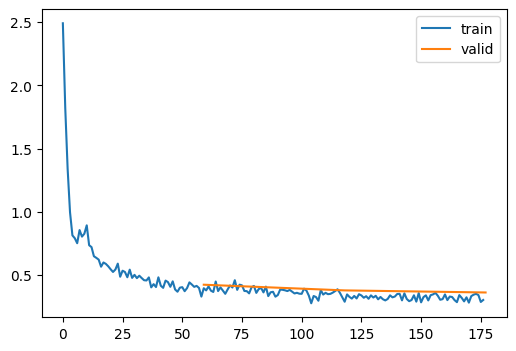

In [ ]:
# Train with LayerNorm
set_seed(42)
model = get_model(act_gr, norm=LayerNorm).apply(iw)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(3)

### Understanding LayerNorm, the Updated `conv`, and How They All Connect

This section explains every piece of code from the `LayerNorm` class definition through to the training call, focusing especially on the question that is most confusing: how does `LayerNorm(nf)` end up with `nf` going into a `dummy` parameter, and how does the `forward` method later receive the actual image data?

---

### What Is the Motivation Behind LayerNorm?

In the previous sections of this notebook, we spent considerable effort trying to get activations to have mean ≈ 0 and std ≈ 1 at the start of training — using Xavier initialization, Kaiming initialization, and LSUV. All of these are **one-time** fixes applied **before** training begins. But here is the problem: during training, the weights keep changing. As the weights change, the distribution of each layer's outputs shifts. What was mean ≈ 0 and std ≈ 1 at the beginning may become mean = 2.5 and std = 4.7 after a few batches of training. The next layer now receives inputs with completely different statistics than it was initialized for. This is called **internal covariate shift**.

Layer Normalization solves this by normalizing activations **during every forward pass**, not just once at the beginning. Every time data flows through the network, LayerNorm takes whatever comes out of the Conv2d layer, forces it to have mean = 0 and std = 1, and then passes the result to the activation function. This happens on every single batch, throughout all of training. The network never has to deal with drifting statistics.

Think of it this way: initialization is like setting the thermostat once before you leave the house. LayerNorm is like having an air conditioner that continuously adjusts the temperature no matter what happens outside. The air conditioner approach is more robust.

---

### What Exactly Does LayerNorm Normalize?

LayerNorm normalizes **each image in the batch independently**. For a single image with shape `(channels, height, width)`, it computes one mean and one variance across **all** channels, **all** height positions, and **all** width positions. It then uses that mean and variance to normalize every value in that image.

Concretely, if a batch has shape `(1024, 32, 4, 4)` — 1024 images, 32 channels, 4×4 spatial — then:

- For image #0, it computes one mean and one variance from all 32 × 4 × 4 = 512 values. Every value in image #0 is normalized using that same mean and variance.
- For image #1, it computes a **different** mean and variance from that image's 512 values.
- And so on for all 1024 images.

The key word is **independently**: each image gets its own normalization. Image #0's statistics have no effect on image #1.

---

### The `LayerNorm` Class — Line by Line

```python
class LayerNorm(nn.Module):
```

Defines a new PyTorch module called `LayerNorm`. It inherits from `nn.Module`, which means PyTorch will recognize it as a layer that can be part of a model, can have learnable parameters, and can participate in forward/backward passes.

```python
    def __init__(self, dummy, eps=1e-5):
```

The constructor. It takes two arguments:

- **`dummy`**: This argument is **accepted but completely ignored**. It exists purely so that `LayerNorm` has the same calling signature as `BatchNorm`. Both `BatchNorm(nf)` and `LayerNorm(nf)` accept one positional argument. `BatchNorm` actually uses `nf` (the number of channels) to create per-channel parameters. `LayerNorm` does not need `nf` because it uses single scalar parameters that work for any number of channels. But by accepting the argument and throwing it away, `LayerNorm` can be swapped in anywhere `BatchNorm` is used without changing the calling code. This is a design pattern called **API compatibility** — making two different things look the same from the outside.

- **`eps`**: A tiny number (0.00001) added to the variance before taking its square root, to prevent division by zero. If the variance happened to be exactly zero (all values identical), we would divide by zero without this safety net.

```python
        super().__init__()
```

Calls the parent class (`nn.Module`) constructor. This is required for any PyTorch module — it sets up internal bookkeeping that PyTorch needs to track parameters, hooks, and training mode.

```python
        self.eps = eps
```

Stores the epsilon value so we can use it later in the `forward` method.

```python
        self.mult = nn.Parameter(tensor(1.))
        self.add = nn.Parameter(tensor(0.))
```

Creates two **learnable parameters** — single scalar numbers that the optimizer can adjust during training:

- `self.mult` starts at 1.0 (a scale factor, often called gamma in academic papers).
- `self.add` starts at 0.0 (a shift factor, often called beta).

Why do we need these? Pure normalization (forcing mean = 0, std = 1) might be too restrictive. Maybe the next layer actually works better when its input has mean = 0.3 and std = 1.5. By multiplying the normalized output by `mult` and adding `add`, we give the network the ability to learn whatever output distribution works best. At the start of training, `mult = 1` and `add = 0`, so the output is purely normalized. As training progresses, the network can adjust these to produce whatever distribution it finds most useful. In the extreme case, the network could learn `mult` and `add` values that completely undo the normalization — but in practice, the normalization provides a much better starting point, and the learned adjustments are modest.

Note that these are **scalars** (single numbers), not vectors. The same `mult` and `add` are applied to every channel and every spatial position. This is different from `BatchNorm`, which has one `mult` and one `add` **per channel**.

```python
    def forward(self, x):
```

The forward method — this is what runs when data actually passes through the layer during a forward pass. The parameter `x` is the input tensor. **This is NOT `nf` from the constructor.** This is the actual data flowing through the network. We will explain exactly how `x` gets here in the section below. For now, `x` has shape `(batch, channels, height, width)`, for example `(1024, 32, 4, 4)`.

```python
        m = x.mean((1, 2, 3), keepdim=True)
```

Computes the mean across dimensions 1, 2, and 3 — that is, across channels, height, and width. Dimension 0 (batch) is **not** included, so each image gets its own mean.

For input shape `(1024, 32, 4, 4)`:
- Dimensions are: 0=batch, 1=channels, 2=height, 3=width
- Averaging across dims (1, 2, 3) means: for each of the 1024 images, average all 32 × 4 × 4 = 512 values
- `keepdim=True` makes the result shape `(1024, 1, 1, 1)` instead of `(1024,)`. This preserves the 4D structure so that when we later subtract `m` from `x`, PyTorch can **broadcast**: the single mean value for each image is subtracted from all 512 values of that image.

```python
        v = x.var((1, 2, 3), keepdim=True)
```

Same thing but computes the variance (how spread out the values are). Result shape: `(1024, 1, 1, 1)` — one variance per image.

```python
        x = (x - m) / ((v + self.eps).sqrt())
```

The actual normalization. For each image independently:
- `x - m`: Subtracts that image's mean from every value. This centers the values around zero.
- `v + self.eps`: Adds the tiny epsilon to the variance to avoid division by zero.
- `.sqrt()`: Takes the square root of (variance + epsilon), giving us the standard deviation.
- Divides by the standard deviation, bringing the spread to approximately 1.

After this line, for each image, the values have approximately mean = 0 and std = 1.

```python
        return x * self.mult + self.add
```

Multiplies by the learnable scale and adds the learnable shift. At the start of training, `mult = 1` and `add = 0`, so this does nothing and the output is purely normalized. As training progresses, the optimizer adjusts these to whatever distribution works best for the network.

---

### The Updated `conv` Function — Why It Changed

Earlier in the notebook, the `conv` function created just a Conv2d and an activation:

```
Conv2d → Activation
```

Now we want to optionally insert a normalization layer between them:

```
Conv2d → Normalization → Activation
```

This order matters: we normalize the Conv2d's raw output first (bringing it to mean ≈ 0, std ≈ 1), and then apply the activation function (like GeneralRelu) to the normalized values.

The updated `conv` function adds two new parameters (`norm` and `bias`) to support this. Let us walk through the key parts.

```python
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU, norm=None, bias=None):
```

Two new parameters compared to the old version:
- **`norm`**: A normalization **class** (like `LayerNorm` or `BatchNorm`), or `None` for no normalization. Just like `act`, this is a class, not an instance — it gets instantiated inside the function.
- **`bias`**: Whether the Conv2d should include a bias term. `None` means auto-detect.

```python
    if bias is None:
        bias = not isinstance(norm, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d))
```

Automatic bias detection. When using BatchNorm, BatchNorm has its own bias (the `adds` parameter). Having a bias in both the Conv2d and the BatchNorm is redundant — they would just cancel each other out during training. So if `norm` is a BatchNorm type, we disable the Conv2d's bias (`bias = False`). For LayerNorm or no normalization, the Conv2d keeps its bias.

Note: `LayerNorm` is not checked here because `isinstance(LayerNorm, (nn.BatchNorm1d, ...))` is `False`, so `bias` becomes `True`. This is correct — LayerNorm does not have a per-channel bias, so the Conv2d should keep its own.

```python
    layers = [nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2, bias=bias)]
```

Starts with the Conv2d layer as before, but now the `bias` argument is controlled by the logic above.

```python
    if norm:
        layers.append(norm(nf))
```

If a normalization class was provided, create an instance and add it to the layer list. `norm(nf)` calls the class constructor with `nf` (the number of output channels) as the argument. For `LayerNorm`, this becomes `LayerNorm(nf)`, where `nf` goes into the `dummy` parameter and is ignored. For `BatchNorm`, this becomes `BatchNorm(nf)`, where `nf` is actually used to create per-channel parameters. This is exactly why `LayerNorm` has the `dummy` parameter — so this one line of code works for both.

```python
    if act:
        layers.append(act())
```

Adds the activation as before.

```python
    return nn.Sequential(*layers)
```

Wraps everything in a Sequential. The result is either:
- `Sequential(Conv2d)` — if no norm and no activation
- `Sequential(Conv2d, Activation)` — if no norm
- `Sequential(Conv2d, LayerNorm, Activation)` — if norm and activation
- And so on for other combinations.

---

### The Updated `get_model` Function

The only change from the old version is that `get_model` now accepts a `norm` parameter and passes it through to `conv`.

```python
def get_model(act=nn.ReLU, nfs=None, norm=None):
```

New parameter: `norm` — the normalization class to use (or `None` for no normalization).

```python
    layers = [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]
```

Each block now gets `norm=norm` passed to `conv`. If `norm=LayerNorm`, every block will have a LayerNorm layer inserted between Conv2d and the activation.

```python
        conv(nfs[-1], 10, act=None, norm=False, bias=True),
```

The final classification layer explicitly uses `norm=False` and `bias=True`. No normalization or activation on the final layer — it just produces raw class scores.

Note the `norm=False` here: inside `conv`, the check `if norm:` evaluates `False` as falsy, so no normalization is added. This is different from `norm=None` (which also evaluates as falsy) but makes the intent clearer.

---

### The Training Call — Tracing Through Every Step

```python
set_seed(42)
model = get_model(act_gr, norm=LayerNorm).apply(iw)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs)
learn.fit(3)
```

Let us trace through `get_model(act_gr, norm=LayerNorm)` in detail to see exactly what model gets built.

**Step 1: `get_model(act_gr, norm=LayerNorm)` is called.**

- `act = act_gr` which is `partial(GeneralRelu, leak=0.1, sub=0.4)`
- `nfs = [1, 8, 16, 32, 64]` (the default)
- `norm = LayerNorm` (the class itself, NOT an instance)

**Step 2: The list comprehension builds 4 blocks.**

```python
layers = [conv(nfs[i], nfs[i+1], act=act, norm=norm) for i in range(len(nfs)-1)]
```

For `i = 0`: `conv(1, 8, act=act_gr, norm=LayerNorm)`

Inside `conv`:
- `bias = not isinstance(LayerNorm, (nn.BatchNorm1d, ...))` → `not False` → `True`
- `layers = [nn.Conv2d(1, 8, stride=2, kernel_size=3, padding=1, bias=True)]`
- `norm` is `LayerNorm` (truthy), so: `layers.append(LayerNorm(8))`
  - `LayerNorm(8)` calls `__init__(self, dummy=8, eps=1e-5)`
  - `dummy=8` is **accepted and completely ignored**
  - The LayerNorm instance is created with `mult=1.0`, `add=0.0`, `eps=1e-5`
  - It has **no knowledge** of the number 8 — it threw it away
- `act` is `act_gr` (truthy), so: `layers.append(act_gr())`
  - `act_gr()` creates `GeneralRelu(leak=0.1, sub=0.4)`
- Returns `Sequential(Conv2d(1,8), LayerNorm(), GeneralRelu(leak=0.1, sub=0.4))`

The same pattern repeats for `i = 1, 2, 3`, producing blocks with channel sizes 8→16, 16→32, 32→64.

**Step 3: The final layer is added.**

```python
conv(64, 10, act=None, norm=False, bias=True)
```
- `norm=False` → `if norm:` is False → no normalization
- `act=None` → `if act:` is False → no activation
- Returns just `Conv2d(64, 10, ...)`

**Step 4: The complete model.**

```
Sequential(
  Sequential(Conv2d(1,8), LayerNorm(), GeneralRelu)     ← Block 0
  Sequential(Conv2d(8,16), LayerNorm(), GeneralRelu)    ← Block 1
  Sequential(Conv2d(16,32), LayerNorm(), GeneralRelu)   ← Block 2
  Sequential(Conv2d(32,64), LayerNorm(), GeneralRelu)   ← Block 3
  Conv2d(64,10)                                          ← Final
  Flatten
)
```

**Step 5: `.apply(iw)` initializes the Conv2d weights with Kaiming initialization.** This visits every module in the model and applies `init_weights` (with `leaky=0.1`) to every Conv2d layer.

---

### Answering the Key Confusion: `__init__` vs `forward`, and Where `x` Comes From

This is the core question, so let us address it with maximum clarity.

**`__init__` and `forward` are called at completely different times, with completely different arguments.** They have nothing to do with each other in terms of what arguments they receive.

**`__init__` is called ONCE — when the layer is CREATED (during model building).**

```python
LayerNorm(8)   # Called inside conv() during get_model()
```

This happens **before training**, when we are just constructing the architecture. The argument `8` goes into the `dummy` parameter and is discarded. The LayerNorm instance is created with its scalar parameters `mult=1.0` and `add=0.0`. The instance now exists as a layer in the model, sitting there waiting for data.

**`forward` is called MANY TIMES — every time data flows through the layer (during training).**

```python
layer_norm_instance.forward(x)   # Called automatically by PyTorch during model(xb)
```

But you never see this call written explicitly anywhere. Here is exactly how it happens:

When `learn.fit(3)` trains the model, it eventually calls `model(xb)` on each batch. Since `model` is an `nn.Sequential`, PyTorch passes `xb` through each sub-module in order:

```
xb (shape: 1024, 1, 28, 28)  ← the actual batch of images
    │
    ▼
Block 0's Sequential:
    │
    ├─ Conv2d(1, 8)
    │    Input:  xb                    (1024, 1, 28, 28)
    │    Output: conv_out              (1024, 8, 14, 14)
    │
    ├─ LayerNorm()
    │    Input:  conv_out              (1024, 8, 14, 14)  ← THIS IS x IN forward()
    │    PyTorch calls: layer_norm.forward(conv_out)
    │    Output: normalized_out        (1024, 8, 14, 14)
    │
    └─ GeneralRelu(leak=0.1, sub=0.4)
         Input:  normalized_out        (1024, 8, 14, 14)
         Output: activated_out         (1024, 8, 14, 14)
    │
    ▼
Block 1's Sequential: receives activated_out as input...
```

So **`x` in the `forward` method is the output of Conv2d** — the tensor of convolved feature maps that flows through the network during training. It has shape `(1024, 8, 14, 14)` for Block 0, or `(1024, 16, 7, 7)` for Block 1, etc.

**The number `nf` (e.g., 8) has absolutely nothing to do with `x`.** `nf` was used during model construction to create the Conv2d layer (`Conv2d(1, 8, ...)`), and it was passed to `LayerNorm(8)` where it was ignored. The `x` that `forward` receives is a completely different thing — it is the actual data tensor flowing through the model during training.

Here is the timeline to make it crystal clear:

```
PHASE 1: MODEL BUILDING (happens once, before training)
──────────────────────────────────────────────────────────
get_model(act_gr, norm=LayerNorm) is called
  → conv(1, 8, act=act_gr, norm=LayerNorm) is called
    → LayerNorm(8) is called ← __init__(self, dummy=8) runs
                                 dummy=8 is thrown away
                                 mult=1.0, add=0.0 are created
    → A LayerNorm instance now exists in the model

PHASE 2: TRAINING (happens thousands of times)
──────────────────────────────────────────────────────────
learn.fit(3) starts training
  → For each batch:
    → model(xb) runs a forward pass
      → Conv2d(1,8) processes xb → produces conv_out (1024, 8, 14, 14)
      → PyTorch passes conv_out to the next layer in the Sequential
      → LayerNorm.forward(conv_out) runs ← forward(self, x=conv_out) runs
                                            x is the actual image data
                                            x has shape (1024, 8, 14, 14)
                                            x has NOTHING to do with nf=8
      → GeneralRelu processes the normalized output
      → ... continues through remaining layers
```

The fact that `nf=8` (number of channels) and `x.shape[1]=8` (the channel dimension of the data) are the same number is a coincidence of this particular layer. For Block 1, `nf=16` while `x` would have shape `(1024, 16, 7, 7)`. The LayerNorm does not know or care about the number of channels — it normalizes across **all** of them with a single scalar mean and variance. That is precisely why the `dummy` parameter is ignored.

### Batch Normalization

**BatchNorm** normalizes across the batch dimension for each feature.

Key differences from LayerNorm:
- Normalizes across batch (not features)
- Maintains running statistics for inference
- Uses momentum for updating running stats

In [ ]:
class BatchNorm(nn.Module):
    """
    Batch Normalization.

    During training:
        - Normalize using batch statistics
        - Update running statistics with momentum

    During inference:
        - Normalize using running statistics

    Args:
        nf: Number of features (channels)
        mom: Momentum for running statistics (default: 0.1)
             Note: PyTorch's momentum is opposite of typical definition
             new_running = (1-mom)*old_running + mom*batch_stat
        eps: Small constant for numerical stability
    """
    def __init__(self, nf, mom=0.1, eps=1e-5):
        super().__init__()
        self.mom, self.eps = mom, eps

        # Learnable parameters (per channel)
        # Shape: (nf, 1, 1) for broadcasting with (batch, nf, h, w)
        self.mults = nn.Parameter(torch.ones(nf, 1, 1))   # Scale (gamma)
        # We want to have one for each channel

        # We will have these mults one for each channel
        self.adds = nn.Parameter(torch.zeros(nf, 1, 1))   # Shift (beta)
        # Similarly, we will have these numbers to add one for each channel

        # Running statistics (not trained, just updated)
        # register_buffer saves them in state_dict but doesn't compute gradients
        self.register_buffer('vars', torch.ones(1, nf, 1, 1))   # Running variance
        self.register_buffer('means', torch.zeros(1, nf, 1, 1)) # Running mean

    def update_stats(self, x):
        """
        Update running statistics with batch statistics.

        Uses exponential moving average:
            running = (1-mom)*running + mom*batch

        Args:
            x: Input tensor (batch, channels, height, width)

        Returns:
            (batch_mean, batch_var)
        """
        # Compute batch mean across batch, height, width (dims 0, 2, 3)
        # keepdim=True for shape (1, nf, 1, 1)
        m = x.mean((0, 2, 3), keepdim=True) # One mean for each channel or filter?
        # For each channel, normalize across ALL images in batch and spatial locations

        v = x.var((0, 2, 3), keepdim=True) # One variance for each channel or filter?

        # Update running statistics with lerp (linear interpolation)
        # lerp_(target, weight) does: self = self + weight * (target - self)
        # Which equals: self = (1-weight)*self + weight*target
        self.means.lerp_(m, self.mom) # ends up giving exponential moving average
        self.vars.lerp_(v, self.mom)

        return m, v

    def forward(self, x):
        if self.training:
            # During training: use batch stats and update running stats
            with torch.no_grad():  # Don't track gradients for stat updates
                m, v = self.update_stats(x)
        else:
            # During inference: use running stats
            m, v = self.means, self.vars

        # Normalize
        x = (x - m) / (v + self.eps).sqrt()

        # Scale and shift
        return x * self.mults + self.adds # vector of mults and vector of adds

# Why `self.mults` Has No Batch Dimension: Broadcasting Explained

In our BatchNorm implementation we defined the learnable scale parameter as:

```python
self.mults = nn.Parameter(torch.ones(nf, 1, 1))
```

This has shape `(nf, 1, 1)` — no batch dimension. Yet we multiply it against `x` of shape `(batch, nf, H, W)`. How does that work?

## The key idea

Broadcasting doesn't require `self.mults` to *have* a batch dimension — PyTorch fills in the missing dimensions automatically.

When PyTorch broadcasts two tensors, it aligns their shapes **from the right** and pads the shorter one with `1`s on the **left**:

```
x           : (batch, nf, H, W)   → 4 dims
self.mults  :        (nf, 1, 1)   → 3 dims
```

Align from the right and pad `self.mults` with a leading `1`:

```
x           : (batch, nf, H, W)
self.mults  : (    1, nf, 1, 1)   ← the leading 1 is inserted automatically
```

## Checking compatibility

Two dimensions are compatible if they are **equal** or **one of them is 1**:

| Dimension | `x`   | `self.mults` | Result |
|-----------|-------|--------------|--------|
| batch     | batch | 1            | OK — mults broadcast across all images in the batch |
| channels  | nf    | nf           | OK — match exactly (one scale per channel) |
| height    | H     | 1            | OK — same scale reused across every row |
| width     | W     | 1            | OK — same scale reused across every column |

So the batch dimension is handled by that implicit leading `1`: the same per-channel scale factor is applied to every image in the batch. You didn't need to write it because broadcasting supplies it.

## Why the shape is `(nf, 1, 1)` and not just `(nf,)`

The two explicit trailing `1`s (for H and W) are the ones that **cannot** be inferred by left-padding alone. A bare `(nf,)` would align `nf` against the **W** dimension from the right — the wrong axis:

```
x              : (batch, nf, H, W)
torch.ones(nf) : (            nf)   → aligns nf against W ✗ (wrong axis, sizes clash)
```

That's why the shape is `(nf, 1, 1)`:

- The trailing `1, 1` push `nf` into the **channel** slot.
- The batch `1` is added for free by left-padding.

The result: each channel gets multiplied by its own learnable scale factor, applied identically to every image in the batch and every spatial position.

accuracy,loss,epoch,train
0.800,0.550,0,train
0.816,0.614,0,eval
0.875,0.341,1,train
0.866,0.377,1,eval
0.885,0.309,2,train
0.868,0.364,2,eval


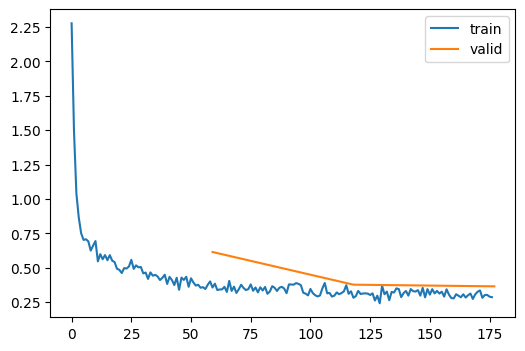

In [ ]:
# Train with BatchNorm
# Note: We can use a higher learning rate with BatchNorm!
model = get_model(act_gr, norm=BatchNorm).apply(iw)
set_seed(42)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.4, cbs=cbs)  # lr=0.4 instead of 0.2
learn.fit(3)

# Where does `nf` come from? Clarifying how BatchNorm gets its channel count

**The confusion:** In `BatchNorm.__init__(self, nf, ...)`, we use `nf` to size every per-channel parameter (`self.mults`, `self.adds`, `self.means`, `self.vars`). But we never pass `nf` ourselves — so when we run the training line below, what is `nf` and how does it get assigned?

```python
model = get_model(act_gr, norm=BatchNorm).apply(iw)
```

This note traces exactly how `nf` reaches `__init__` after this line executes.

---

## Short answer

`nf` is the **number of output channels** of the conv layer that each BatchNorm is attached to. You never set it directly — `get_model` supplies it, one value per layer, when it builds the network.

## The chain of how it gets there

**1. Running `get_model(act_gr, norm=BatchNorm)` builds a stack of conv blocks.**
When we execute:

```python
model = get_model(act_gr, norm=BatchNorm).apply(iw)
```

`get_model` constructs a sequence of convolutional blocks. Each block has a fixed number of output channels, following a progression like:

```
1 → 8 → 16 → 32 → 64 → ...
```

**2. Each block calls the `conv(...)` helper, passing along `norm=BatchNorm`.**
The `conv` helper looks roughly like this:

```python
def conv(ni, nf, ks=3, stride=2, act=..., norm=None):
    layers = [nn.Conv2d(ni, nf, ks, stride=stride, padding=ks//2)]
    if norm: layers.append(norm(nf))   # ← nf is handed to BatchNorm here
    if act:  layers.append(act())
    return nn.Sequential(*layers)
```

**3. `norm(nf)` becomes `BatchNorm(nf)` — this happens as a consequence of the line above.**
Because we passed `norm=BatchNorm` into `get_model` (which forwards it to `conv`), the line `norm(nf)` becomes `BatchNorm(nf)`. So the moment `model = get_model(act_gr, norm=BatchNorm).apply(iw)` runs, one `BatchNorm(nf)` is created for every conv block, and **`nf` is whatever output-channel count that particular conv produces.**

## So `nf` is assigned per layer

| Conv block outputs | BatchNorm created as | Value of `nf` |
|--------------------|----------------------|---------------|
| 8 channels         | `BatchNorm(8)`       | 8             |
| 16 channels        | `BatchNorm(16)`      | 16            |
| 32 channels        | `BatchNorm(32)`      | 32            |
| 64 channels        | `BatchNorm(64)`      | 64            |

Each BatchNorm instance gets its own `nf`, matching the channels of the conv immediately before it.

## Why it must match the channel count

BatchNorm keeps **one scale, one shift, one running mean, and one running variance per channel**. That's why `self.mults`, `self.adds`, `self.means`, and `self.vars` are all sized `nf` along the channel axis — there has to be exactly one of each per channel coming out of that conv.

## Bottom line

You never assign `nf` yourself. When `model = get_model(act_gr, norm=BatchNorm).apply(iw)` executes, `get_model` defines the channel counts for the network, passes each one into `conv`, and `conv` forwards it as `BatchNorm(nf)`. By the time `__init__` runs, `nf` is simply the output-channel count of the conv layer that BatchNorm normalizes.

In [ ]:
"""
================================================================================
BATCH NORMALIZATION — Fully Commented Code
================================================================================

WHAT PROBLEM DOES BATCHNORM SOLVE?

    During training, as the weights in earlier layers keep changing, the
    distribution of inputs to later layers shifts constantly. Layer 3
    might receive inputs with mean=2.5 one batch, then mean=-0.8 the
    next. This moving target (called "internal covariate shift") forces
    the network to constantly re-adapt, slowing training and requiring
    small learning rates.

    BatchNorm fixes this by normalizing activations DURING every forward
    pass — not just once at initialization. After the Conv2d produces
    its output, BatchNorm forces each channel to have mean ≈ 0 and
    std ≈ 1 before passing it to the activation function.

HOW DOES BATCHNORM NORMALIZE?

    BatchNorm normalizes PER CHANNEL, ACROSS THE ENTIRE BATCH.

    For each channel (e.g., the "edge detector" channel), it gathers
    ALL values from ALL images in the batch and ALL spatial positions,
    computes one mean and one variance from those values, and uses them
    to normalize every value in that channel.

    Concretely, if the data has shape (1024, 8, 14, 14):
      - For channel 0: average all 1024 × 14 × 14 = 200,704 values → one mean
      - For channel 1: average all 200,704 values → a different mean
      - ... one mean per channel, 8 means total

HOW IS THIS DIFFERENT FROM LAYERNORM?

    LayerNorm normalizes PER IMAGE, ACROSS ALL CHANNELS.
    It computes mean across dims (1,2,3) → one mean per image.

    BatchNorm normalizes PER CHANNEL, ACROSS THE WHOLE BATCH.
    It computes mean across dims (0,2,3) → one mean per channel.

    Additionally, BatchNorm:
      - Has per-channel learnable parameters (vectors, not scalars)
      - Maintains running statistics for use during inference
      - Behaves differently during training vs evaluation

REFERENCE:
    "Batch Normalization: Accelerating Deep Network Training by Reducing
    Internal Covariate Shift" — Ioffe & Szegedy (2015)
    https://arxiv.org/abs/1502.03167
================================================================================
"""

import torch                     # PyTorch deep learning framework
import torch.nn as nn            # Neural network building blocks
from torch import tensor         # Shortcut to create tensors


# ==============================================================================
# THE BATCHNORM CLASS
# ==============================================================================

class BatchNorm(nn.Module):
    # ──────────────────────────────────────────────────────────────────────
    # Inherits from nn.Module, which is the base class for all PyTorch
    # layers. This gives us:
    #   - Automatic parameter tracking (nn.Parameter objects)
    #   - Buffer registration (register_buffer)
    #   - Training/eval mode switching (.training attribute)
    #   - Integration with model.apply(), model.to(device), etc.
    # ──────────────────────────────────────────────────────────────────────

    def __init__(self, nf, mom=0.1, eps=1e-5):
        # ──────────────────────────────────────────────────────────────────
        # Constructor — called ONCE when the layer is created during model
        # building. For example: BatchNorm(8) creates a BatchNorm layer
        # for 8 channels.
        #
        # Parameters:
        # -----------
        # nf : int
        #     Number of features (channels). This is the number of output
        #     channels from the preceding Conv2d layer. For example, if
        #     the previous layer is Conv2d(1, 8, ...), then nf = 8.
        #
        #     Unlike LayerNorm (which ignores this as a dummy), BatchNorm
        #     ACTUALLY USES nf to create per-channel parameters and
        #     running statistics. Each channel gets its own scale, shift,
        #     running mean, and running variance.
        #
        # mom : float (default 0.1)
        #     Momentum for the exponential moving average update of the
        #     running statistics. Controls how fast the running statistics
        #     adapt to new batches:
        #       - mom = 0.1 (default): 90% old history + 10% new batch
        #         → slow, stable updates (good default)
        #       - mom = 0.5: 50% old + 50% new → fast adaptation
        #       - mom = 0.01: 99% old + 1% new → very slow, very stable
        #
        #     NOTE: PyTorch's convention for momentum is the OPPOSITE of
        #     what you might expect from physics or other frameworks.
        #     In PyTorch: new = (1 - mom) × old + mom × current
        #     In some other frameworks: new = mom × old + (1 - mom) × current
        #     The comment "NB: pytorch bn mom is opposite of what you'd
        #     expect" in the original code refers to this.
        #
        # eps : float (default 1e-5 = 0.00001)
        #     Tiny constant added to the variance before taking its square
        #     root, to prevent division by zero. If all values in a channel
        #     were identical, the variance would be 0, and dividing by
        #     sqrt(0) = 0 would crash. Adding eps avoids this.
        # ──────────────────────────────────────────────────────────────────

        super().__init__()
        # ──────────────────────────────────────────────────────────────────
        # Calls nn.Module.__init__(), which sets up PyTorch's internal
        # bookkeeping: parameter registries, buffer registries, hooks,
        # training mode flag, etc. MUST be called before creating any
        # nn.Parameter or calling register_buffer.
        # ──────────────────────────────────────────────────────────────────

        # NB: pytorch bn mom is opposite of what you'd expect
        self.mom, self.eps = mom, eps
        # ──────────────────────────────────────────────────────────────────
        # Stores mom and eps as instance attributes so they can be used
        # later in update_stats() and forward().
        #
        # This is a compact way to write two assignments on one line:
        #   self.mom = mom
        #   self.eps = eps
        # Python allows this via tuple unpacking:
        #   (self.mom, self.eps) = (mom, eps)
        # ──────────────────────────────────────────────────────────────────

        self.mults = nn.Parameter(torch.ones(nf, 1, 1))
        # ──────────────────────────────────────────────────────────────────
        # Learnable SCALE parameter (called "gamma" in the BatchNorm paper).
        #
        # Shape: (nf, 1, 1)
        #   - nf values: one scale factor per channel
        #   - The two extra 1s are for broadcasting with tensors of shape
        #     (batch, nf, height, width). When we multiply x * self.mults,
        #     PyTorch broadcasts (nf, 1, 1) to match (batch, nf, H, W):
        #     each channel gets multiplied by its own scale factor, and
        #     that factor is applied to every image and every spatial position.
        #
        # Initialized to all 1s (torch.ones): at the start of training,
        # multiplying by 1 does nothing — the output is purely normalized.
        # As training progresses, the optimizer adjusts these values so
        # each channel can learn its own preferred output scale.
        #
        # nn.Parameter() wraps the tensor and tells PyTorch: "This is a
        # learnable parameter. Include it in model.parameters(), compute
        # gradients for it during backpropagation, and let the optimizer
        # update it."
        #
        # CONTRAST WITH LAYERNORM: LayerNorm has a single scalar mult
        # (one number for ALL channels). BatchNorm has one per channel
        # because each channel represents a different feature detector
        # that may need a different output scale.
        # ──────────────────────────────────────────────────────────────────

        self.adds = nn.Parameter(torch.zeros(nf, 1, 1))
        # ──────────────────────────────────────────────────────────────────
        # Learnable SHIFT parameter (called "beta" in the BatchNorm paper).
        #
        # Shape: (nf, 1, 1) — one shift value per channel, same broadcasting
        # logic as self.mults.
        #
        # Initialized to all 0s (torch.zeros): adding 0 does nothing at
        # the start. The optimizer adjusts these during training.
        #
        # This parameter serves the same role as a bias in the Conv2d
        # layer. That is why, when using BatchNorm, the Conv2d's bias is
        # often removed — having both would be redundant (two additive
        # constants that the optimizer would combine into one effective
        # shift anyway).
        # ──────────────────────────────────────────────────────────────────

        self.register_buffer('vars', torch.ones(1, nf, 1, 1))
        # ──────────────────────────────────────────────────────────────────
        # RUNNING VARIANCE — a buffer, NOT a learnable parameter.
        #
        # register_buffer() takes TWO arguments:
        #   1. A STRING NAME:  'vars'
        #   2. A TENSOR VALUE: torch.ones(1, nf, 1, 1)
        #
        # THE STRING 'vars' — WHAT DOES IT DO?
        #
        # The string 'vars' is the ATTRIBUTE NAME that PyTorch will use
        # to attach this tensor to the module. It works exactly like
        # giving a variable a name. After this line executes, you can
        # access the tensor as:
        #
        #   self.vars    ← this now exists and holds torch.ones(1, nf, 1, 1)
        #
        # It is as if PyTorch internally does:
        #   self.vars = torch.ones(1, nf, 1, 1)
        #
        # BUT with extra bookkeeping that a plain assignment would not do.
        # If you just wrote self.vars = torch.ones(1, nf, 1, 1) without
        # register_buffer, the tensor would exist but PyTorch would NOT
        # know about it — it would not be saved with model.state_dict(),
        # would not be moved to GPU with model.to(device), etc.
        #
        # So register_buffer('vars', ...) does TWO things:
        #   1. Creates self.vars as an attribute (just like self.vars = ...)
        #   2. REGISTERS it with PyTorch's internal tracking system
        #
        # WHERE IS self.vars ACTUALLY USED?
        #
        # It is used in TWO places in this class:
        #
        #   (a) In update_stats(), it is UPDATED:
        #       self.vars.lerp_(v, self.mom)
        #       → The running variance is blended with the current batch's
        #         variance using exponential moving average.
        #
        #   (b) In forward(), during INFERENCE, it is READ:
        #       else: m, v = self.means, self.vars
        #       → When self.training is False, the running variance stored
        #         in self.vars is used for normalization instead of
        #         computing fresh statistics from the current batch.
        #
        # You could have chosen any name — 'running_var', 'var_buffer',
        # 'banana' — as long as you use the same name everywhere you
        # reference it. The name 'vars' was chosen because it is short
        # and descriptive: it stores the running variances.
        #
        # WHAT register_buffer GIVES US (that plain assignment does not):
        #   - It IS saved/loaded with model.state_dict() (persists to disk)
        #   - It IS moved to GPU/CPU when you call model.to(device)
        #   - It is NOT returned by model.parameters()
        #   - It is NOT updated by the optimizer
        #   - It has NO gradients computed for it
        #
        # TENSOR SHAPE: (1, nf, 1, 1)
        #   - 1 in the batch dimension: same running variance for all images
        #   - nf in the channel dimension: one variance per channel
        #   - 1, 1 in height and width: same variance for all positions
        #   - This shape broadcasts cleanly with (batch, nf, H, W)
        #
        # Initialized to all 1s: assumes unit variance before any training.
        #
        # We update running statistics manually inside update_stats()
        # using an exponential moving average, not via backpropagation.
        # That is why they are buffers, not parameters.
        #
        # WHY DOES BATCHNORM NEED RUNNING STATISTICS?
        # During training, BatchNorm normalizes using the current batch's
        # statistics (mean and variance of the current 1024 images).
        # During inference, you might process just 1 image at a time.
        # The statistics of a single image would be meaningless noise.
        # So BatchNorm accumulates a smoothed average of statistics seen
        # during training (the "running" statistics), and uses those
        # during inference instead.
        #
        # LayerNorm does not need running statistics because it normalizes
        # each image independently — it works the same whether there are
        # 1024 images or just 1 in the batch.
        # ──────────────────────────────────────────────────────────────────

        self.register_buffer('means', torch.zeros(1, nf, 1, 1))
        # ──────────────────────────────────────────────────────────────────
        # RUNNING MEAN — same mechanism as running variance above.
        #
        # register_buffer('means', ...) does two things:
        #   1. Creates self.means as an attribute on this module,
        #      holding the tensor torch.zeros(1, nf, 1, 1)
        #   2. Registers it with PyTorch so it is saved/loaded and
        #      moved to the correct device, but NOT treated as a
        #      learnable parameter
        #
        # The string 'means' becomes the attribute name. After this line:
        #   self.means   ← exists, holds torch.zeros(1, nf, 1, 1)
        #
        # WHERE IS self.means ACTUALLY USED?
        #
        #   (a) In update_stats(), it is UPDATED:
        #       self.means.lerp_(m, self.mom)
        #       → Blended with the current batch's mean.
        #
        #   (b) In forward(), during INFERENCE, it is READ:
        #       else: m, v = self.means, self.vars
        #       → Used for normalization when self.training is False.
        #
        # So 'vars' and 'means' are the names we chose for the two
        # running statistics. They appear in three places each:
        #   - Here in __init__:    register_buffer('means', ...)  ← CREATED
        #   - In update_stats:     self.means.lerp_(m, ...)       ← UPDATED
        #   - In forward (else):   m, v = self.means, self.vars   ← READ
        #
        # The string name connects all three usages. If we had written
        # register_buffer('running_mean', ...) instead, then we would
        # access it as self.running_mean everywhere.
        #
        # Shape: (1, nf, 1, 1) — one mean per channel.
        # Initialized to all 0s: assumes zero mean before any training.
        # ──────────────────────────────────────────────────────────────────

    def update_stats(self, x):
        # ──────────────────────────────────────────────────────────────────
        # Called during training to:
        #   1. Compute the current batch's per-channel mean and variance
        #   2. Update the running statistics with these new values
        #   3. Return the batch statistics for use in normalization
        #
        # This method has NO equivalent in LayerNorm, because LayerNorm
        # does not maintain running statistics.
        #
        # Parameters:
        # -----------
        # x : Tensor of shape (batch, channels, height, width)
        #     The input data flowing through this layer. For example,
        #     (1024, 8, 14, 14) for 1024 images with 8 channels, 14×14.
        #
        # Returns:
        # --------
        # (m, v) : tuple of Tensors, each shape (1, nf, 1, 1)
        #     The current batch's mean and variance per channel.
        # ──────────────────────────────────────────────────────────────────

        m = x.mean((0, 2, 3), keepdim=True)
        # ──────────────────────────────────────────────────────────────────
        # Compute the mean for EACH CHANNEL, averaging across:
        #   - Dimension 0: ALL images in the batch
        #   - Dimension 2: ALL height positions
        #   - Dimension 3: ALL width positions
        #
        # Dimension 1 (channels) is NOT included, so each channel gets
        # its own separate mean.
        #
        # For input shape (1024, 8, 14, 14):
        #   - Channel 0: averages 1024 × 14 × 14 = 200,704 values → 1 number
        #   - Channel 1: averages 200,704 values → 1 number
        #   - ... 8 channels total → 8 means
        #
        # keepdim=True preserves the 4D shape: result is (1, 8, 1, 1)
        # instead of (8,). The 1s ensure correct broadcasting when we
        # later subtract m from x of shape (1024, 8, 14, 14): each
        # channel's mean is subtracted from all images and all positions
        # in that channel.
        #
        # THIS IS THE CORE DIFFERENCE FROM LAYERNORM:
        #   LayerNorm:  x.mean((1, 2, 3)) → one mean per IMAGE
        #   BatchNorm:  x.mean((0, 2, 3)) → one mean per CHANNEL
        # The dimension lists differ by just one number (dim 0 vs dim 1),
        # but this changes the entire normalization behavior.
        # ──────────────────────────────────────────────────────────────────

        v = x.var((0, 2, 3), keepdim=True)
        # ──────────────────────────────────────────────────────────────────
        # Compute the variance for each channel, across the same dimensions
        # as the mean. Result shape: (1, 8, 1, 1) — one variance per channel.
        #
        # Variance measures how spread out the values are. If all 200,704
        # values in a channel are nearly identical, variance is close to 0.
        # If they are widely spread, variance is large.
        # ──────────────────────────────────────────────────────────────────

        self.means.lerp_(m, self.mom)
        # ──────────────────────────────────────────────────────────────────
        # Update the RUNNING MEAN using exponential moving average.
        #
        # lerp_ stands for "linear interpolation, in-place."
        # The underscore suffix _ means it modifies self.means directly
        # (in-place) rather than creating a new tensor.
        #
        # lerp_ takes TWO arguments: lerp_(target, weight)
        #
        # In our call:  self.means.lerp_(m, self.mom)
        #   - self.means = the tensor the method is called on (the running mean)
        #   - m          = the TARGET — this is the variable `m` computed
        #                  two lines above: m = x.mean((0, 2, 3), keepdim=True)
        #                  It holds the CURRENT BATCH's per-channel mean.
        #                  Shape: (1, nf, 1, 1)
        #   - self.mom   = the WEIGHT (0.1) — how much to move toward the target
        #
        # The formula lerp_(target, weight) computes:
        #   self.means = self.means + weight × (target - self.means)
        #
        # Substituting our actual values:
        #   self.means = self.means + self.mom × (m - self.means)
        #   self.means = self.means + 0.1 × (m - self.means)
        #
        # Which is mathematically equivalent to:
        #   self.means = (1 - self.mom) × self.means + self.mom × m
        #   self.means = 0.9 × self.means + 0.1 × m
        #
        # In plain English: "Move self.means 10% of the way toward m."
        # Or equivalently: "Keep 90% of the old running mean, and blend
        # in 10% of the new batch's mean."
        #
        # Concrete example for channel 0:
        #   Suppose self.means for channel 0 is currently 0.48,
        #   and the current batch's channel 0 mean (m) is 2.5.
        #
        #   self.means = 0.48 + 0.1 × (2.5 - 0.48)
        #              = 0.48 + 0.1 × 2.02
        #              = 0.48 + 0.202
        #              = 0.682
        #
        #   The running mean moved from 0.48 a little bit toward 2.5,
        #   landing at 0.682. It did NOT jump all the way to 2.5 —
        #   it moved only 10% of the distance.
        #
        # Over many batches, this produces a smoothed average that:
        #   - Emphasizes recent batches (which reflect the model's current
        #     state) more than old batches (from early, poor-quality training)
        #   - Is stable (resistant to outlier batches)
        #   - Converges toward the "true" population mean
        #
        # Full trace for channel 0 (starting from self.means = 0):
        #   Batch 1: m = 2.0 → running = 0.9×0.0 + 0.1×2.0 = 0.20
        #   Batch 2: m = 3.0 → running = 0.9×0.2 + 0.1×3.0 = 0.48
        #   Batch 3: m = 2.5 → running = 0.9×0.48 + 0.1×2.5 = 0.682
        #   ... gradually approaches the typical batch mean
        #
        # IMPORTANT: self.means AND m ARE NOT THE SAME THING.
        #
        # They are both "means," but they represent very different things:
        #
        # m = x.mean((0, 2, 3), keepdim=True)
        #   → The mean of THIS SPECIFIC BATCH of ~1024 images passing
        #     through the network RIGHT NOW. It is freshly calculated
        #     every time a new batch arrives. If the next batch has
        #     different images, m will be a different number. It is a
        #     SNAPSHOT — the mean of whatever data is in front of the
        #     network at this moment.
        #
        # self.means
        #   → The RUNNING MEAN — a smoothed, accumulated average built
        #     up across ALL BATCHES seen so far during training. It
        #     started at 0 (initialized with torch.zeros) and gets
        #     nudged a little toward each batch's m. After 1000 batches,
        #     self.means reflects a blend of all 1000 batch means, with
        #     recent batches weighted more heavily.
        #
        # Analogy: tracking the temperature in your city.
        #   m          = today's temperature (changes every day: 72, 68, 75...)
        #   self.means = your running estimate of the "typical" temperature,
        #                built up over weeks and months, settling around ~70
        #
        # They would only be equal if self.mom were 1.0 (meaning "throw
        # away all history and just use the current batch"). With
        # self.mom = 0.1, the running mean changes slowly and lags
        # behind the individual batch means.
        #
        # Notice in the trace above: at Batch 3, m = 2.5 but
        # self.means = 0.682. They are quite different numbers.
        # m reflects only the current batch; self.means reflects the
        # entire training history.
        # ──────────────────────────────────────────────────────────────────

        self.vars.lerp_(v, self.mom)
        # ──────────────────────────────────────────────────────────────────
        # Update the RUNNING VARIANCE using the same exponential moving
        # average formula.
        #
        # In our call:  self.vars.lerp_(v, self.mom)
        #   - self.vars = the tensor the method is called on (running variance)
        #   - v         = the TARGET — the variable `v` computed above:
        #                 v = x.var((0, 2, 3), keepdim=True)
        #                 It holds the CURRENT BATCH's per-channel variance.
        #   - self.mom  = the WEIGHT (0.1)
        #
        # The formula:
        #   self.vars = self.vars + 0.1 × (v - self.vars)
        #             = 0.9 × self.vars + 0.1 × v
        #
        # Same logic as the running mean: gradually tracks the typical
        # per-channel variance seen during training, moving 10% of the
        # way toward each new batch's variance.
        # ──────────────────────────────────────────────────────────────────

        return m, v
        # ──────────────────────────────────────────────────────────────────
        # Returns the CURRENT BATCH's mean and variance (NOT the running
        # statistics). During training, BatchNorm normalizes using these
        # fresh per-batch statistics, not the running ones.
        #
        # So update_stats actually does TWO separate jobs:
        #
        #   Job 1 (returned): Compute m and v from the current batch.
        #     These are returned to forward(), which uses them for
        #     normalization RIGHT NOW during this training step.
        #
        #   Job 2 (side effect): Update self.means and self.vars via
        #     lerp_. These are NOT returned. They are NOT used during
        #     training at all. They are quietly accumulated so that
        #     they are ready for INFERENCE later, when there is no
        #     full batch to compute statistics from.
        #
        # The two jobs are independent. Job 1 answers "what do we
        # normalize with right now?" Job 2 answers "what will we
        # normalize with during inference someday?"
        # ──────────────────────────────────────────────────────────────────

    def forward(self, x):
        # ──────────────────────────────────────────────────────────────────
        # Called automatically by PyTorch every time data flows through
        # this layer. x is the output of the preceding Conv2d, with shape
        # (batch, channels, height, width).
        #
        # BatchNorm behaves DIFFERENTLY during training vs inference:
        #   - Training: compute fresh statistics from the current batch,
        #     and also update the running statistics.
        #   - Inference: use the accumulated running statistics.
        # ──────────────────────────────────────────────────────────────────

        if self.training:
            # ──────────────────────────────────────────────────────────────
            # self.training is a boolean attribute that every nn.Module has.
            # It is True by default, and switched by model.train() (True)
            # or model.eval() (False).
            #
            # During training, we compute statistics from the current batch
            # because: (a) we have a full batch of images, so the statistics
            # are reliable; and (b) using per-batch statistics introduces a
            # small amount of noise (each batch has slightly different stats),
            # which acts as a regularizer (similar to dropout), helping to
            # prevent overfitting.
            # ──────────────────────────────────────────────────────────────

            with torch.no_grad():
                m, v = self.update_stats(x)
            # ──────────────────────────────────────────────────────────────
            # torch.no_grad() disables gradient tracking for everything
            # inside the block. This is important because:
            #
            # 1. The running statistics updates (lerp_ calls inside
            #    update_stats) are bookkeeping, not part of the
            #    mathematical computation that gradients should flow
            #    through. We do not want the optimizer to "optimize"
            #    the running statistics — they are updated by the
            #    exponential moving average formula, not by backpropagation.
            #
            # 2. The batch mean m and variance v returned here will be
            #    used in the normalization formula below. Because they
            #    were computed inside no_grad(), they are treated as
            #    constants (not tracked in the computation graph). But
            #    x itself IS still tracked, so gradients can flow through
            #    the normalization formula (x - m) / sqrt(v + eps) with
            #    respect to x, which is what we want.
            #
            # Without no_grad(), the lerp_ operations would be recorded
            # in the computation graph, wasting memory and potentially
            # causing incorrect gradient computations.
            #
            # WHY BOTHER UPDATING self.means AND self.vars HERE?
            #
            # You might wonder: "update_stats returns m and v (the fresh
            # batch statistics), and those are what we use for normalization
            # below. So what is the point of also updating self.means and
            # self.vars inside update_stats? They are not used here at all!"
            #
            # The answer: self.means and self.vars are NOT used during
            # training. They are being SAVED FOR LATER — specifically,
            # for inference (the `else` branch below).
            #
            # During training, we have a full batch of 1024 images, so we
            # can compute reliable statistics (m, v) on the spot. But
            # during inference, we might process just 1 image. We cannot
            # compute meaningful batch statistics from 1 image. So the
            # `else` branch uses self.means and self.vars instead.
            #
            # If we never updated self.means and self.vars during training,
            # they would remain at their initial values (means=0, vars=1)
            # forever, and inference would use completely wrong statistics.
            #
            # Think of it like a student taking notes during lectures
            # (training) so they can use those notes during the exam
            # (inference). The notes don't help with the current lecture
            # — the student is listening live. But without the notes,
            # the exam would be impossible.
            #
            # Summary of what update_stats does (two separate jobs):
            #   Job 1: Compute m, v from current batch → RETURNED and
            #          used for normalization RIGHT NOW (during training)
            #   Job 2: Update self.means, self.vars → NOT returned, NOT
            #          used now, but SAVED for future inference
            # ──────────────────────────────────────────────────────────────

        else:
            m, v = self.means, self.vars
            # ──────────────────────────────────────────────────────────────
            # During INFERENCE (model.eval()):
            # Use the running statistics accumulated during training.
            #
            # Why not compute from the current batch?
            # During inference, you might have batch size = 1 (a single
            # image). The mean and variance of a single image are
            # meaningless noise — they tell you about that one image's
            # values, not about the general distribution the channel
            # should have. The running statistics, accumulated over
            # thousands of training batches, are a much more reliable
            # estimate of the true population statistics.
            #
            # This also makes inference DETERMINISTIC: the same input
            # always produces the same output, regardless of what other
            # images are in the batch.
            #
            # CONTRAST WITH LAYERNORM: LayerNorm always computes fresh
            # statistics from the current input, because it normalizes
            # per image (not per batch). A single image provides enough
            # data for per-image statistics. LayerNorm has no training
            # vs inference distinction.
            # ──────────────────────────────────────────────────────────────

        x = (x - m) / (v + self.eps).sqrt()
        # ──────────────────────────────────────────────────────────────────
        # THE NORMALIZATION FORMULA — same structure as LayerNorm.
        #
        # Step by step:
        #   1. (x - m): Subtract the mean from every value.
        #      x shape:  (1024, 8, 14, 14)
        #      m shape:  (1, 8, 1, 1)
        #      Broadcasting: each channel's mean is subtracted from all
        #      images and all spatial positions in that channel.
        #      Result: values are now centered around 0 for each channel.
        #
        #   2. (v + self.eps): Add tiny epsilon to variance to avoid
        #      dividing by zero. eps = 0.00001 is negligible for normal
        #      variances but saves us if variance is exactly 0.
        #
        #   3. .sqrt(): Take the square root of (variance + eps), giving
        #      us the standard deviation.
        #      v shape: (1, 8, 1, 1) → sqrt shape: (1, 8, 1, 1)
        #
        #   4. / : Divide the centered values by the standard deviation.
        #      Broadcasting: each channel is divided by its own std.
        #      Result: each channel now has approximately mean = 0 and
        #      std = 1.
        #
        # After this line, the activations are normalized. But pure
        # normalization might be too restrictive — the network might
        # work better with a slightly different distribution. That is
        # what the next line handles.
        # ──────────────────────────────────────────────────────────────────

        return x * self.mults + self.adds
        # ──────────────────────────────────────────────────────────────────
        # SCALE AND SHIFT with learnable per-channel parameters.
        #
        # x * self.mults:
        #   x shape:      (1024, 8, 14, 14)
        #   mults shape:  (8, 1, 1)
        #   Broadcasting: each channel is multiplied by its own learned
        #   scale factor. Channel 0 might learn scale = 1.3, channel 1
        #   might learn scale = 0.7, etc.
        #
        # + self.adds:
        #   adds shape:   (8, 1, 1)
        #   Broadcasting: each channel gets its own learned shift added.
        #
        # At the start of training, mults = all 1s and adds = all 0s,
        # so this line does nothing and the output is purely normalized.
        # As training progresses, the optimizer adjusts these to learn
        # the best output distribution for each channel.
        #
        # In the extreme, the network COULD learn mults and adds that
        # completely undo the normalization — but in practice, the
        # normalization provides a much better starting point, and the
        # learned adjustments are modest.
        #
        # CONTRAST WITH LAYERNORM:
        #   LayerNorm:  x * self.mult + self.add   (scalar × scalar)
        #               → same scale/shift for ALL channels
        #   BatchNorm:  x * self.mults + self.adds  (vector × vector)
        #               → different scale/shift for EACH channel
        # ──────────────────────────────────────────────────────────────────


# ==============================================================================
# TRAINING WITH BATCHNORM
# ==============================================================================

# ──────────────────────────────────────────────────────────────────────────────
# model = get_model(act_gr, norm=BatchNorm).apply(iw)
# ──────────────────────────────────────────────────────────────────────────────
#
# get_model(act_gr, norm=BatchNorm):
#   Builds the CNN model. Inside get_model, each block is created via:
#     conv(nfs[i], nfs[i+1], act=act_gr, norm=BatchNorm)
#
#   Inside conv(), when norm=BatchNorm:
#     - layers.append(norm(nf)) becomes layers.append(BatchNorm(nf))
#     - BatchNorm(nf) calls __init__(self, nf=8) for Block 0
#     - Unlike LayerNorm (which ignores nf), BatchNorm USES nf to create:
#         mults: shape (8, 1, 1)   — 8 learnable scales
#         adds:  shape (8, 1, 1)   — 8 learnable shifts
#         vars:  shape (1, 8, 1, 1) — 8 running variances
#         means: shape (1, 8, 1, 1) — 8 running means
#
#   The resulting model structure:
#     Sequential(
#       Sequential(Conv2d(1,8), BatchNorm(8), GeneralRelu)     ← Block 0
#       Sequential(Conv2d(8,16), BatchNorm(16), GeneralRelu)   ← Block 1
#       Sequential(Conv2d(16,32), BatchNorm(32), GeneralRelu)  ← Block 2
#       Sequential(Conv2d(32,64), BatchNorm(64), GeneralRelu)  ← Block 3
#       Conv2d(64,10)                                           ← Final
#       Flatten
#     )
#
# .apply(iw):
#   Walks through every module in the model and applies the init_weights
#   function (with leaky=0.1) to every Conv2d layer. This sets up
#   Kaiming-initialized weights as a starting point. BatchNorm will then
#   keep activations normalized throughout training, even as weights change.
#
# ──────────────────────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────────────────────
# set_seed(42)
# ──────────────────────────────────────────────────────────────────────────────
#
# Sets the random seed to 42 for reproducibility. This ensures that the
# random number generators (used for data shuffling, dropout, etc.) produce
# the same sequence every time, so the training results are reproducible.
#
# ──────────────────────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────────────────────
# learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.4, cbs=cbs)
# ──────────────────────────────────────────────────────────────────────────────
#
# Creates a learner (training loop manager) with:
#   - model: our BatchNorm-equipped CNN
#   - dls: the DataLoaders (training and validation data)
#   - F.cross_entropy: the loss function for classification
#   - lr=0.4: the learning rate
#   - cbs=cbs: callbacks for device management, progress display, etc.
#
# IMPORTANT: The learning rate is 0.4, which is DOUBLE the lr=0.2 used
# with LayerNorm. This is one of the major practical benefits of BatchNorm:
# it smooths the loss landscape (the "terrain" that the optimizer navigates).
# A smoother landscape means the optimizer can take bigger steps (higher
# learning rate) without overshooting. Bigger steps = faster training.
#
# This is arguably the most important reason BatchNorm is so widely used
# in practice — not just the normalization itself, but the ability to
# train much faster with higher learning rates.
#
# ──────────────────────────────────────────────────────────────────────────────

# ──────────────────────────────────────────────────────────────────────────────
# learn.fit(3)
# ──────────────────────────────────────────────────────────────────────────────
#
# Trains the model for 3 epochs (3 complete passes through the training data).
#
# During each forward pass of each batch:
#   1. Data flows through Conv2d → BatchNorm → GeneralRelu for each block.
#   2. Inside BatchNorm.forward():
#      - self.training is True → enters the "if self.training" branch
#      - update_stats(x) computes per-channel mean and variance from the
#        current batch, updates the running statistics, and returns the
#        batch statistics
#      - Normalization: (x - m) / sqrt(v + eps)
#      - Scale and shift: x * mults + adds
#   3. The loss is computed, gradients are backpropagated.
#   4. The optimizer updates:
#      - Conv2d weights and biases
#      - BatchNorm's mults and adds (the learnable parameters)
#      - But NOT BatchNorm's means and vars (the running buffers —
#        these were already updated inside update_stats via lerp_)
#
# After training, if you called model.eval() and ran inference:
#   - self.training would be False
#   - BatchNorm would use self.means and self.vars (the accumulated
#     running statistics) instead of computing fresh batch statistics
#   - The output would be deterministic
#
# ──────────────────────────────────────────────────────────────────────────────

### Understanding BatchNorm and How It Differs from LayerNorm

---

### What Is the Motivation Behind BatchNorm?

BatchNorm solves the same fundamental problem as LayerNorm: keeping activations at a healthy magnitude throughout training. But it approaches the problem from a completely different angle.

Recall the core idea: we want each layer's output to have mean ≈ 0 and std ≈ 1, not just at initialization, but **continuously** during training. As weights update, the distribution of each layer's output drifts. The next layer has to constantly adapt to a moving target. This slows training down and forces us to use small learning rates.

Both LayerNorm and BatchNorm fix this by normalizing activations during every forward pass. The critical difference is **what they normalize across**:

- **LayerNorm** asks: "For this one image, what is the mean and variance across all its channels and spatial positions?" Each image is normalized independently. Image #0's statistics have no effect on image #1.

- **BatchNorm** asks: "For this one channel, what is the mean and variance across all images in the batch and all spatial positions?" Each channel is normalized independently. Channel #0's statistics have no effect on channel #1.

This is a fundamentally different perspective. Here is a concrete example to make it vivid.

Imagine a batch of 4 images flowing through a layer that has 3 channels. Each channel produces a small 2×2 feature map. The data looks like this:

```
          Channel 0      Channel 1      Channel 2
Image 0:  [2, 4]         [1, 3]         [5, 7]
          [6, 8]         [5, 7]         [9, 11]

Image 1:  [1, 3]         [2, 4]         [4, 6]
          [5, 7]         [6, 8]         [8, 10]

Image 2:  [3, 5]         [0, 2]         [6, 8]
          [7, 9]         [4, 6]         [10, 12]

Image 3:  [0, 2]         [3, 5]         [3, 5]
          [4, 6]         [7, 9]         [7, 9]
```

**LayerNorm** computes one mean per image. For Image 0, it averages ALL 12 values (across all 3 channels and all 2×2 positions): `(2+4+6+8+1+3+5+7+5+7+9+11) / 12 = 5.67`. It then normalizes all 12 values in Image 0 using that single mean and variance.

**BatchNorm** computes one mean per channel. For Channel 0, it averages ALL 16 values (across all 4 images and all 2×2 positions): `(2+4+6+8+1+3+5+7+3+5+7+9+0+2+4+6) / 16 = 4.5`. It then normalizes all Channel 0 values across all images using that single mean and variance. Channel 1 gets its own separate mean and variance. Channel 2 gets its own.

Why does BatchNorm normalize per channel? Because in a CNN, each channel represents a specific learned feature detector — one channel might detect edges, another might detect textures, another might detect corners. Each feature detector has its own natural scale and distribution. BatchNorm respects this by giving each channel its own normalization statistics, its own learnable scale (`mult`), and its own learnable shift (`add`).

---

### The Key Differences Between BatchNorm and LayerNorm

Before diving into the code, here are all the differences at a glance:

**What they normalize across:**
- LayerNorm: dims (1, 2, 3) — channels, height, width. One mean per image.
- BatchNorm: dims (0, 2, 3) — batch, height, width. One mean per channel.

**Learnable parameters:**
- LayerNorm: single scalar `mult` and `add` — one value shared across all channels.
- BatchNorm: vectors `mults` and `adds` with shape `(nf, 1, 1)` — one value per channel.

**Using `nf` (number of channels):**
- LayerNorm: accepts `nf` as a `dummy` argument and ignores it.
- BatchNorm: actually uses `nf` to create per-channel parameters and running statistics.

**Running statistics:**
- LayerNorm: has none. Always computes fresh statistics from the current input.
- BatchNorm: maintains `running_mean` and `running_var` that are updated during training and used during inference.

**Training vs inference behavior:**
- LayerNorm: behaves identically in both modes.
- BatchNorm: uses batch statistics during training, uses accumulated running statistics during inference.

**Bias in the preceding Conv2d:**
- With LayerNorm: Conv2d keeps its bias (because LayerNorm does not have per-channel bias).
- With BatchNorm: Conv2d's bias is typically removed (because BatchNorm's `adds` parameter serves the same purpose, making the Conv2d bias redundant).

---

### The `BatchNorm` Class — Line by Line

#### The Constructor: `__init__`

```python
class BatchNorm(nn.Module):
```

Defines BatchNorm as a PyTorch module, just like LayerNorm.

```python
    def __init__(self, nf, mom=0.1, eps=1e-5):
```

The constructor takes three arguments:

- **`nf`**: The number of features (channels). Unlike LayerNorm's `dummy` parameter, **BatchNorm actually uses this value**. It needs `nf` to create one scale parameter, one shift parameter, one running mean, and one running variance for **each** channel. If the preceding Conv2d has 8 output channels, `nf = 8`, and BatchNorm creates 8 scale values, 8 shift values, 8 running means, and 8 running variances.

- **`mom`**: Momentum for the running statistics update (default 0.1). This controls how quickly the running statistics adapt to new batches. A small value (like 0.1) means the running statistics change slowly, giving more weight to historical batches. A large value would make them track the current batch more closely. We will explain this in detail when we reach `update_stats`.

- **`eps`**: A tiny constant (0.00001) added to the variance before taking the square root, to prevent division by zero. Same purpose as in LayerNorm.

```python
        super().__init__()
        self.mom, self.eps = mom, eps
```

Calls the parent `nn.Module` constructor (required for PyTorch bookkeeping), then stores `mom` and `eps` for later use. The `self.mom, self.eps = mom, eps` line is a compact way to do two assignments at once — it is equivalent to writing `self.mom = mom` and `self.eps = eps` on separate lines.

```python
        self.mults = nn.Parameter(torch.ones(nf, 1, 1))
```

Creates the learnable scale parameter (gamma). **This is a vector, not a scalar.** Its shape is `(nf, 1, 1)` — one value for each channel, with extra dimensions of size 1 for broadcasting.

For example, if `nf = 8`, `self.mults` has shape `(8, 1, 1)`. During the forward pass, when we multiply this with a tensor of shape `(batch, 8, height, width)`, PyTorch broadcasts the `(8, 1, 1)` across the batch, height, and width dimensions. Each channel gets multiplied by its own scale factor.

Initialized to all 1s (`torch.ones`), so initially it performs no scaling.

**Contrast with LayerNorm:** LayerNorm has `self.mult = nn.Parameter(tensor(1.))` — a single scalar. The same scale factor is applied to every channel. BatchNorm has one scale factor per channel, allowing each feature detector to learn its own preferred output scale.

```python
        self.adds = nn.Parameter(torch.zeros(nf, 1, 1))
```

Creates the learnable shift parameter (beta). Shape `(nf, 1, 1)` — one value per channel. Initialized to all 0s, so initially it performs no shifting.

Same logic as `mults`: each channel gets its own shift. This is why, when using BatchNorm, the Conv2d's bias is removed — BatchNorm's `adds` serves the same purpose as a per-channel bias, and having both would be redundant.

```python
        self.register_buffer('vars', torch.ones(1, nf, 1, 1))
```

Creates a **buffer** (not a parameter) to store the running variance. Shape `(1, nf, 1, 1)` — one variance per channel.

**What is `register_buffer`?** It tells PyTorch: "This tensor is part of the module's state, but it is NOT a learnable parameter." This means:

- It is **saved** when you save the model (`state_dict`), so it persists across save/load.
- It is **moved** to the correct device when you call `model.to(device)`.
- It is **NOT** updated by the optimizer during training — the optimizer only touches `nn.Parameter` objects.
- It does **NOT** have gradients computed for it.

Running statistics are updated manually (inside `update_stats`), not by backpropagation. That is why they are buffers, not parameters.

Initialized to all 1s — the assumption is that variances start at 1 (unit variance).

**Why does LayerNorm not have running statistics?** LayerNorm normalizes each image independently using that image's own statistics. This works identically during training and inference. BatchNorm normalizes using the entire batch's statistics, but during inference you might have a single image (batch size 1). A single image's statistics would be unreliable, so BatchNorm accumulates a "running average" of statistics seen during training and uses that during inference.

```python
        self.register_buffer('means', torch.zeros(1, nf, 1, 1))
```

Creates a buffer for the running mean. Shape `(1, nf, 1, 1)` — one mean per channel. Initialized to all 0s — the assumption is that means start at 0.

**Why shape `(1, nf, 1, 1)` instead of `(nf, 1, 1)`?** The extra leading dimension of 1 (for the batch dimension) makes broadcasting work cleanly when subtracting the mean from `x` which has shape `(batch, nf, height, width)`. The shapes `(1, nf, 1, 1)` and `(batch, nf, height, width)` broadcast correctly: the single mean for each channel is applied to every image in the batch and every spatial position.

---

#### The Statistics Update: `update_stats`

This method is called during training to compute the current batch's statistics and update the running statistics. It has no equivalent in LayerNorm.

```python
    def update_stats(self, x):
```

Takes the input tensor `x` with shape `(batch, channels, height, width)`.

```python
        m = x.mean((0, 2, 3), keepdim=True)
```

Computes the mean across dimensions 0 (batch), 2 (height), and 3 (width). Dimension 1 (channels) is **not included**, so each channel gets its own mean.

For input shape `(1024, 8, 14, 14)`:
- Dimensions: 0=batch (1024 images), 1=channels (8 feature maps), 2=height (14), 3=width (14)
- Averaging across dims (0, 2, 3): for each of the 8 channels, average across all 1024 images and all 14×14 = 196 spatial positions. That is 1024 × 196 = 200,704 values averaged into one number per channel.
- `keepdim=True` gives shape `(1, 8, 1, 1)` — one mean per channel, with extra dimensions for broadcasting.

**This is the core difference from LayerNorm.** LayerNorm uses `.mean((1, 2, 3))` — averaging across channels, height, width for each image. BatchNorm uses `.mean((0, 2, 3))` — averaging across batch, height, width for each channel. The dimension lists are almost the same except for swapping dim 0 (batch) with dim 1 (channels).

```python
        v = x.var((0, 2, 3), keepdim=True)
```

Computes the variance across the same dimensions. Shape `(1, 8, 1, 1)` — one variance per channel.

```python
        self.means.lerp_(m, self.mom)
```

Updates the running mean using **linear interpolation** (`lerp_`). The underscore suffix `_` means this is an in-place operation — it modifies `self.means` directly.

`lerp_` takes two arguments: `lerp_(target, weight)`. Let us identify exactly what each argument is in our call `self.means.lerp_(m, self.mom)`:

- **`self.means`** — the tensor the method is called on. This is the running mean (the buffer we created with `register_buffer`).
- **`m`** — the **target**. This is the variable `m` computed two lines above: `m = x.mean((0, 2, 3), keepdim=True)`. It holds the **current batch's** per-channel mean. It is the value we want to move *toward*.
- **`self.mom`** — the **weight** (0.1). It controls how far we move toward the target. 0.1 means "move 10% of the way there."

The formula `lerp_(target, weight)` computes:
```
self.means = self.means + weight × (target - self.means)
```

Substituting our actual values:
```
self.means = self.means + 0.1 × (m - self.means)
```

Which is mathematically equivalent to:
```
self.means = 0.9 × self.means + 0.1 × m
```

In plain English: "Move `self.means` 10% of the way toward `m`." Or equivalently: "Keep 90% of the old running mean, and blend in 10% of the new batch's mean."

This is an **exponential moving average**. Over many batches, the running mean becomes a smoothed average of all the batch means seen during training, with recent batches having more influence than older ones.

**Why exponential moving average instead of a simple average?** A simple average gives equal weight to all batches, including those from early training when the weights were bad. The exponential moving average naturally "forgets" old batches and emphasizes recent ones, which better reflects the model's current state.

**A concrete example.** Suppose channel 0's running mean (`self.means`) is currently 0.48, and the current batch's channel 0 mean (`m`) is 2.5:

```
self.means = 0.48 + 0.1 × (2.5 - 0.48)
           = 0.48 + 0.1 × 2.02
           = 0.48 + 0.202
           = 0.682
```

The running mean moved from 0.48 a little bit toward 2.5, landing at 0.682. It did NOT jump all the way to 2.5 — it moved only 10% of the distance.

**Full trace** for channel 0, starting from `self.means = 0`:

- Batch 1: `m = 2.0` → running = 0.9 × 0.0 + 0.1 × 2.0 = **0.2**
- Batch 2: `m = 3.0` → running = 0.9 × 0.2 + 0.1 × 3.0 = **0.48**
- Batch 3: `m = 2.5` → running = 0.9 × 0.48 + 0.1 × 2.5 = **0.682**

The running mean gradually moves toward the typical batch mean, but it moves slowly (because `mom = 0.1` gives 90% weight to history).

**Important: `self.means` and `m` are NOT the same thing.** They are both "means," but they represent very different things:

- **`m`** = `x.mean((0, 2, 3), keepdim=True)` — the mean of **this specific batch** of ~1024 images passing through the network *right now*. It is freshly calculated every time a new batch arrives. If the next batch has different images, `m` will be a different number. It is a **snapshot** — the mean of whatever data is in front of the network at this moment.

- **`self.means`** — the **running mean** — a smoothed, accumulated average built up across **all batches seen so far** during training. It started at 0 (initialized with `torch.zeros`) and gets nudged a little toward each batch's `m`. After 1000 batches, `self.means` reflects a blend of all 1000 batch means, with recent batches weighted more heavily.

Think of it like tracking the temperature in your city. `m` is today's temperature reading — it changes every day (72°F, 68°F, 75°F...). `self.means` is your running estimate of the "typical" temperature, built up over weeks and months, settling around a stable value like ~70°F.

Notice in the trace above: at Batch 3, `m = 2.5` but `self.means = 0.682`. They are quite different numbers. `m` reflects only the current batch; `self.means` reflects the entire training history. They would only be equal if `self.mom` were 1.0 (meaning "throw away all history and just use the current batch"). With `self.mom = 0.1`, the running mean changes slowly and lags behind the individual batch means.

```python
        self.vars.lerp_(v, self.mom)
```

Same exponential moving average update for the running variance. Here the **target** is `v` — the variable computed above as `v = x.var((0, 2, 3), keepdim=True)`, holding the current batch's per-channel variance. The formula is:

```
self.vars = 0.9 × self.vars + 0.1 × v
```

The running variance moves 10% of the way toward the current batch's variance, same logic as the running mean.

```python
        return m, v
```

Returns the **current batch's** mean and variance (not the running statistics). The forward method uses these for normalization during training.

This reveals that `update_stats` actually does **two separate jobs**:

- **Job 1 (returned):** Compute `m` and `v` from the current batch. These are returned to `forward()`, which uses them for normalization **right now** during this training step.

- **Job 2 (side effect):** Update `self.means` and `self.vars` via `lerp_`. These are **not** returned. They are **not** used during training at all. They are quietly accumulated so that they are ready for **inference** later, when there is no full batch to compute statistics from.

The two jobs are independent. Job 1 answers "what do we normalize with right now?" Job 2 answers "what will we normalize with during inference someday?"

---

#### The Forward Pass: `forward`

```python
    def forward(self, x):
```

Called automatically by PyTorch when data flows through the BatchNorm layer. `x` is the output of the preceding Conv2d layer, with shape `(batch, channels, height, width)`.

```python
        if self.training:
```

Checks whether the model is in training mode or evaluation (inference) mode. Every `nn.Module` has a `.training` attribute that is `True` by default and can be switched by calling `model.train()` or `model.eval()`. This is the reason BatchNorm behaves differently during training and inference.

```python
            with torch.no_grad():
                m, v = self.update_stats(x)
```

**During training:** Compute the current batch's mean and variance, and also update the running statistics. The `torch.no_grad()` block tells PyTorch not to track gradients for the `update_stats` computations. This is important because:

- The running statistics update (`lerp_`) is a bookkeeping operation, not part of the mathematical computation that gradients should flow through.
- The batch mean `m` and variance `v` are used for normalization, but we want gradients to flow through the normalization formula itself (the `(x - m) / sqrt(v + eps)` line below), not through the computation of `m` and `v`. PyTorch handles this correctly because `m` and `v` are detached from the computation graph by `no_grad`, but `x` in the normalization formula below is still tracked.

**Why bother updating `self.means` and `self.vars` here?** You might wonder: "`update_stats` returns `m` and `v` (the fresh batch statistics), and those are what we use for normalization below. So what is the point of also updating `self.means` and `self.vars` inside `update_stats`? They are not used here at all!"

The answer: `self.means` and `self.vars` are **not used during training**. They are being **saved for later** — specifically, for inference (the `else` branch below). During training, we have a full batch of 1024 images, so we can compute reliable statistics (`m`, `v`) on the spot. But during inference, we might process just 1 image. We cannot compute meaningful batch statistics from 1 image. So the `else` branch uses `self.means` and `self.vars` instead.

If we never updated `self.means` and `self.vars` during training, they would remain at their initial values (means=0, vars=1) forever, and inference would use completely wrong statistics.

Think of it like a student taking notes during lectures (training) so they can use those notes during the exam (inference). The notes don't help with the current lecture — the student is listening live. But without the notes, the exam would be impossible.

```python
        else:
            m, v = self.means, self.vars
```

**During inference (evaluation mode):** Use the running statistics that were accumulated during training, instead of computing statistics from the current batch.

Why? During inference, you might be processing a single image (batch size 1). Computing the mean and variance of a single image would give unreliable, noisy statistics. The running statistics, accumulated over thousands of training batches, are much more stable and representative.

This also means that BatchNorm's output during inference is **deterministic** — the same input always produces the same output, regardless of what other images are in the batch. During training, BatchNorm's output for a given image depends on what other images happen to be in the same batch, which introduces a small amount of noise. This noise actually acts as a form of regularization (similar to dropout), which can help prevent overfitting.

**This is a major difference from LayerNorm**, which always computes statistics from the current input, behaving identically in training and inference.

```python
        x = (x - m) / (v + self.eps).sqrt()
```

The normalization formula — identical in structure to LayerNorm. Subtracts the mean and divides by the standard deviation. After this, the values for each channel have approximately mean = 0 and std = 1.

The key difference from LayerNorm is the **shape** of `m` and `v`:
- LayerNorm: `m` has shape `(batch, 1, 1, 1)` — one mean per image, applied across all channels.
- BatchNorm: `m` has shape `(1, nf, 1, 1)` — one mean per channel, applied across all images.

Broadcasting handles the rest. For BatchNorm, when `x` has shape `(1024, 8, 14, 14)` and `m` has shape `(1, 8, 1, 1)`, the subtraction `x - m` applies each channel's mean to all images and all spatial positions in that channel.

```python
        return x * self.mults + self.adds
```

Scale and shift with learnable parameters. Again, structurally identical to LayerNorm, but the shapes are different:
- LayerNorm: `mult` is a scalar — same scale for all channels.
- BatchNorm: `mults` has shape `(nf, 1, 1)` — each channel gets its own scale.

Similarly for `adds`. This per-channel scaling allows the network to learn that, say, the "edge detector" channel works best at std = 1.3, while the "texture detector" channel works best at std = 0.8.

---

### The Training Call — What Happens

```python
model = get_model(act_gr, norm=BatchNorm).apply(iw)
set_seed(42)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.4, cbs=cbs)
learn.fit(3)
```

**`get_model(act_gr, norm=BatchNorm)`** — Builds the model. This calls `conv(ni, nf, act=act_gr, norm=BatchNorm)` for each block. Inside `conv`:

- The bias auto-detection runs: `isinstance(BatchNorm, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d))`. Our custom `BatchNorm` class is NOT one of PyTorch's built-in BatchNorm classes, so this check returns `False`, and `bias` becomes `True`. (Note: this means Conv2d keeps its bias even though our BatchNorm has its own `adds`. This is technically redundant but harmless — the two biases can cancel out during training. If we wanted to optimize, we would add our custom `BatchNorm` to the `isinstance` check.)

- `norm(nf)` creates `BatchNorm(nf)`. Unlike `LayerNorm(nf)` where `nf` is ignored, `BatchNorm(nf)` actually uses `nf` to create per-channel parameters. For Block 0 with `nf = 8`, it creates `mults` of shape `(8, 1, 1)`, `adds` of shape `(8, 1, 1)`, `means` of shape `(1, 8, 1, 1)`, and `vars` of shape `(1, 8, 1, 1)`.

The resulting model has this structure:
```
Sequential(
  Sequential(Conv2d(1,8), BatchNorm(8), GeneralRelu)     ← Block 0
  Sequential(Conv2d(8,16), BatchNorm(16), GeneralRelu)   ← Block 1
  Sequential(Conv2d(16,32), BatchNorm(32), GeneralRelu)  ← Block 2
  Sequential(Conv2d(32,64), BatchNorm(64), GeneralRelu)  ← Block 3
  Conv2d(64,10)                                           ← Final
  Flatten
)
```

**`.apply(iw)`** — Applies Kaiming initialization to all Conv2d layers, same as before.

**`lr=0.4`** — Notice the learning rate is **doubled** compared to the LayerNorm training (which used `lr=0.2`). This is one of the major practical benefits of BatchNorm: it **smooths the loss landscape**, making the optimization surface less bumpy and allowing larger learning rates. Larger learning rates mean faster training. This is arguably the most important reason BatchNorm is so widely used — not just the normalization itself, but the fact that it enables significantly more aggressive training.

**`learn.fit(3)`** — Trains for 3 epochs. During each forward pass:

- Data flows through Conv2d → BatchNorm → GeneralRelu for each block.
- Inside BatchNorm's `forward`, since `self.training` is `True`, it computes the current batch's mean and variance per channel, uses them to normalize, and also updates the running statistics via exponential moving average.
- After training, if you called `model.eval()` and ran inference, BatchNorm would use the accumulated running statistics instead of computing fresh ones.

---

### Side-by-Side Summary: LayerNorm vs BatchNorm

To consolidate everything, here is a direct comparison of the two implementations:

```
                          LayerNorm                  BatchNorm
                          ─────────                  ─────────
Uses nf in __init__?      No (dummy, ignored)        Yes (creates per-channel params)

Learnable scale:          scalar (1 number)          vector (nf numbers)
                          self.mult = tensor(1.)     self.mults = ones(nf,1,1)

Learnable shift:          scalar (1 number)          vector (nf numbers)
                          self.add = tensor(0.)      self.adds = zeros(nf,1,1)

Running statistics:       None                       means: zeros(1,nf,1,1)
                                                     vars:  ones(1,nf,1,1)

Mean computed across:     dims (1,2,3)               dims (0,2,3)
                          = channels,H,W             = batch,H,W
                          → one mean per IMAGE       → one mean per CHANNEL

Result shape of mean:     (batch,1,1,1)              (1,nf,1,1)

Training vs inference:    Identical behavior         Different behavior
                                                     (batch stats vs running stats)

Extra methods:            None                       update_stats()

Conv2d bias needed?       Yes                        No (adds serves as bias)
```

The normalization formula itself — `(x - m) / sqrt(v + eps) * scale + shift` — is identical in both. The only difference is **which dimensions** the mean and variance are computed over, and the consequences that flow from that choice.

## Having a really big batch size is not a good idea

### Comparison of Normalization Methods

![Various norms](https://github.com/shammun/shammunul-fastai-notes/blob/main/notebooks/images/norms.png?raw=1)

| Method | Normalizes Across | When to Use |
|--------|-------------------|-------------|
| **Batch Norm** | Batch dimension | CNNs with large batches |
| **Layer Norm** | Feature dimensions | RNNs, Transformers, small batches |
| **Instance Norm** | Spatial dimensions | Style transfer |
| **Group Norm** | Groups of channels | When batch size varies |

---
## Part 14: Towards 90% Accuracy

Let's combine everything we've learned to push for better accuracy.

In [ ]:
# Use smaller batch size (often helps generalization)
dls = DataLoaders.from_dd(tds, 256, num_workers=4)

accuracy,loss,epoch,train
0.837,0.449,0,train
0.864,0.367,0,eval
0.883,0.317,1,train
0.865,0.363,1,eval
0.897,0.279,2,train
0.885,0.323,2,eval


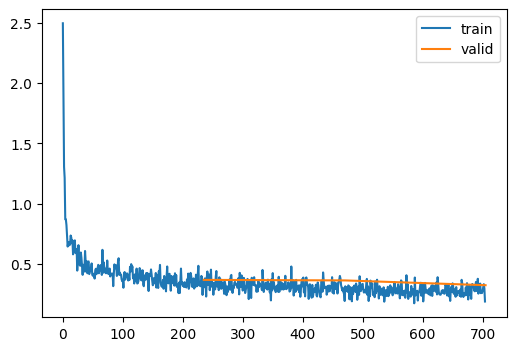

In [ ]:
# Use PyTorch's built-in BatchNorm2d
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.2, cbs=cbs) # With reduced mini-batch size, we
# need to reduce the learning rate

learn.fit(3)

accuracy,loss,epoch,train
0.918,0.224,0,train
0.897,0.284,0,eval
0.922,0.211,1,train
0.899,0.277,1,eval


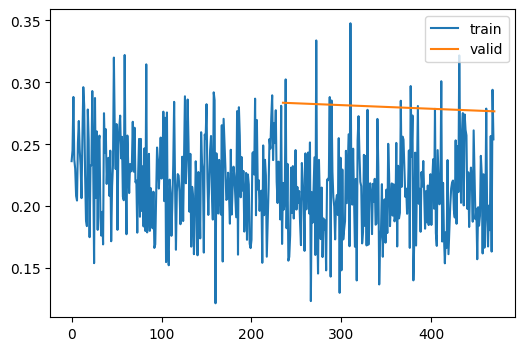

In [ ]:
# Continue training with lower learning rate
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.05, cbs=cbs)
learn.fit(2)

---
## Summary

### Key Takeaways

1. **Weight initialization is critical** for training deep networks
   - Too large → exploding activations
   - Too small → vanishing activations

2. **Xavier/Glorot initialization** ($\sigma = 1/\sqrt{n_{in}}$)
   - Works for linear, tanh, sigmoid activations
   - Keeps variance stable across layers

3. **Kaiming/He initialization** ($\sigma = \sqrt{2/n_{in}}$)
   - Designed for ReLU activations
   - Factor of 2 compensates for ReLU zeroing half the values

4. **Input normalization** (mean=0, std=1)
   - Essential for initialization formulas to work
   - Can be done via callback or in data loading

5. **GeneralRelu** improves on standard ReLU
   - Leaky slope prevents dead neurons
   - Subtraction keeps mean centered

6. **LSUV** provides empirical initialization
   - Adjusts weights until activations have unit variance
   - Works for any architecture

7. **Batch Normalization** normalizes during training
   - Allows higher learning rates
   - Reduces sensitivity to initialization
   - Acts as regularization

### Initialization Methods Summary

| Method | Formula | Best For |
|--------|---------|----------|
| Xavier | $W \sim N(0, 1/\sqrt{n_{in}})$ | tanh, sigmoid |
| Kaiming | $W \sim N(0, \sqrt{2/n_{in}})$ | ReLU |
| LSUV | Empirical adjustment | Any architecture |

### Normalization Methods Summary

| Method | Normalizes Across | Key Property |
|--------|-------------------|-------------|
| Batch Norm | Batch | Needs large batches |
| Layer Norm | Features | Batch-size independent |
| Group Norm | Channel groups | Compromise |

### Best Practices

1. **Always normalize inputs** before feeding to network
2. **Use Kaiming init** for ReLU networks
3. **Use BatchNorm** when possible (allows higher LR, better results)
4. **Use LayerNorm** for transformers or small batch sizes
5. **Monitor activations** during training with hooks
6. **Watch for dead neurons** especially with ReLU

---
## Export

In [ ]:
# import nbdev; nbdev.nbdev_export()